# LAP01 · Multitracking multicámara (AeroVision)

Un solo notebook con las **Partes I y II** de la metodología aplicadas a **tres cámaras físicas distintas** (`cam01`, `cam02`, `cam03`): cada una ve el recinto desde un ángulo diferente.

```
CCTV → Tracking local (LAP01) → Re-ID multicámara → Mapa 2D del piso → trajectory_points
```

| Carpeta | Contenido |
|---|---|
| `dataset/` | Videos de las tres cámaras (`cam0X_recortado_1280x720_15fps.mp4`). |
| `Modelo/` | Lo que usa el modelo: `yolo26m.pt`, `resnet18-f37072fd.pth`, `yolo26s-reid.onnx`, `config_lap01.json`, `camaras.json`, la calibración del mapa `mapa_piso.json` y el manifiesto `exportacion.json`. |
| `Ouput/` | Resultados: un video procesado por cámara, `mapa_2d.mp4`, `mapa_trayectorias.png` y `trajectory_points.csv`. |

**Parte I (por cámara):** YOLO26m detecta personas → limpieza de duplicados → predicción de movimiento, IoU y escala → apariencia sin rostro (HSV/Lab por cabeza, torso y piernas + ResNet18) → memoria visual multivista → Hungarian con opción de no asignar → oclusiones y recuperación → `local_id`.

**Parte II (entre cámaras):** registro técnico de cámaras → sincronización (`timestamp_offset`) → tracklets → galería global compartida con Re-ID y gating físico → `global_id` anónimo → mapa 2D del piso en metros → reagrupación con el mapa (misma posición a la vez = misma persona).

**Cómo está organizado el código.** Cada celda hace una sola cosa y va después de su explicación:

| Sección | Piezas |
|---|---|
| 3. Seguimiento local | `DetectorPersonas` · firma de color · `ExtractorResNet18` · `Appearance` · `ColorOcclusionTracker` |
| 4. Entre cámaras | `Camara` · `ReIDPersonas` · `Tracklet` · `AsociadorMulticamara` (armado con cinco partes: galería, observaciones, gating físico, fusiones y reportes) |
| 5. Motor | `MotorLAP01` · vista en vivo · `ResultadoMulticamara` · `LectorSincronizado` · `procesar_videos` |
| 9. Mapa 2D | `EstabilizadorCamaras` · `ModeloPiso` · `CalibradorMapa` · `proyectar_en_mapa` · `ReagrupadorMapa` · `DibujoMapa` |

**Fuera de alcance por ahora:** zonas, eventos espaciales (`zones`, `spatial_events`) y Parte III. En `trajectory_points`, `zone_id` queda `NULL`.

No se entrena ni se descarga nada: todos los pesos se leen de `Modelo/`.

## 1. Entorno y rutas

Usa el kernel de **jupyterev**. Ultralytics queda sin descargas, autoinstalación ni telemetría, y guarda su configuración en `Modelo/.runtime/`. Si ya habías importado Ultralytics en este kernel, reinícialo antes de ejecutar esta celda.

In [1]:
from pathlib import Path
import os
import sys

# Carpeta del proyecto: dataset/ (videos), Modelo/ (pesos y configuración) y Ouput/ (resultados).
BASE = next((carpeta.resolve() for carpeta in (Path.cwd(), Path.cwd() / "02_multicamara")
             if (carpeta / "Modelo" / "config_lap01.json").is_file() and (carpeta / "dataset").is_dir()), None)
if BASE is None:
    raise FileNotFoundError("Abre JupyterLab desde 02_multicamara o desde Entrenamiento.")
# jupyterev check removed - runs on any kernel

DATASET = BASE / "dataset"
MODELO = BASE / "Modelo"
OUTPUT = BASE / "Ouput"
OUTPUT.mkdir(exist_ok=True)
NOTEBOOK = BASE / "LAP01_Multitracking.ipynb"

# Deben fijarse antes de importar Ultralytics.
if "ultralytics" in sys.modules:
    print("Ultralytics ya estaba importado: reinicia el kernel para aplicar la configuración local.")
os.environ["YOLO_CONFIG_DIR"] = str(MODELO / ".runtime" / "ultralytics")
os.environ["YOLO_OFFLINE"] = "1"
os.environ["YOLO_AUTOINSTALL"] = "0"

import hashlib
import heapq
import importlib.metadata
import json
import math
import time
import uuid
from collections import defaultdict, deque
from concurrent.futures import ThreadPoolExecutor
from contextlib import ExitStack
from copy import deepcopy
from dataclasses import dataclass, field
from datetime import datetime
from functools import lru_cache

import cv2
import numpy as np
import pandas as pd
import torch
from IPython.display import Image, display
from scipy.optimize import linear_sum_assignment
from torch import nn
from threadpoolctl import threadpool_limits

print("Python:", sys.executable)
print("Carpeta:", BASE)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "no disponible (CPU)")

Python: C:\Users\andre\AppData\Local\Programs\Python\Python313\python.exe
Carpeta: C:\Users\andre\OneDrive\Documentos\Ciclo09\Caspton Proyect\Proyecto Final\proyecto-aeropuerto-2026\Modelo
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


## 2. Configurar la prueba

Cada archivo `dataset/cam0X_*.mp4` es una cámara distinta. Sus identificadores deben coincidir con `Modelo/camaras.json`.

- `MAX_FRAMES = None` procesa los videos completos (usa `150` para una prueba de 10 s). No se saltan frames.
- `INICIOS` recorta el principio de cada video sin cambiar su reloj.
- **Tiempo común = tiempo del video + `timestamp_offset`** (en `camaras.json`). Un offset positivo retrasa la cámara.
- `INICIO_GRABACION` convierte ese tiempo relativo en el `TIMESTAMPTZ` de `trajectory_points`. Escribe la hora real de la grabación. Con `None` se usa la hora en que empieza la sesión.
- `TIEMPO_REAL = False` procesa lo más rápido posible; `True` frena al ritmo del video para una demo. El resultado es el mismo.

In [2]:
VIDEOS = {ruta.name.split("_")[0]: ruta for ruta in sorted(DATASET.glob("cam*.mp4"))}

MAX_FRAMES = None                       # Videos completos; p. ej. 150 = 10 s por cámara para una prueba corta.
INICIOS = {cid: 0 for cid in VIDEOS}    # Frame inicial de cada cámara (base cero).
TIEMPO_REAL = False                     # True: demo al ritmo del video. False: lo más rápido posible (mismo resultado).
VISTA_EN_VIVO = True                    # Mosaico de las cámaras mientras se procesa.
VISTA_FPS = 8.0
VISTA_ANCHO = 960                       # Ancho de cada cámara en el mosaico.
DEVICE = "auto"                         # cuda:0 si hay GPU; si no, CPU.
BATCH_YOLO = True                       # Un lote YOLO con un frame de cada cámara.
CPU_THREADS = 2
INICIO_GRABACION = None                 # p. ej. "2026-09-12T14:30:00-05:00"

MAPA_2D = True                          # Estabiliza, calibra (o carga) el mapa del piso y ubica a cada persona en metros.
RECALIBRAR_MAPA = False                 # True vuelve a calibrar aunque exista Modelo/mapa_piso.json.
UNIR_CON_MAPA = True                    # Reagrupa con el mapa: une a quien está en el mismo lugar a la vez y separa errores del Re-ID.
TEMA_MAPA = "claro"                     # Tema de cuadrícula del mapa 2D: "oscuro" o "claro".
FONDO_PISO_SEGMENTADO = True                # Proyecta el piso segmentado de las cámaras como fondo del mapa.

EXPORTAR_VIDEOS = True                  # Ouput/<cam>_procesado.mp4 con los global_id finales.
EXPORTAR_MAPA = True                    # Ouput/mapa_2d.mp4 y Ouput/mapa_trayectorias.png.
EXPORTAR_TRAYECTORIAS = True            # Ouput/trajectory_points.csv para PostGIS.
EXPORTAR_GENEROS = True                 # Ouput/identidades_genero.csv (estimación por identidad, no por frame).

CONFIG = json.loads((MODELO / "config_lap01.json").read_text())
CONFIG_CAMARAS = json.loads((MODELO / "camaras.json").read_text())
if set(VIDEOS) != set(CONFIG_CAMARAS["cameras"]):
    raise ValueError(f"Cámaras del dataset {sorted(VIDEOS)} ≠ Modelo/camaras.json {sorted(CONFIG_CAMARAS['cameras'])}.")

### Videos de entrada

Se leen los metadatos de cada video sin cargarlo en memoria. `area` es la zona con imagen real de cada cámara: las bandas negras del recorte no cuentan como borde de la escena.

In [3]:
def area_util(cap, frames, umbral=8.0):
    """Zona con imagen real (sin bandas negras del recorte): (x0, y0, x1, y1)."""
    muestras = []
    for k in (0, frames // 2, (2 * frames) // 3):
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(k))
        ok, frame = cap.read()
        if ok:
            muestras.append(cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY))
    if not muestras:
        raise RuntimeError("No se pudieron leer frames para medir el área útil.")
    gris = np.max(np.stack(muestras), axis=0).astype(np.float32)
    filas, columnas = np.where(gris.mean(axis=1) > umbral)[0], np.where(gris.mean(axis=0) > umbral)[0]
    if not len(filas) or not len(columnas):
        return (0, 0, gris.shape[1], gris.shape[0])
    return (int(columnas[0]), int(filas[0]), int(columnas[-1]) + 1, int(filas[-1]) + 1)


def inspeccionar_videos(videos):
    """Lee metadatos y el área útil sin cargar los videos en memoria."""
    if not videos:
        raise FileNotFoundError(f"No hay videos cam*.mp4 en {DATASET}")
    filas = []
    for camera_id, ruta in videos.items():
        ruta = Path(ruta).resolve()
        cap = cv2.VideoCapture(str(ruta))
        try:
            if not cap.isOpened():
                raise RuntimeError(f"No se pudo abrir {ruta}")
            fps = float(cap.get(cv2.CAP_PROP_FPS))
            frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
            if not math.isfinite(fps) or fps <= 0 or frames <= 0:
                raise ValueError(f"Metadatos inválidos en {ruta}")
            filas.append({"camera_id": camera_id, "video": str(ruta), "fps": fps, "frames": frames,
                          "duration_s": frames / fps,
                          "width": int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)),
                          "height": int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)),
                          "area": area_util(cap, frames)})
        finally:
            cap.release()
    return filas


display(pd.DataFrame(inspeccionar_videos(VIDEOS)))
print("Modo multicámara:", CONFIG_CAMARAS["mode"])
display(pd.DataFrame({cid: {"timestamp_offset": cam.get("timestamp_offset", 0.0),
                            "resolution": cam.get("resolution"),
                            "homografia": cam.get("H") is not None}
                      for cid, cam in CONFIG_CAMARAS["cameras"].items()}).T)

,camera_id,video,fps,frames,duration_s,width,height,area
0,cam01,C:\Users\andre\OneDrive\Documentos\Ciclo09\Cas...,15.0,1892,126.133333,1280,720,"(0, 22, 1280, 698)"
1,cam02,C:\Users\andre\OneDrive\Documentos\Ciclo09\Cas...,15.0,1892,126.133333,1280,720,"(137, 0, 1143, 720)"
2,cam03,C:\Users\andre\OneDrive\Documentos\Ciclo09\Cas...,15.0,1892,126.133333,1280,720,"(102, 0, 1178, 720)"


Modo multicámara: visual_temporal


,timestamp_offset,resolution,homografia
cam01,0.0,"[1280, 720]",False
cam02,0.0,"[1280, 720]",False
cam03,0.0,"[1280, 720]",False


# Parte I — Seguimiento local (LAP01)

Cada cámara ejecuta su propio seguidor y respeta el orden temporal de sus frames. El `local_id` solo es válido dentro de la cámara que lo creó.

### 3.1 — Detección de personas

YOLO26m restringido a la clase `person`. Cada detección es $d_i=(x_1,y_1,x_2,y_2,c_i)$. Una confianza baja solo sirve para continuar un track existente; nunca crea una identidad.

**Personas lejanas.** Al fondo de `cam01` una persona mide 40–70 px. YOLO la detecta, pero su apariencia y su Re-ID son pobres: creaba IDs nuevos y el Re-ID llegó a mezclarla con otra persona. Umbrales de `config_lap01.json`, comparados con el video completo:

| Umbral | Antes | Ahora | Para qué |
|---|---|---|---|
| `detector.conf` | 0.20 | 0.30 | igual a `display_conf`: todo lo que se sigue también se dibuja |
| `tracker.new_track_confidence` | 0.45 | 0.60 | una detección dudosa ya no crea un track nuevo |
| `tracker.min_person_height` | 18 px | 40 px | se ignoran las cajas diminutas |

Resultado: IDs locales 88 → 80 y tracks de personas lejanas (altura mediana < 60 px) 7 → 1. **Subir solo `conf` no sirve:** con 0.45 los IDs locales subieron a 91 y las pasadas breves de 23 a 30, porque las detecciones débiles son las que sostienen un track durante una oclusión.

In [4]:
class DetectorPersonas:
    """YOLO26m, clase person. Con batch=True agrupa un frame por cámara (nunca frames de distinto tiempo)."""

    def __init__(self, pesos, config, device, batch=True):
        from ultralytics import YOLO

        self.model = YOLO(str(pesos))
        self.config, self.device, self.batch = config, device, batch

    def __call__(self, frames):
        # FP16 es ~35 % más rápido y da las mismas cajas, pero sus confianzas cambian en milésimas y eso alteró
        # decisiones del tracker en el umbral (precisión multicámara 0.99 -> 0.95). Por defecto: FP32.
        precision = 16 if self.config.get("fp16", False) and str(self.device).startswith("cuda") else None
        kwargs = dict(classes=[0], conf=self.config["conf"], iou=self.config["iou"], imgsz=self.config["imgsz"],
                      device=self.device, verbose=False, rect=True, quantize=precision)
        images = list(frames.values())
        results = (self.model.predict(source=images, **kwargs) if self.batch
                   else [self.model.predict(source=image, **kwargs)[0] for image in images])
        detections = {}
        for cid, result in zip(frames, results):
            if result.boxes is None or not len(result.boxes):
                detections[cid] = (np.empty((0, 4), np.float32), np.empty(0, np.float32))
            else:
                detections[cid] = (result.boxes.xyxy.cpu().numpy().astype(np.float32),
                                   result.boxes.conf.cpu().numpy().astype(np.float32))
        return detections

### 3.2 — Apariencia sin reconocimiento facial

El recorte se divide en **cabeza, torso y piernas**. De cada región visible se obtienen histogramas HSV y Lab. Las zonas tapadas por otra persona se enmascaran para no mezclar identidades. ResNet18 (pesos locales de ImageNet) se usa solo como extractor profundo:

$$A=[A_{color},A_{deep}]$$

La mezcla calibrada es `clip(gain · ((1−w)·color + w·deep) + offset, 0, 1)`, con `w`, `gain` y `offset` tomados de `config_lap01.json`.

**Memoria visual multivista:** cada identidad guarda una galería de vistas fiables y se compara con $S_{app}(q,G_i)=\max_{g\in G_i}\operatorname{sim}(q,g)$, en forma vectorizada.

#### Género estimado por cuerpo (opcional)

`clip_genero/` se consulta sin descargar modelos y **no usa rostro ni estima edad**. Solo se muestrean cajas grandes y fiables cada `sample_interval_s`; una etiqueta se publica tras `min_votes` votos con confianza y margen mínimos. Después del Re-ID y del mapa, los votos se consolidan de nuevo por `global_id`. Cuando no alcanza evidencia, queda `Sin determinar`. Es una estimación visual y no debe usarse como identificación ni como base única para decisiones.

#### Firma de color por partes del cuerpo

In [5]:
_REGIONS = ((slice(0, 120), 0.20), (slice(120, 240), 0.52), (slice(240, 360), 0.28))  # cabeza, torso, piernas
_PESOS_COLOR = np.concatenate([np.full(120, weight, np.float32) for _, weight in _REGIONS])


def _l1_sqrt(hist):
    hist = hist.astype(np.float32).reshape(-1)
    return np.sqrt(hist / (hist.sum() + 1e-8))


def _part_signature(part, mask=None):
    """Histogramas HSV y Lab de una región corporal visible (120 valores)."""
    if part.size == 0 or (mask is not None and np.count_nonzero(mask) < 32):
        return np.zeros(120, dtype=np.float32)
    part = cv2.resize(part, (48, 64), interpolation=cv2.INTER_AREA)
    if mask is not None:
        mask = cv2.resize(mask.astype(np.uint8), (48, 64), interpolation=cv2.INTER_NEAREST)
    hsv = cv2.cvtColor(part, cv2.COLOR_BGR2HSV)
    lab = cv2.cvtColor(part, cv2.COLOR_BGR2LAB)
    hs = _l1_sqrt(cv2.calcHist([hsv], [0, 1], mask, [12, 4], [0, 180, 0, 256]))
    value = _l1_sqrt(cv2.calcHist([hsv], [2], mask, [8], [0, 256]))
    chroma = _l1_sqrt(cv2.calcHist([lab], [1, 2], mask, [8, 8], [0, 256, 0, 256]))
    return np.concatenate((hs, value, chroma)).astype(np.float32)


def clothing_signature(image, box, all_boxes=None):
    """Firma de color de cabeza, torso y piernas excluyendo lo cubierto por otras cajas (360 valores)."""
    x1, y1, x2, y2 = map(int, box)
    height, width = image.shape[:2]
    x1, y1 = max(0, x1), max(0, y1)
    x2, y2 = min(width, x2), min(height, y2)
    crop = image[y1:y2, x1:x2]
    if crop.shape[0] < 16 or crop.shape[1] < 8:
        return np.zeros(360, dtype=np.float32)

    safe_mask = np.full(crop.shape[:2], 255, dtype=np.uint8)
    if all_boxes is not None:
        for other in np.asarray(all_boxes, dtype=np.float32):
            if np.allclose(other, np.asarray(box, dtype=np.float32), atol=1.0):
                continue
            ox1, oy1, ox2, oy2 = map(int, other)
            ix1, iy1 = max(x1, ox1), max(y1, oy1)
            ix2, iy2 = min(x2, ox2), min(y2, oy2)
            if ix2 > ix1 and iy2 > iy1:
                safe_mask[iy1 - y1:iy2 - y1, ix1 - x1:ix2 - x1] = 0

    h, w = crop.shape[:2]
    head_top, head_bottom = int(0.02 * h), int(0.28 * h)
    head_left, head_right = int(0.22 * w), int(0.78 * w)
    head = _part_signature(crop[head_top:head_bottom, head_left:head_right],
                           safe_mask[head_top:head_bottom, head_left:head_right])

    top, bottom = int(0.20 * h), int(0.94 * h)
    left, right = int(0.16 * w), int(0.84 * w)
    body, body_mask = crop[top:bottom, left:right], safe_mask[top:bottom, left:right]
    split = max(1, int(body.shape[0] * 0.55))
    signature = np.concatenate((head, _part_signature(body[:split], body_mask[:split]),
                                _part_signature(body[split:], body_mask[split:])))
    return signature / (np.linalg.norm(signature) + 1e-8)


def _unidad_por_region(colours):
    """Normaliza cabeza, torso y piernas por separado. (unidad · pesos) @ unidad = similitud de color."""
    colours = np.atleast_2d(np.asarray(colours, dtype=np.float32))
    unit = np.empty_like(colours)
    for region, _ in _REGIONS:
        block = colours[:, region]
        unit[:, region] = block / (np.linalg.norm(block, axis=1, keepdims=True) + 1e-8)
    return unit


def colour_similarity(first, second):
    return float((_unidad_por_region(first)[0] * _PESOS_COLOR) @ _unidad_por_region(second)[0])

#### Extractor profundo (ResNet18)

In [6]:
class ExtractorResNet18:
    """ResNet18 sin capa de clasificación; pesos locales, sin descargas. Devuelve 2048 valores normalizados."""
    ENTRADA = (64, 128)  # ancho, alto

    def __init__(self, pesos, device):
        from torchvision.models import resnet18

        network = resnet18(weights=None)
        network.load_state_dict(torch.load(pesos, map_location="cpu", weights_only=True))
        self.device = device
        self.model = torch.nn.Sequential(*list(network.children())[:-2]).to(device).eval()
        self.mean = torch.tensor([0.485, 0.456, 0.406], device=device).view(1, 3, 1, 1)
        self.std = torch.tensor([0.229, 0.224, 0.225], device=device).view(1, 3, 1, 1)

    @torch.inference_mode()
    def __call__(self, image, boxes):
        if not len(boxes):
            return []
        height, width = image.shape[:2]
        crops = []
        for box in boxes:
            x1, y1, x2, y2 = (int(value) for value in box)
            crop = image[max(0, y1):min(height, y2), max(0, x1):min(width, x2)]
            if crop.size == 0:
                crop = np.zeros((8, 4, 3), dtype=np.uint8)
            crops.append(cv2.resize(crop, self.ENTRADA, interpolation=cv2.INTER_LINEAR))
        batch = np.ascontiguousarray(np.stack(crops)[..., ::-1])
        tensor = torch.from_numpy(batch).to(self.device).permute(0, 3, 1, 2).float() / 255.0
        maps = self.model((tensor - self.mean) / self.std)
        pooled = torch.nn.functional.adaptive_avg_pool2d(maps, (4, 1)).flatten(1)
        return list(torch.nn.functional.normalize(pooled, dim=1).cpu().numpy().astype(np.float32))

#### Apariencia combinada y memoria multivista

In [7]:
@dataclass(frozen=True)
class MezclaApariencia:
    deep_weight: float = 0.20
    gain: float = 1.123
    offset: float = -0.075

    def __call__(self, colour, deep):
        mixed = (1.0 - self.deep_weight) * colour + self.deep_weight * deep
        return np.clip(self.gain * mixed + self.offset, 0.0, 1.0)


@dataclass
class Appearance:
    colour: np.ndarray
    deep: np.ndarray | None = None
    _unit: np.ndarray | None = field(default=None, repr=False, compare=False)

    def unit(self):
        if self._unit is None:
            self._unit = _unidad_por_region(self.colour)[0]
        return self._unit

    def similarity(self, other, mezcla):
        colour = float((self.unit() * _PESOS_COLOR) @ other.unit())
        if self.deep is None or other.deep is None:
            return colour
        return float(mezcla(colour, float(self.deep @ other.deep)))


def gallery_similarities(signatures, tracks, mezcla):
    """Matriz tracks × detecciones con la mejor vista de la galería de cada track."""
    if not signatures or not tracks:
        return np.zeros((len(tracks), len(signatures)), dtype=np.float32)
    gallery, starts = [], []
    for track in tracks:
        starts.append(len(gallery))
        gallery.extend(track.gallery)
    similarity = np.stack([s.unit() for s in signatures]) @ (np.stack([v.unit() for v in gallery]) * _PESOS_COLOR).T
    if all(v.deep is not None for v in gallery) and all(s.deep is not None for s in signatures):
        deep = np.stack([s.deep for s in signatures]) @ np.stack([v.deep for v in gallery]).T
        similarity = mezcla(similarity, deep)
    return np.maximum.reduceat(similarity, starts, axis=1).T.astype(np.float32)


def describe_indices(image, boxes, indices, extractor=None):
    """Apariencia solo de algunas cajas; todas las demás siguen contando como oclusores en la máscara de color."""
    boxes = np.asarray(boxes, dtype=np.float32).reshape(-1, 4)
    indices = list(indices)
    deep = extractor(image, boxes[indices]) if extractor is not None and indices else [None] * len(indices)
    return {i: Appearance(clothing_signature(image, boxes[i], boxes), vector) for i, vector in zip(indices, deep)}


class ClasificadorGeneroCLIP:
    """Estima presentación de género desde el cuerpo con CLIP local; no usa caras ni edad."""
    ETIQUETAS = ("Hombre", "Mujer")
    PROMPTS = ("a photo of a man", "a photo of a woman")
    SIN_DETERMINAR = "Sin determinar"

    def __init__(self, modelo_dir, settings, device):
        self.settings = deepcopy(settings)
        self.enabled = bool(self.settings.get("enabled", False))
        self.stats = {"crops": 0, "votes": 0, "confirmed": 0}
        self.memory, self.sample_frames = {}, {}
        if not self.enabled:
            return
        nombre = self.settings.get("weights", "clip_genero")
        if not isinstance(nombre, str) or Path(nombre).name != nombre:
            raise ValueError("gender.weights debe ser el nombre de una carpeta dentro de Modelo/.")
        self.weights = Path(modelo_dir) / nombre
        if not (self.weights / "config.json").is_file() or not (self.weights / "model.safetensors").is_file():
            raise FileNotFoundError(f"Falta el modelo CLIP local en {self.weights}")
        self.batch_size = int(self.settings.get("batch_size", 16))
        self.sample_s = float(self.settings.get("sample_interval_s", 0.8))
        self.min_votes = int(self.settings.get("min_votes", 3))
        self.max_votes = int(self.settings.get("max_votes_per_tracklet", 12))
        self.min_confidence = float(self.settings.get("min_confidence", 0.60))
        self.min_margin = float(self.settings.get("min_margin", 0.10))
        self.min_height = float(self.settings.get("min_height", 80))
        self.min_detection_confidence = float(self.settings.get("min_detection_confidence", 0.55))
        if (self.batch_size < 1 or self.min_votes < 1 or self.max_votes < self.min_votes or self.sample_s <= 0
                or self.min_height <= 0 or not all(
                    0.0 <= value <= 1.0 for value in (self.min_confidence, self.min_margin, self.min_detection_confidence))):
            raise ValueError("Configuración de gender inválida.")
        elegido = self.settings.get("device", "auto")
        self.device = device if elegido == "auto" else str(elegido)
        if self.device.startswith("cuda") and not torch.cuda.is_available():
            raise RuntimeError("gender.device solicita CUDA, pero CUDA no está disponible.")
        from transformers import CLIPModel, CLIPProcessor
        self.processor = CLIPProcessor.from_pretrained(self.weights, local_files_only=True)
        self.model = CLIPModel.from_pretrained(self.weights, local_files_only=True).eval().to(self.device)
        text = self.processor(text=list(self.PROMPTS), return_tensors="pt", padding=True)
        self.text_inputs = {name: value.to(self.device) for name, value in text.items()}

    def reiniciar(self, fps):
        self.memory = {}
        if not self.enabled:
            self.sample_frames = {}
            return
        self.sample_frames = {cid: max(1, round(self.sample_s * value)) for cid, value in fps.items()}
        self.stats = {"crops": 0, "votes": 0, "confirmed": 0}

    def _state(self, camera_id, local_id):
        return self.memory.setdefault((camera_id, int(local_id)), {"last_frame": -math.inf, "votes": [],
                                                                    "genero": self.SIN_DETERMINAR,
                                                                    "confianza": None})

    def _consolidar(self, state):
        if len(state["votes"]) < self.min_votes:
            return self.SIN_DETERMINAR, None
        pesos = {label: 0.0 for label in self.ETIQUETAS}
        for label, score in state["votes"]:
            pesos[label] += score
        label = max(pesos, key=pesos.get)
        total = max(sum(pesos.values()), 1e-12)
        consenso = pesos[label] / total
        rival = max(pesos[otra] for otra in self.ETIQUETAS if otra != label)
        margen = (pesos[label] - rival) / total
        return (label, float(consenso)) if (consenso >= self.min_confidence and margen >= self.min_margin) else (self.SIN_DETERMINAR, None)

    def _clasificar(self, crops):
        from PIL import Image as PILImage
        images = [PILImage.fromarray(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)) for crop in crops]
        values = self.processor(images=images, return_tensors="pt")["pixel_values"].to(self.device)
        with torch.inference_mode():
            probabilities = self.model(pixel_values=values, **self.text_inputs).logits_per_image.softmax(dim=1).cpu().numpy()
        answers = []
        for probabilities_row in probabilities:
            order = np.argsort(probabilities_row)[::-1]
            index, second = int(order[0]), int(order[1])
            answers.append((self.ETIQUETAS[index], float(probabilities_row[index]),
                            float(probabilities_row[index] - probabilities_row[second])))
        return answers

    def actualizar(self, frames, source_frames, rows):
        """Muestrea vistas grandes y fiables hasta reunir evidencia temporal suficiente."""
        if not self.enabled:
            for camera_rows in rows.values():
                for row in camera_rows:
                    row.update(genero=self.SIN_DETERMINAR, confianza_genero=None, genero_voto=None, confianza_genero_voto=None)
            return
        crops, pending = [], []
        for cid, camera_rows in rows.items():
            for row in camera_rows:
                state = self._state(cid, row["local_id"])
                row.update(genero=state["genero"], confianza_genero=state["confianza"], genero_voto=None, confianza_genero_voto=None)
                ready = source_frames[cid] - state["last_frame"] >= self.sample_frames[cid]
                quality = (row["confidence"] >= self.min_detection_confidence and
                           row["y2"] - row["y1"] >= self.min_height)
                if len(state["votes"]) >= self.max_votes or not ready or not quality:
                    continue
                crop = recortar(frames[cid], row)
                if crop.size:
                    state["last_frame"] = source_frames[cid]
                    crops.append(crop)
                    pending.append((row, state))
        for start in range(0, len(crops), self.batch_size):
            chunk, selected = crops[start:start + self.batch_size], pending[start:start + self.batch_size]
            for (row, state), (label, score, margin) in zip(selected, self._clasificar(chunk)):
                self.stats["crops"] += 1
                if score < self.min_confidence or margin < self.min_margin:
                    continue
                state["votes"].append((label, score))
                self.stats["votes"] += 1
                row["genero_voto"], row["confianza_genero_voto"] = label, score
                confirmado = state["genero"] != self.SIN_DETERMINAR
                state["genero"], state["confianza"] = self._consolidar(state)
                row["genero"], row["confianza_genero"] = state["genero"], state["confianza"]
                if not confirmado and state["genero"] != self.SIN_DETERMINAR:
                    self.stats["confirmed"] += 1

    def consolidar_globales(self, filas):
        """Consolida votos de los tracklets ya reconciliados; una fusión no duplica IDs de persona."""
        if not self.enabled:
            return []
        grupos = defaultdict(list)
        for fila in filas:
            if fila.get("global_id") is not None and fila.get("genero_voto") in self.ETIQUETAS:
                grupos[int(fila["global_id"])].append((fila["genero_voto"], float(fila["confianza_genero_voto"])))
        resumen = {}
        for gid in sorted({int(f["global_id"]) for f in filas if f.get("global_id") is not None}):
            votos = grupos[gid]
            pesos = {label: 0.0 for label in self.ETIQUETAS}
            for label, score in votos:
                pesos[label] += score
            ganador = max(pesos, key=pesos.get)
            total = max(sum(pesos.values()), 1e-12)
            consenso = pesos[ganador] / total if votos else 0.0
            rival = max(pesos[etiqueta] for etiqueta in self.ETIQUETAS if etiqueta != ganador)
            margen = (pesos[ganador] - rival) / total if votos else 0.0
            valido = len(votos) >= self.min_votes and consenso >= self.min_confidence and margen >= self.min_margin
            resumen[gid] = {"global_id": gid, "genero": ganador if valido else self.SIN_DETERMINAR,
                            "confianza_genero": float(consenso) if valido else None,
                            "votos_genero": len(votos)}
        for fila in filas:
            item = resumen.get(fila.get("global_id"))
            if item is not None:
                fila["genero"], fila["confianza_genero"] = item["genero"], item["confianza_genero"]
        return list(resumen.values())

### 3.3 — Asociación, oclusiones y recuperación

Por frame, en este orden (cada paso es un método de `ColorOcclusionTracker`):

1. **Limpieza** (`_limpiar`): se descartan cajas contenidas en otra en un ≥ 92 % y cajas de menos de `min_person_height` px.
2. **Asociación principal** (`_asociar`; detecciones con confianza ≥ `association_confidence`, tracks vistos en el frame anterior): $S_{ij}=w_mS_{mov}+w_oS_{IoU}+w_sS_{escala}+w_aS_{app}$. El costo se resuelve con Hungarian y columnas ficticias, de modo que un track puede quedar sin asignar sin quitarle la detección a un par válido.
3. **Segunda etapa (tipo ByteTrack):** una detección débil solo prolonga un track activo libre con movimiento, IoU y escala muy coherentes.
4. **Recuperación:** las detecciones fiables no asignadas se comparan con tracks perdidos (≤ `max_age`) usando la galería de apariencia, la posición esperada y la escala.
5. **Actualización** (`_actualizar`): la velocidad se amortigua y la galería solo recibe vistas fiables (confianza ≥ 0.55, solape < 0.25 y evidencia de color).
6. **Tracks nuevos** (`_tracks_nuevos`): requieren `min_confirmations` detecciones con confianza ≥ `new_track_confidence` dentro de `confirmation_window`. No se publican IDs efímeros.

**La apariencia no se calcula para cada persona en cada frame.** El color por partes y la ResNet18 solo se calculan cuando cambian una decisión:

- Una detección cerca de un track con poco IoU.
- Dos tracks o dos detecciones que compiten.
- Un track perdido que se intenta recuperar.
- Una persona nueva o tentativa.
- El refresco de la galería, cada `appearance_interval` frames.

Si movimiento, IoU y escala ya bastan para decidir, se omite.

Medido en los videos completos: con `appearance_interval = 1` el resultado es idéntico al cálculo en todos los frames (IDF1 = 1.000 en las tres cámaras). Con `5` se calcula la apariencia solo para el **23 %** de las detecciones y la asociación multicámara queda igual (precisión 0.99, recall 0.86).

#### Geometría y asignación

In [8]:
def _has_colour_evidence(appearance):
    return bool(np.linalg.norm(appearance.colour) > 0.20)


def _center_distance(first, second):
    dx = (first[0] + first[2] - second[0] - second[2]) / 2.0
    dy = (first[1] + first[3] - second[1] - second[3]) / 2.0
    return float((dx * dx + dy * dy) ** 0.5)


def _scale_change(first, second):
    first_w, first_h = max(1.0, first[2] - first[0]), max(1.0, first[3] - first[1])
    second_w, second_h = max(1.0, second[2] - second[0]), max(1.0, second[3] - second[1])
    return float((abs(np.log(second_w / first_w)) + abs(np.log(second_h / first_h))) / 2.0)


def _iou(first, second):
    x1, y1 = max(first[0], second[0]), max(first[1], second[1])
    x2, y2 = min(first[2], second[2]), min(first[3], second[3])
    intersection = max(0.0, x2 - x1) * max(0.0, y2 - y1)
    area_first = max(0.0, first[2] - first[0]) * max(0.0, first[3] - first[1])
    area_second = max(0.0, second[2] - second[0]) * max(0.0, second[3] - second[1])
    return float(intersection / (area_first + area_second - intersection + 1e-8))


def _asignar_costos(costs, threshold):
    """Hungarian con columnas ficticias: permite dejar filas sin asignar sin robar pares válidos."""
    augmented = np.full((len(costs), costs.shape[1] + len(costs)), threshold + 1e-6)
    augmented[:, :costs.shape[1]] = np.where(costs <= threshold, costs, 1e6)
    rows, cols = linear_sum_assignment(augmented)
    valid = cols < costs.shape[1]
    return rows[valid], cols[valid]


def _nested_duplicate_indices(boxes, scores):
    """Cajas contenidas en otra en un 92 % o más: se conserva la de mayor confianza."""
    dropped = set()
    for first in range(len(boxes)):
        if first in dropped:
            continue
        for second in range(first + 1, len(boxes)):
            if second in dropped:
                continue
            left, top = max(boxes[first, 0], boxes[second, 0]), max(boxes[first, 1], boxes[second, 1])
            right, bottom = min(boxes[first, 2], boxes[second, 2]), min(boxes[first, 3], boxes[second, 3])
            intersection = max(0.0, right - left) * max(0.0, bottom - top)
            area_first = max(1.0, (boxes[first, 2] - boxes[first, 0]) * (boxes[first, 3] - boxes[first, 1]))
            area_second = max(1.0, (boxes[second, 2] - boxes[second, 0]) * (boxes[second, 3] - boxes[second, 1]))
            if intersection / min(area_first, area_second) >= 0.92:
                dropped.add(first if scores[first] < scores[second] else second)
    return dropped

#### Estados de un track: confirmado y tentativo

In [9]:
@dataclass
class _StableTrack:
    stable_id: int
    box: np.ndarray
    appearance: Appearance
    frame_seen: int
    velocity: np.ndarray = field(default_factory=lambda: np.zeros(4, dtype=np.float32))
    gallery: deque = field(default_factory=lambda: deque(maxlen=24))
    gallery_frame: int = -1  # último frame en que se revisó su apariencia


@dataclass
class _TentativeTrack:
    box: np.ndarray
    appearance: Appearance
    first_seen: int
    frame_seen: int
    hits: int = 1
    velocity: np.ndarray = field(default_factory=lambda: np.zeros(4, dtype=np.float32))

#### Seguidor local `ColorOcclusionTracker`

`update` recorre los pasos 1–6 de arriba; cada paso es un método. `_match_confirmed` es el emparejamiento con Hungarian (pasos 2–4) y `_match_tentative` el de tracks tentativos (paso 6).

In [10]:
class ColorOcclusionTracker:
    """Seguidor local LAP01: movimiento, IoU, escala, apariencia y memoria visual por cámara."""

    def __init__(self, extractor, mezcla, max_age=120, colour_gate=0.72, distance_gate=0.95,
                 gallery_size=24, deep_appearance=True, min_confirmations=3, confirmation_window=5,
                 new_track_confidence=0.45, association_confidence=0.35, active_motion_gate=0.55,
                 active_iou_gate=0.12, min_person_height=18, reid_gate=0.80, appearance_interval=5):
        if (min_confirmations < 1 or confirmation_window < min_confirmations or max_age < 1 or gallery_size < 1
                or appearance_interval < 1):
            raise ValueError("Ventanas de tracking o tamaño de galería inválidos.")
        self.extractor = extractor if deep_appearance else None
        self.mezcla = mezcla
        self.max_age = max_age
        self.colour_gate = colour_gate
        self.distance_gate = distance_gate
        self.gallery_size = gallery_size
        self.min_confirmations = min_confirmations
        self.confirmation_window = confirmation_window
        self.new_track_confidence = new_track_confidence
        self.association_confidence = association_confidence
        self.active_motion_gate = active_motion_gate
        self.active_iou_gate = active_iou_gate
        self.min_person_height = min_person_height
        self.reid_gate = reid_gate
        self.appearance_interval = appearance_interval
        self.last_frame = None
        self.tracks = {}
        self.tentative = []
        self.riesgo = set()  # IDs recuperados tras una pérdida o asociados en un cruce durante el último frame
        self.next_stable_id = 1
        self.diagnostics = {"low_quality_rejected": 0, "duplicates_suppressed": 0, "tracks_confirmed": 0,
                            "reid_matches": 0, "short_occlusion_recoveries": 0, "low_confidence_updates": 0,
                            "detections": 0, "appearance_computed": 0}
        self._imagen, self._cajas, self._firmas = None, np.empty((0, 4), np.float32), {}

    # ------------------------------------------------------------------ frame completo
    def update(self, image, boxes, frame, scores=None):
        """Devuelve un local_id por caja (-1 si la caja no publica identidad en este frame)."""
        boxes = np.asarray(boxes, dtype=np.float32).reshape(-1, 4)
        scores = np.ones(len(boxes), np.float32) if scores is None else np.asarray(scores, dtype=np.float32)
        if len(boxes) != len(scores):
            raise ValueError("boxes y scores deben tener la misma longitud.")
        if self.last_frame is not None and frame <= self.last_frame:
            raise ValueError("Los frames de una cámara deben ser estrictamente crecientes.")
        self.last_frame = frame
        self.riesgo = set()
        self._expire(frame)
        ids = [-1] * len(boxes)
        valid_indices = self._limpiar(boxes, scores) if len(boxes) else []
        if not valid_indices:
            return ids

        current_scores = scores[valid_indices]
        self._imagen, self._cajas, self._firmas = image, boxes[valid_indices], {}
        self.diagnostics["detections"] += len(valid_indices)

        matches = self._asociar(frame, current_scores)
        for local_index, stable_id in matches.items():
            self._actualizar(local_index, stable_id, frame, float(current_scores[local_index]))
            ids[valid_indices[local_index]] = stable_id
        for local_index, stable_id in self._tracks_nuevos(matches, frame, current_scores).items():
            ids[valid_indices[local_index]] = stable_id
        return ids

    def resumen(self):
        vistas = max(1, self.diagnostics["detections"])
        return {**self.diagnostics, "appearance_share": round(self.diagnostics["appearance_computed"] / vistas, 3),
                "active_tracks": len(self.tracks), "pending_tracks": len(self.tentative)}

    # ------------------------------------------------------------------ pasos del frame
    def _limpiar(self, boxes, scores):
        """Paso 1: índices de las cajas útiles (sin duplicados anidados ni cajas demasiado pequeñas)."""
        duplicates = _nested_duplicate_indices(boxes, scores)
        valid_indices = []
        for index, box in enumerate(boxes):
            if index in duplicates:
                self.diagnostics["duplicates_suppressed"] += 1
            elif box[2] - box[0] < 6 or box[3] - box[1] < self.min_person_height:
                self.diagnostics["low_quality_rejected"] += 1
            else:
                valid_indices.append(index)
        return valid_indices

    def _asociar(self, frame, current_scores):
        """Pasos 2–4: detección local -> stable_id para tracks activos, detecciones débiles y tracks perdidos."""
        active_tracks = [track for track in self.tracks.values() if frame - track.frame_seen == 1]
        high = [i for i, score in enumerate(current_scores) if score >= self.association_confidence]
        matches = {}
        if high and active_tracks:
            found = self._match_confirmed(high, frame, candidates=active_tracks)
            matches.update({high[i]: stable_id for i, stable_id in found.items()})

        # Detecciones débiles: solo prolongan un track activo que siga libre.
        low = [i for i, score in enumerate(current_scores) if score < self.association_confidence]
        usados = set(matches.values())
        available = [track for track in active_tracks if track.stable_id not in usados]
        if low and available:
            found = self._match_confirmed(low, frame, candidates=available, strict_low=True)
            matches.update({low[i]: stable_id for i, stable_id in found.items()})
            self.diagnostics["low_confidence_updates"] += len(found)

        # Recuperación: tracks perdidos contra detecciones fiables no reclamadas.
        recovery = [i for i in high if i not in matches]
        usados = set(matches.values())
        lost = [track for track in self.tracks.values()
                if 1 < frame - track.frame_seen <= self.max_age and track.stable_id not in usados]
        if recovery and lost:
            found = self._match_confirmed(recovery, frame, candidates=lost)
            matches.update({recovery[i]: stable_id for i, stable_id in found.items()})
        return matches

    def _actualizar(self, index, stable_id, frame, score):
        """Paso 5: movimiento amortiguado y galería (solo vistas fiables); marca riesgo si hay un cruce."""
        track = self.tracks[stable_id]
        max_overlap = max((_iou(self._cajas[index], other)
                           for other_index, other in enumerate(self._cajas) if other_index != index), default=0.0)
        if max_overlap >= 0.25:
            self.riesgo.add(stable_id)
        box = self._cajas[index]
        step = max(1, frame - track.frame_seen)
        track.velocity = 0.72 * track.velocity + 0.28 * (box - track.box) / step
        # La galería solo acepta vistas fiables. Se revisa si la apariencia ya se calculó en este frame o si
        # pasaron `appearance_interval` frames; el resto de frames no se procesa la apariencia de la persona.
        revisar = index in self._firmas or frame - track.gallery_frame >= self.appearance_interval
        if revisar and score >= 0.55 and max_overlap < 0.25:
            signature = self._firmas_de([index])[0]
            visual = self._appearance_similarity(signature, track)
            if _has_colour_evidence(signature) and visual >= 0.65:
                if visual < 0.97:
                    track.gallery.append(signature)  # vista nueva y fiable: amplía la memoria multivista
                track.appearance = signature
            track.gallery_frame = frame
        track.box = box
        track.frame_seen = frame

    def _tracks_nuevos(self, matches, frame, current_scores):
        """Paso 6: detecciones fiables sin track -> tentativos; se confirman tras min_confirmations apariciones."""
        confirmados = {}
        remaining = [i for i in range(len(self._cajas))
                     if i not in matches and current_scores[i] >= self.new_track_confidence]
        matched_tentative = set()
        for local_remaining, tentative_index in self._match_tentative(remaining, frame).items():
            local_index = remaining[local_remaining]
            track = self.tentative[tentative_index]
            step = max(1, frame - track.frame_seen)
            track.velocity = 0.70 * track.velocity + 0.30 * (self._cajas[local_index] - track.box) / step
            track.box = self._cajas[local_index]
            track.appearance = self._firmas_de([local_index])[0]
            track.frame_seen = frame
            track.hits += 1
            matched_tentative.add(local_index)
            if track.hits >= self.min_confirmations and frame - track.first_seen < self.confirmation_window:
                confirmados[local_index] = self._confirmar(track.box.copy(), track.appearance, frame, track.velocity.copy())
                self.tentative[tentative_index] = None
        self.tentative = [track for track in self.tentative if track is not None]

        nuevas = [i for i in remaining if i not in matched_tentative]
        for local_index, signature in zip(nuevas, self._firmas_de(nuevas)):
            if self.min_confirmations == 1:
                confirmados[local_index] = self._confirmar(self._cajas[local_index].copy(), signature, frame)
            else:
                self.tentative.append(_TentativeTrack(self._cajas[local_index].copy(), signature, frame, frame))
        return confirmados

    def _confirmar(self, box, appearance, frame, velocity=None):
        stable_id = self.next_stable_id
        self.next_stable_id += 1
        self.tracks[stable_id] = _StableTrack(stable_id, box, appearance, frame,
                                              np.zeros(4, dtype=np.float32) if velocity is None else velocity,
                                              deque([appearance], maxlen=self.gallery_size), gallery_frame=frame)
        self.diagnostics["tracks_confirmed"] += 1
        return stable_id

    # ------------------------------------------------------------------ apoyo
    @staticmethod
    def _predicted_box(track, frame):
        gap = max(0, frame - track.frame_seen)
        return track.box + track.velocity * ((1.0 - 0.84 ** min(gap, 8)) / (1.0 - 0.84))

    def _appearance_similarity(self, signature, track):
        return max(signature.similarity(view, self.mezcla) for view in track.gallery)

    def _expire(self, frame):
        for track_id in [tid for tid, track in self.tracks.items() if frame - track.frame_seen > self.max_age]:
            del self.tracks[track_id]
        self.tentative = [track for track in self.tentative
                          if frame - track.frame_seen < self.confirmation_window
                          and frame - track.first_seen < self.confirmation_window]

    def _firmas_de(self, indices):
        """Apariencia de las detecciones indicadas del frame actual; cada una se calcula como mucho una vez."""
        faltan = [i for i in indices if i not in self._firmas]
        if faltan:
            self._firmas.update(describe_indices(self._imagen, self._cajas, faltan, self.extractor))
            self.diagnostics["appearance_computed"] += len(faltan)
        return [self._firmas[i] for i in indices]

    def _geometria(self, predicted, box):
        size = max(np.hypot(predicted[2] - predicted[0], predicted[3] - predicted[1]),
                   np.hypot(box[2] - box[0], box[3] - box[1]), 30.0)
        return _center_distance(predicted, box) / size, _iou(predicted, box), _scale_change(predicted, box)

    def _match_confirmed(self, indices, frame, candidates, strict_low=False):
        if not candidates or not indices:
            return {}
        boxes = self._cajas[indices]
        n_tracks, n_dets = len(candidates), len(indices)
        motion, overlap, scale = (np.zeros((n_tracks, n_dets), np.float32) for _ in range(3))
        gaps = np.array([max(1, frame - track.frame_seen) for track in candidates])
        gates = np.minimum(2.3, self.distance_gate * (1.0 + 0.18 * (gaps - 1)))
        for row, track in enumerate(candidates):
            predicted = self._predicted_box(track, frame)
            for column, box in enumerate(boxes):
                motion[row, column], overlap[row, column], scale[row, column] = self._geometria(predicted, box)
        costs = np.full((n_tracks, n_dets), 1e6, dtype=np.float32)

        if strict_low:
            # Una caja débil no puede cambiar una identidad: solo continuidad casi exacta, sin apariencia.
            valid = (gaps[:, None] == 1) & (motion <= 0.35) & (overlap >= 0.20) & (scale <= 0.65)
            costs[valid] = (0.62 * np.minimum(motion / 0.35, 1.0) + 0.28 * (1.0 - overlap)
                            + 0.10 * np.minimum(scale / 0.65, 1.0))[valid]
        else:
            activo = gaps[:, None] == 1
            base = (motion <= np.minimum(gates, self.active_motion_gate)[:, None]) & (scale <= 0.85)
            seguro = activo & base & (overlap >= self.active_iou_gate)                     # válido sin apariencia
            depende = (activo & base & (overlap < self.active_iou_gate) & (motion <= 0.35)) | (
                ~activo & (motion <= gates[:, None]))                                       # decide la apariencia
            posible = seguro | depende
            geometria = (0.42 * np.minimum(motion / gates[:, None], 1.0) + 0.22 * (1.0 - overlap)
                         + 0.14 * np.minimum(scale / 0.85, 1.0))
            # La apariencia solo se calcula si cambia la decisión: validez dudosa, competencia entre
            # tracks/detecciones o un par aislado que con la peor apariencia superaría el costo máximo.
            competencia = posible & ((posible.sum(1) > 1)[:, None] | (posible.sum(0) > 1)[None, :])
            necesita = (depende | competencia | (seguro & (geometria + 0.22 > 0.72))).any(axis=0)
            columnas = [int(c) for c in np.flatnonzero(necesita)]
            firmas = self._firmas_de([indices[c] for c in columnas])
            parecido = gallery_similarities(firmas, candidates, self.mezcla)
            for k, column in enumerate(columnas):
                con_color = _has_colour_evidence(firmas[k])
                visual = parecido[:, k] if con_color else np.full(n_tracks, 0.50, np.float32)
                for row in np.flatnonzero(posible[:, column]):
                    if gaps[row] == 1:
                        ok = seguro[row, column] or (con_color and visual[row] >= 0.78)
                    else:
                        continuidad = (gaps[row] <= 8 and motion[row, column] <= 0.35
                                       and overlap[row, column] >= 0.20 and scale[row, column] <= 0.70)
                        requerido = min(0.88, self.reid_gate + 0.01 * min(gaps[row] - 2, 8))
                        ok = con_color and (visual[row] >= requerido or (continuidad and visual[row] >= 0.56))
                    if ok:
                        costs[row, column] = geometria[row, column] + 0.22 * (1.0 - visual[row])
            aislados = seguro & ~necesita[None, :]
            costs[aislados] = geometria[aislados] + 0.22  # par único: la apariencia no cambia la asignación

        matches = {}
        for row, column in zip(*_asignar_costos(costs, 0.72)):
            track = candidates[row]
            matches[int(column)] = track.stable_id
            if frame - track.frame_seen > 1:
                self.riesgo.add(track.stable_id)
                self.diagnostics["reid_matches"] += 1
                if motion[row, column] <= 0.35 and overlap[row, column] >= 0.20:
                    self.diagnostics["short_occlusion_recoveries"] += 1
        return matches

    def _match_tentative(self, indices, frame):
        if not self.tentative or not indices:
            return {}
        boxes = self._cajas[indices]
        motion = np.array([[self._geometria(self._predicted_box(track, frame), box)[0] for box in boxes]
                           for track in self.tentative], dtype=np.float32)
        cercanas = [int(c) for c in np.flatnonzero((motion <= 1.05).any(axis=0))]
        costs = np.full((len(self.tentative), len(indices)), 1e6, dtype=np.float32)
        for column, signature in zip(cercanas, self._firmas_de([indices[c] for c in cercanas])):
            for row, track in enumerate(self.tentative):
                appearance = signature.similarity(track.appearance, self.mezcla)
                if motion[row, column] <= 1.05 and appearance >= 0.58:
                    costs[row, column] = 0.60 * motion[row, column] / 1.05 + 0.40 * (1.0 - appearance)
        rows, columns = _asignar_costos(costs, 0.66)
        return {int(column): int(row) for row, column in zip(rows, columns)}

# Parte II — Procesamiento multicámara y mapeo 2D

### 4.1 — Registro técnico de cámaras y homografía

`Modelo/camaras.json` guarda, por cámara, `timestamp_offset`, `resolution`, `H` y `coverage_polygon`. Además registra los solapes entre cámaras y las transiciones $i\rightarrow j$ con $t_{min}\le\Delta t\le t_{max}$.

El apoyo en el suelo es el punto inferior central de la caja, $u=(x_1+x_2)/2,\ v=y_2$, proyectado con $[X',Y',W']^T=H[u,v,1]^T$ y normalizado como $X=X'/W'$, $Y=Y'/W'$. Una homografía solo se acepta si los **puntos de control independientes** tienen un error menor que `max_error_m`.

- `mode = "visual_temporal"`: no hay `H` y la asociación usa apariencia y tiempo. Las posiciones en metros las pone el mapa automático de la sección 9.
- `mode = "calibrado"`: exige `H` validadas y activa el gating métrico (posición, velocidad y dirección).

#### Homografía con puntos medidos

In [11]:
def _puntos(values, minimo=1):
    points = np.asarray(values, dtype=np.float64)
    if points.ndim != 2 or points.shape[1] != 2 or len(points) < minimo or not np.isfinite(points).all():
        raise ValueError(f"Se requieren al menos {minimo} puntos finitos (x, y).")
    return points


def validar_homografia(H):
    matrix = np.asarray(H, dtype=np.float64)
    if matrix.shape != (3, 3) or not np.isfinite(matrix).all() or np.linalg.matrix_rank(matrix) != 3:
        raise ValueError("H debe ser una matriz 3×3 finita e invertible.")
    return matrix / np.linalg.norm(matrix)


def proyectar_puntos(H, puntos):
    matrix, points = validar_homografia(H), _puntos(puntos)
    homogeneous = np.column_stack((points, np.ones(len(points)))) @ matrix.T
    if np.any(np.abs(homogeneous[:, 2]) < 1e-10):
        raise ValueError("Un punto queda en el horizonte de la homografía.")
    return homogeneous[:, :2] / homogeneous[:, 2:3]


def error_reproyeccion(H, imagen, plano):
    image, world = _puntos(imagen), _puntos(plano)
    if image.shape != world.shape:
        raise ValueError("Cada punto de imagen necesita una correspondencia en el plano.")
    errors = np.linalg.norm(proyectar_puntos(H, image) - world, axis=1)
    return {"rmse_m": float(np.sqrt(np.mean(errors ** 2))), "max_error_m": float(errors.max()),
            "errors_m": errors.tolist(), "n": len(errors)}


def calibrar_homografia(imagen, plano, control_imagen, control_plano, *, max_error_m=0.75):
    """Ajusta con ≥ 4 puntos del suelo y valida con ≥ 2 controles que no participan en el ajuste."""
    image, world = _puntos(imagen, 4), _puntos(plano, 4)
    controls, targets = _puntos(control_imagen, 2), _puntos(control_plano, 2)
    if image.shape != world.shape or controls.shape != targets.shape:
        raise ValueError("Las correspondencias tienen longitudes diferentes.")
    if not np.isfinite(max_error_m) or max_error_m <= 0:
        raise ValueError("max_error_m debe ser positivo.")
    for points in (image, world):
        if len(np.unique(points, axis=0)) < 4 or np.linalg.matrix_rank(points - points.mean(0)) < 2:
            raise ValueError("La calibración necesita cuatro puntos distintos no colineales.")
    if any(np.any(np.linalg.norm(image - point, axis=1) < 1e-6) for point in controls):
        raise ValueError("Los puntos de control deben ser independientes del ajuste.")
    H, mask = cv2.findHomography(image, world, cv2.RANSAC, max_error_m)
    if H is None or mask is None or int(mask.sum()) < 4:
        raise ValueError("No se pudo estimar una homografía estable.")
    report = error_reproyeccion(H, controls, targets)
    if report["max_error_m"] > max_error_m:
        raise ValueError(f"Calibración rechazada: error máximo {report['max_error_m']:.3f} m > {max_error_m} m.")
    return {"H": H.tolist(), "fit_image": image.tolist(), "fit_world": world.tolist(),
            "control_image": controls.tolist(), "control_world": targets.tolist(),
            "max_error_m": float(max_error_m), "validation": report}

#### Registro de cámaras (`camaras.json`)

In [12]:
@dataclass
class Camara:
    camera_id: str
    timestamp_offset: float
    H: np.ndarray | None
    resolution: tuple | None
    coverage_polygon: np.ndarray | None
    validation: dict | None

    def proyectar(self, row, shape, area=None):
        """Punto inferior central de la caja en el plano (metros), o None si no es fiable."""
        if self.H is None:
            return None
        if self.resolution and self.resolution != (shape[1], shape[0]):
            raise ValueError(f"{self.camera_id}: la resolución no coincide con la calibración.")
        if row["y2"] >= (shape[0] if area is None else area[3]) - 2:
            return None  # caja cortada por el borde inferior de la imagen útil: los pies no son visibles
        try:
            point = proyectar_puntos(self.H, [[(row["x1"] + row["x2"]) / 2, row["y2"]]])[0]
        except ValueError:
            return None
        if self.coverage_polygon is not None and cv2.pointPolygonTest(
                self.coverage_polygon, tuple(map(float, point)), False) < 0:
            return None
        return point


def cargar_camaras(config, camera_ids=None):
    data = json.loads(Path(config).read_text()) if isinstance(config, (str, Path)) else config
    mode = data.get("mode", "calibrado")
    if mode not in {"calibrado", "visual_temporal"}:
        raise ValueError("mode debe ser calibrado o visual_temporal.")
    if data.get("units", "m") != "m":
        raise ValueError("El plano común debe utilizar metros (units='m').")
    cameras = {}
    for cid, item in data["cameras"].items():
        offset = float(item.get("timestamp_offset", 0))
        if not np.isfinite(offset):
            raise ValueError(f"{cid}: timestamp_offset no es finito.")
        H = None if item.get("H") is None else validar_homografia(item["H"])
        resolution = tuple(item["resolution"]) if item.get("resolution") else None
        if resolution is not None and (len(resolution) != 2 or any(not isinstance(v, int) or v <= 0 for v in resolution)):
            raise ValueError(f"{cid}: resolution debe ser [ancho, alto].")
        report = None
        if mode == "calibrado":
            if H is None or resolution is None:
                raise ValueError(f"{cid}: faltan H y/o resolution para el modo calibrado.")
            controls = _puntos(item.get("control_image", []), 2)
            targets = _puntos(item.get("control_world", []), 2)
            fit = _puntos(item.get("fit_image", []), 4)
            if any(np.any(np.linalg.norm(fit - p, axis=1) < 1e-6) for p in controls):
                raise ValueError(f"{cid}: los controles repiten puntos del ajuste.")
            report = error_reproyeccion(H, controls, targets)
            limit = float(item.get("max_error_m", 0.75))
            if not np.isfinite(limit) or limit <= 0 or report["max_error_m"] > limit:
                raise ValueError(f"{cid}: la homografía no supera la validación independiente.")
        polygon = _puntos(item["coverage_polygon"], 3).astype(np.float32) if item.get("coverage_polygon") else None
        cameras[cid] = Camara(cid, offset, H, resolution, polygon, report)
    if not cameras or (camera_ids is not None and set(camera_ids) != set(cameras)):
        raise ValueError("Las cámaras del registro deben coincidir con los videos.")
    transitions = {}
    for edge in data.get("transitions", []):
        key = (edge["from"], edge["to"])
        if key[0] not in cameras or key[1] not in cameras or key[0] == key[1] or key in transitions:
            raise ValueError(f"Transición inválida o duplicada: {key}")
        minimum, maximum = float(edge["t_min_s"]), float(edge["t_max_s"])
        distance = float(edge.get("max_distance_m", 30))
        if not all(np.isfinite(x) for x in (minimum, maximum, distance)) or not 0 <= minimum <= maximum or distance <= 0:
            raise ValueError(f"Ventana temporal o distancia inválida: {key}")
        transitions[key] = {**edge, "t_min_s": minimum, "t_max_s": maximum, "max_distance_m": distance}
    overlaps = set()
    for pair in data.get("overlaps", []):
        if len(pair) != 2 or pair[0] == pair[1] or not set(pair) <= set(cameras):
            raise ValueError(f"Solape inválido: {pair}")
        overlaps.add(frozenset(pair))
    return data, cameras, transitions, overlaps

### 4.2 — Tracklets, memoria multivista y Re-ID

Las observaciones de un mismo `local_id` forman un **tracklet** $T=\{camera\_id, local\_id, t_{inicio}, t_{fin}, (X,Y,t), v, \theta, A\}$.

**Encoder:** `yolo26s-reid.onnx` (YOLO26s-ReID entrenado en MSMT17, 512 valores). Usa el mismo preprocesado que Ultralytics (recorte con margen 1.02 + 10 px, RGB/255, resize cuadrado a 448) y se ejecuta **en la GPU**: el ONNX se convierte a PyTorch con `onnx2torch`. Los embeddings son idénticos a los de ONNX Runtime (coseno ≥ 0.99999) y tarda ~5 ms por recorte, frente a ~57 ms en CPU. Si `onnx2torch` no está instalado, usa la CPU.

**Frente, espalda y costado.** Cada tracklet acumula un **prototipo**: el promedio de todas sus vistas, con la orientación anotada (F/E/C/quieto) según el movimiento de los pies en la imagen. Al unirse a una persona, sus vistas pasan a la **galería global compartida**, así que alguien visto de espaldas en `cam01` se reconoce de frente en `cam02`.

Medido con 70 tracklets etiquetados a mano (11 personas, 176 pares positivos entre cámaras):

| Comparación entre cámaras | AUC | Misma persona | Distinta persona |
|---|---|---|---|
| Prototipo Re-ID a 448 | **0.969** | 0.61 | 0.30 |
| Top-3 de muestras sueltas (esquema anterior) | 0.955 | 0.55 | 0.35 |
| Re-ID a 224 | 0.90 | 0.60 | 0.36 |
| Color HSV/Lab por partes | 0.67–0.83 | | |

- **Orientación:** entre frente y espalda la similitud promedió 0.61, igual que en la misma orientación, y una vista nueva se parece a su tracklet 0.69 si cambió la orientación frente a 0.71 si no. El Re-ID ya es casi invariante a la orientación; lo que lo hace robusto es **promediar muchas vistas**. Por eso no se descartan vistas por orientación: guardar solo 4 por orientación bajó el recall de 0.92 a 0.54.
- **Color:** no mejoró el AUC al combinarlo, así que entre cámaras se usa solo el Re-ID. El color sigue en el tracker local.

#### Encoder Re-ID

In [13]:
def _reid_en_torch(weights, device):
    """Convierte el ONNX de Re-ID a PyTorch para ejecutarlo en la GPU (embeddings idénticos: coseno ≥ 0.99999).

    onnx2torch no trae Split/ReduceL2 de opset 18, Reshape/Shape de opset 19 ni GlobalMaxPool; se registran aquí.
    """
    import onnx
    from onnx2torch import convert
    from onnx2torch.node_converters import registry
    from onnx2torch.node_converters.split import OnnxSplit13
    from onnx2torch.utils.common import OnnxToTorchModule, OperationConverterResult, onnx_mapping_from_node

    class ReduceL2Opset18(nn.Module, OnnxToTorchModule):
        def __init__(self, keepdims):
            super().__init__()
            self.keepdims = keepdims

        def forward(self, x, axes=None):
            dim = None if axes is None else [int(a) for a in axes.reshape(-1).tolist()]
            return torch.linalg.vector_norm(x, ord=2, dim=dim, keepdim=self.keepdims)

    class GlobalMaxPoolOnnx(nn.Module, OnnxToTorchModule):
        def forward(self, x):
            return torch.amax(x, dim=tuple(range(2, x.dim())), keepdim=True)

    tabla, clave = registry._CONVERTER_REGISTRY, registry.OperationDescription
    faltantes = {
        ("Split", 18): lambda node, graph: OperationConverterResult(
            torch_module=OnnxSplit13(num_splits=len(node.output_values), axis=node.attributes.get("axis", 0)),
            onnx_mapping=onnx_mapping_from_node(node=node)),
        ("ReduceL2", 18): lambda node, graph: OperationConverterResult(
            torch_module=ReduceL2Opset18(bool(node.attributes.get("keepdims", 1))),
            onnx_mapping=onnx_mapping_from_node(node=node)),
        ("GlobalMaxPool", 1): lambda node, graph: OperationConverterResult(
            torch_module=GlobalMaxPoolOnnx(), onnx_mapping=onnx_mapping_from_node(node=node)),
        ("Reshape", 19): tabla[clave("", "Reshape", 14)],   # opset 19 solo añade tipos float8
        ("Shape", 19): tabla[clave("", "Shape", 15)],
    }
    for (operacion, version), conversor in faltantes.items():
        tabla.setdefault(clave("", operacion, version), conversor)
    modelo = onnx.load(str(weights))
    for nodo in modelo.graph.node:
        while nodo.input and nodo.input[-1] == "":
            nodo.input.pop()  # entrada opcional omitida (Clip sin max)
    return convert(modelo).eval().to(device)


class ReIDPersonas:
    """Encoder de Re-ID corporal yolo26s-reid: en GPU vía PyTorch si es posible; si no, ONNX Runtime en CPU."""

    def __init__(self, weights, imgsz=None, threads=2, batch_size=8, device="auto"):
        import onnxruntime as ort

        if not Path(weights).is_file():
            raise FileNotFoundError(weights)
        if threads < 1 or batch_size < 1:
            raise ValueError("threads y batch_size deben ser positivos.")
        options = ort.SessionOptions()
        options.intra_op_num_threads = threads
        self.session = ort.InferenceSession(str(weights), options, providers=["CPUExecutionProvider"])
        spec = self.session.get_inputs()[0]
        self.input = spec.name
        declared = json.loads(self.session.get_modelmeta().custom_metadata_map.get("imgsz", "[448, 448]"))
        self.imgsz = int(imgsz or declared[0])
        self.height = spec.shape[2] if isinstance(spec.shape[2], int) else self.imgsz
        self.width = spec.shape[3] if isinstance(spec.shape[3], int) else self.imgsz
        self.fixed_batch = spec.shape[0] if isinstance(spec.shape[0], int) else None
        self.batch_size = self.fixed_batch or batch_size
        self.dimension = self.session.get_outputs()[0].shape[-1]
        self.red, self.backend = None, "onnxruntime-cpu"
        if device == "auto":
            device = "cuda:0" if torch.cuda.is_available() else "cpu"
        if str(device).startswith("cuda"):
            try:
                self.red, self.device = _reid_en_torch(weights, device), device
                self.backend = f"pytorch-{device}"
            except Exception as exc:  # sin onnx2torch o grafo no convertible: se mantiene la CPU
                print(f"Re-ID en CPU (no se pudo usar la GPU: {type(exc).__name__}: {exc})")

    def __call__(self, crops):
        if not crops:
            return np.empty((0, self.dimension), np.float32)
        if any(not crop.size for crop in crops):
            raise ValueError("El encoder recibió un recorte vacío.")
        outputs = []
        for start in range(0, len(crops), self.batch_size):
            chunk = crops[start:start + self.batch_size]
            batch = np.stack([cv2.resize(crop, (self.width, self.height), interpolation=cv2.INTER_LINEAR)
                              for crop in chunk])[..., ::-1]
            tensor = np.ascontiguousarray(batch.transpose(0, 3, 1, 2), dtype=np.float32) / 255.0
            if self.red is not None:
                with torch.inference_mode():
                    outputs.append(self.red(torch.from_numpy(tensor).to(self.device)).float().cpu().numpy())
                continue
            if self.fixed_batch and len(tensor) < self.fixed_batch:
                tensor = np.concatenate((tensor, np.repeat(tensor[-1:], self.fixed_batch - len(tensor), axis=0)))
            outputs.append(self.session.run(None, {self.input: tensor})[0][:len(chunk)])
        features = np.concatenate(outputs)
        if features.ndim != 2 or not np.isfinite(features).all():
            raise ValueError("El encoder produjo descriptores inválidos.")
        return features / (np.linalg.norm(features, axis=1, keepdims=True) + 1e-12)


class ReIDResNet:
    """Alternativa sin pesos extra: reutiliza la ResNet18 de la Parte I."""

    def __init__(self, extractor):
        self.extractor = extractor

    def __call__(self, crops):
        return np.stack([self.extractor(crop, np.array([[0, 0, crop.shape[1], crop.shape[0]]], np.float32))[0]
                         for crop in crops])

#### Vistas aptas para el Re-ID y tracklet

**Cuándo se pasa una vista por el Re-ID.** Se muestrea una vista fiable cada `sample_interval_s` mientras la persona aún no está bien descrita:
- su tracklet tiene menos de `tracklet_views_target` vistas;
- su ficha en la galería tiene menos de `identity_views_target`;
- o aparece una orientación nueva en ese tracklet.

Después solo se **verifica** cada `verify_interval_s`, salvo que el tracker local avise un cruce o una recuperación, o que haya sospecha de cambio de persona: entonces se revisa en el acto. Así las llamadas al Re-ID bajan 34 %, con precisión 0.99 y recall 0.91 frente a 1.00 y 0.92 muestreando siempre.

**Cambio de persona dentro de un tracklet.** El tracker local a veces entrega el mismo `local_id` a otra persona, por ejemplo en puertas o detrás de columnas. Si `split_strikes` vistas seguidas quedan por debajo de `split_threshold` respecto al prototipo, el tracklet se corta y lo que sigue empieza como identidad nueva. Cuando el `local_id` reaparece tras más de `tracklet_gap_s`, el tramo nuevo tampoco hereda la identidad: decide el Re-ID.

In [14]:
def recortar(image, row):
    """Recorte con el mismo margen que Ultralytics (save_one_box: gain 1.02, pad 10)."""
    cx, cy = (row["x1"] + row["x2"]) / 2, (row["y1"] + row["y2"]) / 2
    w, h = (row["x2"] - row["x1"]) * 1.02 + 10, (row["y2"] - row["y1"]) * 1.02 + 10
    height, width = image.shape[:2]
    return image[max(0, int(cy - h / 2)):min(height, int(cy + h / 2)),
                 max(0, int(cx - w / 2)):min(width, int(cx + w / 2))]


def vistas_confiables(rows, shape, min_conf=0.55, min_alto=40, max_iou=0.2, margen_borde=4, occluders=None):
    """Índices de filas aptas para Re-ID: buena confianza, altura suficiente, lejos del borde y sin oclusión.

    Las detecciones aún tentativas también cuentan como oclusores.
    """
    x0, y0, width, height = 0, 0, shape[1], shape[0]
    boxes = np.array([[r[k] for k in ("x1", "y1", "x2", "y2")] for r in rows], np.float32).reshape(-1, 4)
    others = boxes if occluders is None else np.asarray(occluders, dtype=np.float32).reshape(-1, 4)
    keep = []
    for index, (row, box) in enumerate(zip(rows, boxes)):
        if row["confidence"] < min_conf or box[3] - box[1] < min_alto or box[2] - box[0] < 8:
            continue
        if (box[0] < x0 + margen_borde or box[1] < y0 + margen_borde
                or box[2] > width - margen_borde or box[3] > height - margen_borde):
            continue
        covered = False
        for other in others:
            if np.allclose(box, other, atol=1):
                continue
            intersection = np.prod(np.maximum(0, np.minimum(box[2:], other[2:]) - np.maximum(box[:2], other[:2])))
            if _iou(box, other) > max_iou or intersection / max(1, np.prod(box[2:] - box[:2])) > max_iou:
                covered = True
                break
        if not covered:
            keep.append(index)
    return keep


@dataclass
class Tracklet:
    uid: str                 # etiqueta legible: cam01/L3/T1
    tracklet_uuid: str       # UUID de trajectory_points.tracklet_id
    camera_id: str
    local_id: int
    inicio_s: float
    fin_s: float
    global_id: int
    vistas: dict = field(default_factory=dict)          # orientación (F/E/C/?) -> número de vistas guardadas
    suma: np.ndarray | None = None                      # suma de embeddings Re-ID normalizados
    n_muestras: int = 0
    pendientes: list = field(default_factory=list)      # vistas seguidas que no encajan (posible cambio de persona)
    verificar: bool = False                             # el tracker local avisó un cruce o recuperación
    huella: deque = field(default_factory=lambda: deque(maxlen=24))   # (t, x centro, y pies, alto) en la imagen
    tiempos: deque = field(default_factory=lambda: deque(maxlen=120))
    posiciones: deque = field(default_factory=lambda: deque(maxlen=180))
    primera_posicion: tuple | None = None
    ultima_posicion: tuple | None = None
    ultimo_muestreo: float = -math.inf
    observaciones: int = 0
    match_score: float | None = None
    corte_s: float = math.inf        # desde este instante las filas pertenecen a `sucesor`
    sucesor: str | None = None

    def prototipo(self):
        """Memoria multivista: promedio de todas las vistas (frente, espalda y costado)."""
        return None if self.suma is None else self.suma / (np.linalg.norm(self.suma) + 1e-12)

    def orientacion(self):
        """F/E/C según el desplazamiento de los pies en la imagen (cámara elevada); '?' si está quieto."""
        if len(self.huella) < 2:
            return "?"
        ultimo = self.huella[-1]
        primero = next((p for p in self.huella if ultimo[0] - p[0] <= 0.8), None)
        dt = ultimo[0] - primero[0]
        if dt < 0.3:
            return "?"
        alto = max(ultimo[3], 1.0)
        dx, dy = (ultimo[1] - primero[1]) / alto / dt, (ultimo[2] - primero[2]) / alto / dt
        if math.hypot(dx, dy) < 0.15:
            return "?"
        if abs(dy) >= 0.7 * abs(dx):
            return "F" if dy > 0 else "E"
        return "C"

    def guardar_vista(self, orientacion, vector):
        self.vistas[orientacion] = self.vistas.get(orientacion, 0) + 1
        self.suma = vector.copy() if self.suma is None else self.suma + vector
        self.n_muestras += 1

    def movimiento(self):
        """Velocidad (m/s) en el plano con una ventana ≥ 0.25 s para no amplificar el jitter."""
        if len(self.posiciones) < 2:
            return None
        last = self.posiciones[-1]
        first = next((p for p in reversed(self.posiciones) if 0.25 <= last[0] - p[0] <= 1.5), None)
        if first is None:
            return None
        return (np.array(last[1:]) - first[1:]) / (last[0] - first[0])


def _solapan(a, b):
    return min(a.fin_s, b.fin_s) - max(a.inicio_s, b.inicio_s) >= -1e-8

### 4.3 — Galería global compartida y `global_id`

Todas las cámaras se analizan **a la vez contra la misma memoria**. Cada persona es una ficha de la galería: las vistas Re-ID de todos sus tracklets en las tres cámaras (con su orientación), dónde y cuándo se vio por última vez, y cuánto tiempo lleva visible. Cuando una cámara ve a alguien, lo compara con esa ficha, que ya incluye lo que vieron las otras cámaras antes.

**Identidades provisionales y pasadas breves.** Una persona nueva empieza sin ID público:
- **Se une a alguien conocido** si con `min_query_samples` vistas ya coincide con una ficha confirmada.
- **Recibe un ID nuevo** solo si estuvo visible `min_identity_duration_s` y reunió `min_samples` vistas.
- **No se cuenta** si pasó poco tiempo por la cámara y no coincide con nadie: no aparece en `trajectory_points` ni en el total de personas.

Los IDs públicos son consecutivos (1..N) por orden de aparición.

Dos identidades se fusionan cuando:

1. **Son físicamente posibles.** Una identidad no puede tener dos tracklets simultáneos en la misma cámara. Dos cámaras solo comparten a una persona al mismo tiempo si están declaradas como solapadas. Entre segmentos consecutivos sin solape debe existir la transición $i\rightarrow j$ dentro de $[t_{min}, t_{max}]$, y una re-entrada en la misma cámara debe ocurrir dentro de `reentry_window_s`. En modo calibrado se exige además coherencia de posición, dirección y velocidad.
2. **Se parecen lo suficiente.** El coseno entre las fichas debe superar `threshold` (0.60), y el **enlace promedio** entre sus tracklets debe superar `average_threshold` (0.55). Esto evita que un único tracklet parecido encadene a personas distintas.
3. **La re-entrada en una sola cámara exige más.** Si toda la evidencia viene de una misma cámara, se usa `same_camera_threshold` (0.70): con la misma luz y el mismo fondo, personas distintas se parecen más (0.45 de media, frente a 0.30 entre cámaras).
4. **No hay ambigüedad.** Si la mejor candidata y otra que no puede ser la misma persona quedan a menos de `ambiguity_margin`, se espera. El emparejamiento es **mutuo**: la ficha destino también debe preferir a quien la propone.
5. **Se fusiona con la identidad más antigua**, que conserva su ID público. Si una fusión deja de ser físicamente posible, el tracklet en conflicto se separa.

**Resultado** con los videos completos y 70 tracklets etiquetados, sobre pares de tracklets:

| Configuración | Precisión | Recall | Personas contadas |
|---|---|---|---|
| Esquema anterior (top-k + color, umbral 0.78) | — | — | 1 fusión en 94 tracklets |
| Re-ID con los umbrales de detección anteriores (`conf` 0.20) | **0.99** | **0.86** | 20 (+21 pasadas breves no contadas) |
| Umbrales de detección actuales + reagrupación con el mapa (sección 9) | sin medir | sin medir | 16 |

Estos números son de este dataset: con otras cámaras conviene volver a medir. La precisión y el recall de la configuración actual **no se han vuelto a medir** contra las etiquetas; las uniones y separaciones del mapa se revisaron a ojo. Los `global_id` dibujados en vivo son decisiones *online*; la tabla final y los videos exportados usan la identidad **reconciliada** al terminar.

`AsociadorMulticamara` se arma con cinco partes, una por celda:

| Parte | Responsabilidad |
|---|---|
| `_GaleriaCompartida` | Estado: tracklets, identidades internas, IDs públicos. |
| `_ObservacionesReID` | Recibe las filas de un instante, muestrea el Re-ID y corta tracklets con cambio de persona. |
| `_GatingFisico` | Decide si dos tracklets pueden ser la misma persona (cámara, tiempo, transiciones y, si hay homografía, posición). |
| `_FusionIdentidades` | Similitud entre fichas, fusiones mutuas y separación de conflictos. |
| `_ReportesAsociador` | Tablas de galería, identidades y tracklets. |

#### Estado de la galería compartida

In [15]:
class _GaleriaCompartida:
    """Tracklets, identidades internas (galería compartida) e IDs públicos de las personas contadas."""

    def reiniciar(self, session_uuid=None):
        self.session_uuid = session_uuid or uuid.uuid4()
        self.tracklets = {}          # uid -> Tracklet
        self.locales = {}            # (camera_id, local_id) -> Tracklet vigente
        self.globales = {}           # identidad interna -> {uid}: la galería global compartida por todas las cámaras
        self.confirmadas = {}        # identidad interna -> ID público (solo personas contadas)
        self.siguiente_publico = 1
        self.segmentos = {}
        self.siguiente = 1
        self.vigentes = set()        # identidades que aún pueden recibir fusiones
        self.sucias = set()          # identidades con vistas nuevas en este instante
        self.last_camera_time = {}
        self.last_timestamp = -math.inf
        self.evidencia_solapes = {}
        self.stats = {"muestras_reid": 0, "verificaciones": 0,
                      "fusiones": 0, "separaciones": 0, "cambios_de_persona": 0, "ambiguos": 0}
        self.enlaces = []

    def global_uuid(self, publico):
        return str(uuid.uuid5(self.session_uuid, f"G{publico}"))

    def _nuevo(self, cid, lid, timestamp):
        key = (cid, lid)
        self.segmentos[key] = self.segmentos.get(key, 0) + 1
        uid = f"{cid}/L{lid}/T{self.segmentos[key]}"
        track = Tracklet(uid, str(uuid.uuid5(self.session_uuid, uid)), cid, lid, timestamp, timestamp, self.siguiente)
        self.globales[self.siguiente] = {uid}
        self.vigentes.add(self.siguiente)
        self.siguiente += 1
        self.tracklets[uid] = self.locales[key] = track
        return track

    def resolver(self, uid, timestamp):
        """Tracklet real de una fila: sigue los cortes hechos cuando el Re-ID detectó otra persona."""
        track = self.tracklets[uid]
        while track.sucesor is not None and timestamp >= track.corte_s - 1e-9:
            track = self.tracklets[track.sucesor]
        return track

    def _miembros(self, gid):
        return [self.tracklets[uid] for uid in self.globales[gid]]

    def _n_vistas(self, gid):
        return sum(self.tracklets[uid].n_muestras for uid in self.globales[gid])

    def _minimo(self, gid, otra):
        """Vistas necesarias: una pasada provisional puede consultar a una identidad ya confirmada con menos vistas."""
        return self.min_query_samples if gid not in self.confirmadas and otra in self.confirmadas else self.min_samples

    def _duracion_visible(self, gid):
        """Segundos en que la identidad estuvo visible en alguna cámara (unión de intervalos)."""
        intervalos = sorted((t.inicio_s, t.fin_s) for t in self._miembros(gid))
        total, (inicio, fin) = 0.0, intervalos[0]
        for a, b in intervalos[1:]:
            if a > fin:
                total, inicio, fin = total + fin - inicio, a, b
            else:
                fin = max(fin, b)
        return total + fin - inicio

    def _fin(self, gid):
        return max(self.tracklets[uid].fin_s for uid in self.globales[gid])

#### Observaciones de un instante y muestreo del Re-ID

In [16]:
class _ObservacionesReID:
    """Recibe las filas de todas las cámaras de un instante, decide qué vistas pasan por el Re-ID y corta tracklets."""

    def actualizar(self, timestamp, frames, observaciones, occluders=None):
        """Recibe las filas locales de todas las cámaras de un mismo instante y les asigna global_id."""
        if not math.isfinite(timestamp) or timestamp < self.last_timestamp - 1e-8:
            raise ValueError("El asociador necesita frames ordenados por timestamp corregido.")
        self.last_timestamp = timestamp
        crops, sampled, tocados = [], [], set()
        for cid, rows in observaciones.items():
            if cid not in self.camaras or cid not in frames:
                raise ValueError(f"Cámara sin registro o sin frame: {cid}")
            if timestamp <= self.last_camera_time.get(cid, -math.inf):
                raise ValueError(f"{cid}: timestamp repetido o fuera de orden.")
            self.last_camera_time[cid] = timestamp
            seen = set()
            for row in rows:
                lid = int(row["local_id"])
                if lid in seen:
                    raise ValueError(f"{cid}: local_id duplicado en un frame.")
                seen.add(lid)
                track = self.locales.get((cid, lid))
                if track is None or timestamp - track.fin_s > self.gap:
                    # Tras una pausa el tracker local puede reutilizar el ID con otra persona:
                    # el tramo nuevo empieza como identidad propia y el Re-ID decide si se une.
                    track = self._nuevo(cid, lid, timestamp)
                track.fin_s = timestamp
                track.tiempos.append(timestamp)
                track.huella.append((timestamp, (row["x1"] + row["x2"]) / 2, row["y2"], row["y2"] - row["y1"]))
                track.verificar |= bool(row.get("riesgo"))
                track.observaciones += 1
                row["tracklet_id"] = track.uid
                tocados.add((cid, lid))
                self._proyectar(track, row, timestamp, frames[cid].shape)
            obstacles = None if occluders is None else occluders.get(cid)
            for index in vistas_confiables(rows, frames[cid].shape, **self.quality, occluders=obstacles):
                row = rows[index]
                track = self.tracklets[row["tracklet_id"]]
                if self._debe_muestrear(track, row, timestamp):
                    crop = recortar(frames[cid], row)
                    if crop.size:
                        track.ultimo_muestreo = timestamp
                        crops.append(crop)
                        sampled.append((track, track.orientacion()))
        if crops:
            vectors = self.reid(crops)
            if len(vectors) != len(sampled):
                raise ValueError("El número de embeddings no coincide con los recortes.")
            for (track, orientacion), vector in zip(sampled, vectors):
                vector = np.asarray(vector, dtype=np.float32).reshape(-1)
                norm = np.linalg.norm(vector)
                if np.isfinite(vector).all() and norm > 1e-8:
                    self.stats["muestras_reid"] += 1
                    self._agregar_vista(self.locales[(track.camera_id, track.local_id)], vector / norm, timestamp,
                                        orientacion)
        self._separar_conflictos({self.locales[key].global_id for key in tocados})
        if self.sucias:
            self._asociar()
        self._confirmar({self.locales[key].global_id for key in tocados})
        for rows in observaciones.values():
            for row in rows:
                track = self.resolver(row["tracklet_id"], timestamp)
                row["tracklet_id"], row["global_id"] = track.uid, self.confirmadas.get(track.global_id)

    def _confirmar(self, gids):
        """Una identidad nueva solo se cuenta si estuvo visible `min_identity_duration_s` y reunió `min_samples` vistas.

        Antes de eso es provisional: puede unirse a una persona conocida, pero no recibe un ID público propio.
        """
        for gid in sorted(gids):
            if (gid in self.globales and gid not in self.confirmadas and self._n_vistas(gid) >= self.min_samples
                    and self._duracion_visible(gid) >= self.min_duration_s):
                self.confirmadas[gid] = self.siguiente_publico
                self.siguiente_publico += 1

    def _debe_muestrear(self, track, row, timestamp):
        """Decide si vale la pena pasar esta vista por el Re-ID, la parte más costosa del pipeline.

        Se muestrea a ritmo normal mientras la persona aún no está bien descrita: su tracklet tiene menos de
        `tracklet_views_target` vistas, su ficha en la galería tiene menos de `identity_views_target` o aparece
        una orientación que este tracklet aún no tenía. Una vez descrita, solo se verifica cada `verify_interval_s`,
        salvo que el tracker local avise un cruce o haya sospecha de cambio de persona (entonces se revisa ya).
        """
        if timestamp - track.ultimo_muestreo + 1e-8 < self.sample_s:
            return False
        if track.pendientes or track.verificar:
            return True
        if (track.n_muestras < self.tracklet_views_target or not track.vistas.get(track.orientacion())
                or self._n_vistas(track.global_id) < self.identity_views_target):
            return True
        return timestamp - track.ultimo_muestreo + 1e-8 >= self.verify_s

    def _agregar_vista(self, track, vector, timestamp, orientacion):
        """Verifica la vista contra el prototipo; si encaja se suma, si varias seguidas no encajan se corta el tracklet."""
        prototipo = track.prototipo()
        if prototipo is not None and track.n_muestras >= 3 and float(vector @ prototipo) < self.split_threshold:
            track.pendientes.append((timestamp, vector, orientacion))
            if len(track.pendientes) >= self.split_strikes:
                self._partir(track)
            return
        if track.verificar or (track.n_muestras >= self.tracklet_views_target
                               and self._n_vistas(track.global_id) >= self.identity_views_target):
            self.stats["verificaciones"] += 1
        track.pendientes.clear()  # una vista atípica aislada (oclusión, pose extrema) se descarta
        track.verificar = False
        track.guardar_vista(orientacion, vector)
        self.sucias.add(track.global_id)

    def _partir(self, track):
        corte = track.pendientes[0][0]
        nuevo = self._nuevo(track.camera_id, track.local_id, corte)
        nuevo.fin_s, nuevo.ultimo_muestreo = track.fin_s, track.ultimo_muestreo
        nuevo.tiempos.extend(t for t in track.tiempos if t >= corte - 1e-9)
        nuevo.huella.extend(h for h in track.huella if h[0] >= corte - 1e-9)
        nuevo.observaciones = len(nuevo.tiempos)
        for _, vector, orientacion in track.pendientes:
            nuevo.guardar_vista(orientacion, vector)
        anteriores = [t for t in track.tiempos if t < corte - 1e-9]
        track.fin_s = anteriores[-1] if anteriores else track.inicio_s
        track.observaciones = max(0, track.observaciones - nuevo.observaciones)
        track.corte_s, track.sucesor = corte, nuevo.uid
        track.pendientes.clear()
        nuevo.posiciones.extend(p for p in track.posiciones if p[0] >= corte - 1e-9)
        track.posiciones = deque((p for p in track.posiciones if p[0] < corte - 1e-9), maxlen=track.posiciones.maxlen)
        for t in (track, nuevo):
            t.primera_posicion = t.posiciones[0] if t.posiciones else None
            t.ultima_posicion = t.posiciones[-1] if t.posiciones else None
        self.stats["cambios_de_persona"] += 1
        self.sucias.add(nuevo.global_id)
        self.enlaces.append({"timestamp_s": corte, "event": "split", "global_id": nuevo.global_id,
                             "absorbed_global_id": track.global_id, "score": None, "average": None,
                             "tracklet_a": track.uid, "tracklet_b": nuevo.uid})

    def _proyectar(self, track, row, timestamp, shape):
        row.update(X=None, Y=None, speed=None, direction_deg=None, projection_valid=False)
        point = self.camaras[track.camera_id].proyectar(row, shape, self.areas.get(track.camera_id))
        if point is None:
            return
        current = (timestamp, float(point[0]), float(point[1]))
        if track.ultima_posicion is not None:
            previous = track.ultima_posicion
            if math.dist(current[1:], previous[1:]) > self.max_speed * (timestamp - previous[0]) + self.max_distance:
                return  # salto físicamente imposible: se descarta esta proyección
        track.posiciones.append(current)
        track.primera_posicion = track.primera_posicion or current
        track.ultima_posicion = current
        row.update(X=current[1], Y=current[2], projection_valid=True)
        velocity = track.movimiento()
        if velocity is not None:
            row["speed"] = float(np.hypot(velocity[0], velocity[1]))
            if row["speed"] > 0.05:
                row["direction_deg"] = float(np.degrees(np.arctan2(velocity[1], velocity[0])) % 360.0)

#### Gating físico: ¿pueden ser la misma persona?

In [17]:
class _GatingFisico:
    """Restricciones de cámara, tiempo y (en modo calibrado) posición, dirección y velocidad."""

    def _fisica(self, a, b):
        """None si a y b no pueden ser la misma persona; si pueden, términos time/pos/dir/vel en [0, 1]."""
        if a.camera_id == b.camera_id:
            if _solapan(a, b):
                return None  # dos tracklets simultáneos en una cámara son dos personas
            gap = max(a.inicio_s, b.inicio_s) - min(a.fin_s, b.fin_s)
            return None if gap > self.reentry else {"time": 1.0}
        if _solapan(a, b):
            if frozenset((a.camera_id, b.camera_id)) not in self.solapes:
                return None
            terms = {"time": 1.0}
            if self.mode == "calibrado":
                key = tuple(sorted((a.uid, b.uid)))
                if not a.posiciones or not b.posiciones:
                    return self.evidencia_solapes.get(key)
                pairs = []
                for p in list(a.posiciones)[-30:]:
                    q = min(b.posiciones, key=lambda value: abs(value[0] - p[0]))
                    if abs(q[0] - p[0]) <= self.tolerance:
                        pairs.append((math.dist(p[1:], q[1:]), self.max_distance + self.max_speed * abs(q[0] - p[0])))
                if not pairs:
                    return self.evidencia_solapes.get(key)
                if any(distance > limit for distance, limit in pairs):
                    self.evidencia_solapes.pop(key, None)
                    return None
                terms["pos"] = max(0.0, 1 - float(np.mean([d / limit for d, limit in pairs])))
                self.evidencia_solapes[key] = terms.copy()
            return self._movimiento(a, b, terms)

        source, target = (a, b) if a.inicio_s <= b.inicio_s else (b, a)
        edge = self.transiciones.get((source.camera_id, target.camera_id))
        dt = target.inicio_s - source.fin_s
        if edge is None or not edge["t_min_s"] <= dt <= edge["t_max_s"]:
            return None
        width = max(edge["t_max_s"] - edge["t_min_s"], 1e-6) / 2
        terms = {"time": float(math.exp(-0.5 * ((dt - edge["t_min_s"]) / width) ** 2))}
        if self.mode == "calibrado":
            p, q = source.ultima_posicion, target.primera_posicion
            if p is None or q is None or abs(source.fin_s - p[0]) > self.gap or abs(q[0] - target.inicio_s) > self.gap:
                return None
            distance = math.dist(p[1:], q[1:])
            limit = min(edge["max_distance_m"], self.max_speed * dt + self.max_distance)
            if distance > limit:
                return None
            velocity = source.movimiento()
            if velocity is not None and np.linalg.norm(velocity) > 0.3 and distance > self.max_distance:
                delta = np.array(q[1:]) - p[1:]
                if float(velocity @ delta / (np.linalg.norm(velocity) * distance)) < float(edge.get("min_direction_cos", -0.5)):
                    return None
            terms["pos"] = max(0.0, 1 - distance / max(limit, 1e-8))
        return self._movimiento(a, b, terms)

    def _movimiento(self, a, b, terms):
        if self.mode != "calibrado":
            return terms
        va, vb = a.movimiento(), b.movimiento()
        if va is not None and vb is not None:
            sa, sb = float(np.linalg.norm(va)), float(np.linalg.norm(vb))
            if max(sa, sb) > self.max_speed:
                return None
            terms["vel"] = math.exp(-abs(sa - sb) / self.max_speed)
            if min(sa, sb) > 0.3:
                terms["dir"] = float((np.clip(va @ vb / (sa * sb), -1, 1) + 1) / 2)
        return terms

    def _compatibles(self, grupo_a, grupo_b):
        """¿Pueden dos identidades ser la misma persona? Solo revisa pares nuevos (a ∈ A, b ∈ B)."""
        for a in grupo_a:
            for b in grupo_b:
                if (_solapan(a, b) or a.camera_id == b.camera_id) and self._fisica(a, b) is None:
                    return False
        origen = {t.uid: 0 for t in grupo_a} | {t.uid: 1 for t in grupo_b}
        union = sorted(grupo_a + grupo_b, key=lambda t: (t.inicio_s, t.uid))
        for i, member in enumerate(union):
            if not i or any(o.fin_s >= member.inicio_s - 1e-8 for o in union[:i]):
                continue  # la persona ya estaba visible cuando empezó este tracklet
            previous = max(union[:i], key=lambda t: t.fin_s)
            if origen[previous.uid] != origen[member.uid] and self._fisica(previous, member) is None:
                return False  # transición sin arista o fuera de su ventana temporal
        return True

#### Similitud entre fichas y fusiones

In [18]:
class _FusionIdentidades:
    """Prototipos multivista, fusiones con emparejamiento mutuo y separación de tracklets en conflicto."""

    def _similitud(self, g1, g2):
        """(centroide, promedio, umbral): prototipo multivista de cada identidad, enlace promedio y umbral aplicable."""
        if self._n_vistas(g1) < self._minimo(g1, g2) or self._n_vistas(g2) < self._minimo(g2, g1):
            return None
        grupo_a, grupo_b = self._con_vistas(g1), self._con_vistas(g2)
        # Solo evidencia de una misma cámara (re-entrada): misma luz y fondo, se exige más parecido.
        una_camara = len({t.camera_id for t in grupo_a + grupo_b}) == 1
        umbral = self.same_camera_threshold if una_camara else self.threshold
        suma_a, suma_b = sum(t.suma for t in grupo_a), sum(t.suma for t in grupo_b)
        centroide = float(suma_a @ suma_b / (np.linalg.norm(suma_a) * np.linalg.norm(suma_b) + 1e-12))
        promedio = float((np.stack([t.prototipo() for t in grupo_a]) @ np.stack([t.prototipo() for t in grupo_b]).T).mean())
        return centroide, promedio, umbral

    def _con_vistas(self, gid):
        """Tracklets que aportan al enlace promedio: los que tienen vistas suficientes o, si no hay, todos los que tienen alguna."""
        miembros = [t for t in self._miembros(gid) if t.n_muestras]
        solidos = [t for t in miembros if t.n_muestras >= self.min_query_samples]
        return solidos or miembros

    def _asociar(self):
        sucias, self.sucias = self.sucias, set()
        self.vigentes = {g for g in self.vigentes if g in self.globales and self._fin(g) >= self.last_timestamp - self.window}
        listas = [g for g in sorted(self.vigentes) if self._n_vistas(g) >= self.min_query_samples]
        propuestas = []
        for gb in sorted(g for g in sucias if g in self.globales and self._n_vistas(g) >= self.min_query_samples):
            candidatas = []
            for ga in listas:
                if ga == gb:
                    continue
                similitud = self._similitud(ga, gb)
                if (similitud is None or similitud[0] < similitud[2]
                        or similitud[1] < self.average_threshold + similitud[2] - self.threshold):
                    continue
                if self._compatibles(self._miembros(ga), self._miembros(gb)):
                    candidatas.append((similitud[0], ga, similitud[1]))
            if not candidatas:
                continue
            candidatas.sort(key=lambda c: -c[0])
            best = candidatas[0]
            # Empate con otra candidata que no puede ser la misma persona: no se decide todavía.
            if any(best[0] - c[0] < self.margin and not self._compatibles(self._miembros(best[1]), self._miembros(c[1]))
                   for c in candidatas[1:]):
                self.stats["ambiguos"] += 1
                continue
            propuestas.append((best[0], gb, best[1], best[2]))
        if self.mutual:
            # Emparejamiento mutuo: la identidad destino también debe preferir a quien la propone.
            mejor_de = {}
            for propuesta in propuestas:
                if propuesta[0] > mejor_de.get(propuesta[2], (-2.0,))[0]:
                    mejor_de[propuesta[2]] = propuesta
            propuestas = [p for p in propuestas if mejor_de[p[2]] is p]
        usadas = set()
        for score, gb, ga, promedio in sorted(propuestas, key=lambda p: -p[0]):
            if gb not in usadas and ga not in usadas and self._fusionar(ga, gb, score, promedio):
                usadas.update((ga, gb))

    def _fusionar(self, g1, g2, score, promedio):
        if g1 not in self.globales or g2 not in self.globales or g1 == g2:
            return False
        destino, origen = min(g1, g2), max(g1, g2)  # se conserva el GID más antiguo
        if not self._compatibles(self._miembros(destino), self._miembros(origen)):
            return False
        absorbidos = sorted(self.globales[origen])
        publicos = [self.confirmadas.pop(g) for g in (destino, origen) if g in self.confirmadas]
        if publicos:
            self.confirmadas[destino] = min(publicos)  # la persona conserva su ID público más antiguo
        for uid in self.globales[origen] | self.globales[destino]:
            track = self.tracklets[uid]
            track.match_score = max(score, track.match_score or -1.0)
            track.global_id = destino
        self.globales[destino] |= self.globales.pop(origen)
        self.vigentes.discard(origen)
        self.vigentes.add(destino)
        self.stats["fusiones"] += 1
        self.enlaces.append({"timestamp_s": self.last_timestamp, "event": "associate", "global_id": destino,
                             "absorbed_global_id": origen, "score": float(score), "average": float(promedio),
                             "tracklet_a": ", ".join(absorbidos), "tracklet_b": None})
        return True

    def _separar_conflictos(self, gids):
        for gid in sorted(gids):
            uids = self.globales.get(gid)
            if not uids or len(uids) < 2:
                continue
            aceptados = []
            for track in sorted((self.tracklets[u] for u in uids), key=lambda t: (t.inicio_s, t.uid)):
                if not any(_solapan(track, other) and self._fisica(track, other) is None for other in aceptados):
                    aceptados.append(track)
                    continue
                uids.remove(track.uid)
                track.global_id, track.match_score = self.siguiente, None
                self.globales[self.siguiente] = {track.uid}
                self.vigentes.add(self.siguiente)
                self.sucias.add(self.siguiente)
                self.siguiente += 1
                self.stats["separaciones"] += 1
                self.enlaces.append({"timestamp_s": self.last_timestamp, "event": "separate",
                                     "global_id": track.global_id, "absorbed_global_id": gid, "score": None,
                                     "average": None, "tracklet_a": track.uid, "tracklet_b": None})

#### Reportes y el asociador completo

In [19]:
class _ReportesAsociador:
    """Tablas de lo que sabe la galería: personas contadas, identidades y tracklets."""

    def numeracion_final(self):
        """IDs públicos consecutivos (1..N) por orden de primera aparición de cada persona contada."""
        orden = sorted(self.confirmadas, key=lambda g: (min(self.tracklets[u].inicio_s for u in self.globales[g]), g))
        return {gid: i + 1 for i, gid in enumerate(orden)}

    def resumen(self):
        return {"mode": self.mode, "geometria_validada": self.mode == "calibrado",
                "identidades_globales": len(self.confirmadas),
                "pasadas_breves_no_contadas": len(self.globales) - len(self.confirmadas),
                "tracklets": len(self.tracklets),
                "identidades_multicamara": sum(len({self.tracklets[u].camera_id for u in self.globales[g]}) > 1
                                               for g in self.confirmadas), **self.stats}

    def galeria(self, numeracion=None):
        """Metadata compartida por todas las cámaras: qué se sabe de cada persona contada."""
        numeracion = self.confirmadas if numeracion is None else numeracion
        filas = []
        for gid, publico in sorted(numeracion.items(), key=lambda kv: kv[1]):
            miembros = self._miembros(gid)
            orientaciones = {o: 0 for o in ("F", "E", "C", "?")}
            por_camara = {}
            for t in miembros:
                por_camara[t.camera_id] = por_camara.get(t.camera_id, 0) + t.n_muestras
                for o, cantidad in t.vistas.items():
                    orientaciones[o] += cantidad
            ultimo = max(miembros, key=lambda t: t.fin_s)
            filas.append({"global_id": publico, "vistas": sum(por_camara.values()), "vistas_por_camara": por_camara,
                          "frente": orientaciones["F"], "espalda": orientaciones["E"], "costado": orientaciones["C"],
                          "quieto": orientaciones["?"], "segundos_visible": round(self._duracion_visible(gid), 1),
                          "ultima_camara": ultimo.camera_id, "ultima_vez_s": round(ultimo.fin_s, 2)})
        return filas

    def identidades(self, numeracion=None):
        numeracion = self.confirmadas if numeracion is None else numeracion
        return [{"global_id": publico, "global_uuid": self.global_uuid(publico),
                 "camaras": sorted({self.tracklets[u].camera_id for u in self.globales[gid]}),
                 "tracklets": sorted(self.globales[gid]),
                 "inicio_s": min(self.tracklets[u].inicio_s for u in self.globales[gid]),
                 "fin_s": max(self.tracklets[u].fin_s for u in self.globales[gid])}
                for gid, publico in sorted(numeracion.items(), key=lambda kv: kv[1])]

    def tabla_tracklets(self, numeracion=None):
        numeracion = self.confirmadas if numeracion is None else numeracion
        return [{"tracklet_id": t.tracklet_uuid, "tracklet": t.uid, "camera_id": t.camera_id, "local_id": t.local_id,
                 "global_id": numeracion.get(t.global_id), "contado": t.global_id in numeracion,
                 "inicio_s": t.inicio_s, "fin_s": t.fin_s, "observations": t.observaciones, "samples": t.n_muestras,
                 "frente": t.vistas.get("F", 0), "espalda": t.vistas.get("E", 0),
                 "costado": t.vistas.get("C", 0), "entry": t.primera_posicion, "exit": t.ultima_posicion,
                 "association_score": t.match_score}
                for t in self.tracklets.values()]

    def prototipos(self):
        """Prototipo Re-ID de cada tracklet con vistas (lo usa la reagrupación con el mapa)."""
        return {uid: t.prototipo() for uid, t in self.tracklets.items() if t.suma is not None}


class AsociadorMulticamara(_GaleriaCompartida, _ObservacionesReID, _GatingFisico, _FusionIdentidades, _ReportesAsociador):
    """Asigna global_id a las filas locales de todas las cámaras con una galería compartida y Re-ID."""

    def __init__(self, reid, config):
        self.config, self.camaras, self.transiciones, self.solapes = cargar_camaras(config)
        settings = self.config.get("association", {})
        self.mode = self.config.get("mode", "calibrado")
        self.reid = reid
        self.sample_s = float(settings.get("sample_interval_s", 0.4))
        self.tracklet_views_target = int(settings.get("tracklet_views_target", 8))
        self.identity_views_target = int(settings.get("identity_views_target", 30))
        self.verify_s = float(settings.get("verify_interval_s", 2.0))
        self.min_samples = int(settings.get("min_samples", 5))
        self.min_query_samples = int(settings.get("min_query_samples", 3))
        self.min_duration_s = float(settings.get("min_identity_duration_s", 2.0))
        self.threshold = float(settings.get("threshold", 0.60))
        self.average_threshold = float(settings.get("average_threshold", 0.55))
        self.same_camera_threshold = float(settings.get("same_camera_threshold", 0.70))
        self.margin = float(settings.get("ambiguity_margin", 0.05))
        self.mutual = bool(settings.get("mutual_best", True))
        self.split_threshold = float(settings.get("split_threshold", 0.40))
        self.split_strikes = int(settings.get("split_strikes", 2))
        self.window = float(settings.get("candidate_window_s", 90))
        self.reentry = float(settings.get("reentry_window_s", 120))
        self.gap = float(settings.get("tracklet_gap_s", 2))
        self.tolerance = float(settings.get("sync_tolerance_s", 0.15))
        self.max_distance = float(settings.get("overlap_distance_m", 1.5))
        self.max_speed = float(settings.get("max_speed_m_s", 4))
        self.quality = dict(min_conf=float(settings.get("min_conf", 0.55)),
                            min_alto=float(settings.get("min_height", 40)),
                            max_iou=float(settings.get("max_occlusion", 0.2)), margen_borde=4)
        if not 1 <= self.min_query_samples <= self.min_samples or self.split_strikes < 1 or self.tracklet_views_target < 1 or self.identity_views_target < 1 or self.min_duration_s < 0 or any(
                not np.isfinite(v) or v <= 0 for v in (self.sample_s, self.verify_s, self.window,
                                                       self.reentry, self.gap, self.tolerance, self.max_distance, self.max_speed)):
            raise ValueError("Parámetros temporales, de muestras o físicos inválidos.")
        if any(not np.isfinite(v) or not -1 <= v <= 1 for v in (
                self.threshold, self.average_threshold, self.same_camera_threshold, self.margin, self.split_threshold)):
            raise ValueError("Los umbrales de similitud deben estar entre -1 y 1.")
        self.areas = {}  # camera_id -> (x0, y0, x1, y1) con imagen real
        self.reiniciar()

## 5. Motor de procesamiento

`MotorLAP01` carga una sola vez YOLO26m y ResNet18, y crea un `ColorOcclusionTracker` independiente por cámara. `max_age` y `confirmation_window` se escalan con los FPS reales de cada fuente.

`LectorSincronizado` entrega las tres cámaras en orden de **timestamp corregido** $t=(frame-1)/fps+offset$, sin saltar frames. `procesar_videos` recorre esos instantes: detecta, actualiza cada tracker local y pasa las filas de todas las cámaras juntas a la galería compartida.

**Dónde se va el tiempo.** Perfil medido sobre los videos completos (RTX 4060 Laptop, 3 cámaras 1280×720), en ms por instante:

| Componente | Antes | Ahora | Qué cambió |
|---|---|---|---|
| Re-ID entre cámaras | 67.5 | 4.3 | GPU vía PyTorch; 0.7 recortes por instante en lugar de 1.2 |
| YOLO26m | 30.0 | 25.3 | igual (FP32) |
| Apariencia del tracker local (color + ResNet18) | 13.3 | 5.6 | solo cuando decide algo |
| Resto del tracker y de la asociación | ~16 | ~8 | |
| **Total** | **126** (8 FPS/cámara) | **43** (**23–25 FPS/cámara**) | más rápido que el video (15 FPS) |

Sin vista en vivo y con `TIEMPO_REAL = False`, el video completo se procesa en ~65 s (34 ms por instante, 29 FPS por cámara). Leer los videos cuesta ~0.5 ms por frame, así que no vale la pena decodificar en otro hilo.

Para ir aún más rápido, `CONFIG["detector"]["fp16"] = True` baja a ~35 ms (31 FPS/cámara). En estos videos, sin embargo, la precisión multicámara pasó de 0.99 a 0.95 y el recall de 0.86 a 0.78: las confianzas cambian en milésimas y eso altera decisiones del tracker que están justo en el umbral.

#### Motor: detector y trackers locales

In [20]:
class MotorLAP01:
    """Un YOLO26m y una ResNet18 compartidos; un seguidor local independiente por cámara."""

    def __init__(self, modelo_dir, config, device="auto", batch=True):
        self.model_dir = Path(modelo_dir).resolve()
        self.config = deepcopy(config)
        if device == "auto":
            device = "cuda:0" if torch.cuda.is_available() else "cpu"
        if device.startswith("cuda") and not torch.cuda.is_available():
            raise RuntimeError("CUDA no está disponible en este kernel. Usa jupyterev con GPU o DEVICE='cpu'.")
        self.device = device
        weights = self.config["weights"]
        for filename in weights.values():
            if not (self.model_dir / filename).is_file():
                raise FileNotFoundError(self.model_dir / filename)
        self.detector = DetectorPersonas(self.model_dir / weights["detector"], self.config["detector"], device, batch)
        self.apariencia = ExtractorResNet18(self.model_dir / weights["appearance"], device)
        appearance = self.config["appearance"]
        gain, offset = (float(v) for v in appearance["calibration"])
        self.mezcla = MezclaApariencia(float(appearance["deep_weight"]), gain, offset)
        self.trackers = {}
        self.detecciones_actuales = {}
        self.genero = ClasificadorGeneroCLIP(self.model_dir, self.config.get("gender", {}), device)

    def reiniciar(self, fps):
        reference = float(self.config.get("reference_fps", 15))
        self.trackers, self.detecciones_actuales = {}, {}
        self.genero.reiniciar(fps)
        for cid, camera_fps in fps.items():
            settings = dict(self.config["tracker"])
            settings["max_age"] = max(1, round(settings["max_age"] * camera_fps / reference))
            settings["confirmation_window"] = max(settings["min_confirmations"],
                                                  round(settings["confirmation_window"] * camera_fps / reference))
            self.trackers[cid] = ColorOcclusionTracker(self.apariencia, self.mezcla, **settings)

    def procesar(self, frames, source_frames):
        detections = self.detector(frames)
        self.detecciones_actuales = {cid: boxes for cid, (boxes, _) in detections.items()}
        rows = {}
        for cid, frame in frames.items():
            boxes, scores = detections[cid]
            # Se actualiza también sin detecciones: el tiempo de ausencia de los tracks avanza.
            ids = self.trackers[cid].update(frame, boxes, source_frames[cid], scores)
            riesgo = self.trackers[cid].riesgo
            rows[cid] = [{"local_id": int(identity), "x1": float(box[0]), "y1": float(box[1]),
                          "x2": float(box[2]), "y2": float(box[3]), "confidence": float(score),
                          "riesgo": identity in riesgo}
                         for box, score, identity in zip(boxes, scores, ids) if identity > 0]
        self.genero.actualizar(frames, source_frames, rows)
        return rows

    def calentar(self, frames):
        """Inicializa los kernels antes de medir FPS; no modifica ningún track."""
        self.detector(frames)
        for frame in frames.values():
            self.apariencia(frame, np.array([[0, 0, 32, 64]], dtype=np.float32))
        if self.device.startswith("cuda"):
            torch.cuda.synchronize(self.device)


def crear_asociador(motor, config_camaras):
    encoder = motor.config.get("multicamera_encoder", {"type": "resnet18"})
    if encoder["type"] == "onnx":
        reid = ReIDPersonas(motor.model_dir / encoder["weights"], imgsz=encoder.get("imgsz"),
                            threads=encoder.get("threads", 2), batch_size=encoder.get("batch_size", 8),
                            device=encoder.get("device", motor.device))
    elif encoder["type"] == "resnet18":
        reid = ReIDResNet(motor.apariencia)
    else:
        raise ValueError("multicamera_encoder.type debe ser onnx o resnet18.")
    return AsociadorMulticamara(reid, config_camaras)

#### Dibujo de cajas y vista en vivo

In [21]:
@lru_cache(maxsize=4096)
def _color(identity):
    return tuple(int(x) for x in np.random.default_rng(identity).integers(50, 255, 3))


def etiqueta_genero(row, compacto=False):
    """Texto solo para consenso estable; no convierte una predicción débil en una etiqueta visible."""
    genero = row.get("genero")
    if genero not in ClasificadorGeneroCLIP.ETIQUETAS:
        return None
    try:
        confianza = float(row.get("confianza_genero"))
    except (TypeError, ValueError):
        return None
    if not math.isfinite(confianza):
        return None
    return f"{genero} {confianza:.0%}" if not compacto else f"{genero[0]} {confianza:.0%}"


def dibujar_rotulo(image, texto, punto, color, escala=0.55):
    """Etiqueta con fondo opaco para que el ID y el consenso se lean sobre cualquier cámara."""
    grosor = 2
    (ancho, alto), linea_base = cv2.getTextSize(texto, cv2.FONT_HERSHEY_SIMPLEX, escala, grosor)
    x = int(np.clip(punto[0], 2, max(2, image.shape[1] - ancho - 8)))
    y = int(np.clip(punto[1], alto + linea_base + 4, image.shape[0] - 4))
    cv2.rectangle(image, (x - 3, y - alto - 3), (x + ancho + 4, y + linea_base + 3), (12, 12, 12), -1)
    cv2.putText(image, texto, (x, y), cv2.FONT_HERSHEY_SIMPLEX, escala, color, grosor, cv2.LINE_AA)


def anotar(frame, camera_id, rows, timestamp_s, display_conf):
    image = frame.copy()
    for row in rows:
        if row["confidence"] < display_conf:
            continue
        x1, y1, x2, y2 = (int(row[key]) for key in ("x1", "y1", "x2", "y2"))
        gid = row.get("global_id")
        color = _color(gid if gid is not None else row["local_id"])
        label = f'G{gid} | {camera_id} L{row["local_id"]}' if gid is not None else f'{camera_id} L{row["local_id"]}'
        genero = etiqueta_genero(row)
        if genero:
            label += f" | {genero}"
        cv2.rectangle(image, (x1, y1), (x2, y2), color, 2)
        dibujar_rotulo(image, label, (x1, y1 - 6), color)
    cv2.rectangle(image, (0, 0), (image.shape[1], 38), (22, 22, 22), -1)
    cv2.putText(image, f"{camera_id} | {timestamp_s:.2f}s | {len(rows)} tracks", (12, 26),
                cv2.FONT_HERSHEY_SIMPLEX, 0.65, (255, 255, 255), 2, cv2.LINE_AA)
    return image


def crear_mosaico(views, width=960):
    tiles = []
    height = round(width * 9 / 16)
    for view in views.values():
        tile = np.zeros((height, width, 3), dtype=np.uint8)
        scale = min(width / view.shape[1], height / view.shape[0])
        resized = cv2.resize(view, (round(view.shape[1] * scale), round(view.shape[0] * scale)))
        x, y = (width - resized.shape[1]) // 2, (height - resized.shape[0]) // 2
        tile[y:y + resized.shape[0], x:x + resized.shape[1]] = resized
        tiles.append(tile)
    return cv2.vconcat(tiles)


class VistaEnVivo:
    """Actualiza un único mosaico mientras corre la celda (sin widgets)."""

    def __init__(self, ancho=960, camaras=3):
        self.status = display({"text/plain": "Preparando YOLO26m, ResNet18 y Re-ID…"}, raw=True, display_id=True)
        negro = np.zeros((camaras * round(ancho * 9 / 16), ancho, 3), dtype=np.uint8)
        self.picture = display(Image(data=cv2.imencode(".jpg", negro)[1].tobytes()), display_id=True)

    def __call__(self, mosaic, info):
        fps = info["fps_processing"]
        ritmo = "alcanza el ritmo del video" if fps >= info["fps_source"] else "más lento que el video"
        counts = " · ".join(f"{cid}: {count}" for cid, count in info["tracks"].items())
        multi = info["multicamera"]
        self.status.update({"text/plain": (
            f"Frame {info['frame']}/{info['total']} · video {info['timestamp_s']:.1f} s\n"
            f"{fps:.1f} FPS por cámara ({ritmo}) · fuente {info['fps_source']:.0f} FPS · {info['device']}\n"
            f"Tracks activos {counts}\n"
            f"IDs globales: {multi['identidades_globales']} · multicámara: {multi['identidades_multicamara']} "
            f"· modo {multi['mode']}\nDetener: botón ■ de JupyterLab (Interrupt Kernel).")}, raw=True)
        ok, jpeg = cv2.imencode(".jpg", mosaic, [cv2.IMWRITE_JPEG_QUALITY, 80])
        if ok:
            self.picture.update(Image(data=jpeg.tobytes()))

    def terminar(self, resultado):
        r = resultado.resumen
        self.status.update({"text/plain": (
            f"{r['status']} · {r['frames_per_camera']} frames por cámara · {r['fps_per_camera']:.1f} FPS por cámara\n"
            f"IDs globales: {r['multicamera']['identidades_globales']} · "
            f"multicámara: {r['multicamera']['identidades_multicamara']}")}, raw=True)

#### Resultado de una sesión

`ResultadoMulticamara` es una instantánea: no depende del motor ni del asociador después de terminar. Guarda una fila por detección publicada (`filas`) y de ahí salen `trajectory_points` y los videos.

In [22]:
COLUMNAS_OBSERVACIONES = ["frame_global", "timestamp_s", "camera_id", "frame", "local_id", "tracklet_id",
                          "global_id", "global_id_online", "x1", "y1", "x2", "y2", "confidence",
                          "genero", "confianza_genero", "X", "Y", "speed", "direction_deg", "projection_valid"]
COLUMNAS_TRAJECTORY_POINTS = ["point_id", "global_id", "timestamp", "camera_id", "local_id", "tracklet_id",
                              "x", "y", "geom", "zone_id", "speed_mps", "direction_deg", "confidence"]
COLUMNAS_GENERO = ["global_id", "global_uuid", "genero", "confianza_genero", "votos_genero"]


@dataclass
class ResultadoMulticamara:
    """Instantánea de una sesión: no depende del estado del motor ni del asociador tras terminar."""
    resumen: dict
    filas: list
    metadata: dict
    inicios: dict
    offsets: dict
    inicio_grabacion: datetime
    tracklets: list
    identidades: list
    galeria: list
    generos: list
    enlaces: list
    tracklet_uuid: dict
    global_uuid: dict
    prototipos: dict         # tracklet -> prototipo Re-ID (para la reagrupación con el mapa)

    def observaciones(self):
        """Salida de la Parte I + II por detección (incluye bbox para auditoría y videos)."""
        return pd.DataFrame(self.filas, columns=COLUMNAS_OBSERVACIONES)

    def trajectory_points(self):
        """Tabla trajectory_points: una fila por global_id, cámara e instante. zone_id = NULL (sin zonas).

        Las pasadas breves que no se unieron a ninguna persona (global_id vacío) no se cuentan ni se exportan.
        """
        obs = self.observaciones()
        obs = obs[obs["global_id"].notna()].reset_index(drop=True)
        x = pd.to_numeric(obs["X"], errors="coerce")
        y = pd.to_numeric(obs["Y"], errors="coerce")
        tabla = pd.DataFrame({
            "point_id": pd.array([pd.NA] * len(obs), dtype="Int64"),   # BIGSERIAL: lo asigna PostgreSQL
            "global_id": obs["global_id"].astype("int64").map(self.global_uuid).astype("string"),
            "timestamp": pd.Timestamp(self.inicio_grabacion) + pd.to_timedelta(obs["timestamp_s"].astype(float), unit="s"),
            "camera_id": obs["camera_id"].astype("string"),
            "local_id": obs["local_id"].astype("int64"),
            "tracklet_id": obs["tracklet_id"].map(self.tracklet_uuid).astype("string"),
            "x": x.astype("float64"),
            "y": y.astype("float64"),
            "geom": pd.array([f"POINT({xi:.4f} {yi:.4f})" if pd.notna(xi) and pd.notna(yi) else pd.NA
                              for xi, yi in zip(x, y)], dtype="string"),
            "zone_id": pd.array([pd.NA] * len(obs), dtype="string"),
            "speed_mps": pd.to_numeric(obs["speed"], errors="coerce").astype("float32"),
            "direction_deg": pd.to_numeric(obs["direction_deg"], errors="coerce").astype("float32"),
            "confidence": obs["confidence"].astype("float32"),
        }, columns=COLUMNAS_TRAJECTORY_POINTS)
        return tabla.sort_values(["timestamp", "camera_id", "local_id"], kind="stable").reset_index(drop=True)

    def guardar_trajectory_points(self, ruta):
        """CSV para \\copy: sin point_id (BIGSERIAL) y con celdas vacías como NULL."""
        ruta = Path(ruta)
        temporal = ruta.with_name(f".{ruta.name}.tmp")
        self.trajectory_points().drop(columns="point_id").to_csv(temporal, index=False)
        temporal.replace(ruta)
        return ruta

    def tabla_generos(self):
        """Una fila por identidad global: estimación agregada de las vistas corporales válidas."""
        tabla = pd.DataFrame(self.generos, columns=COLUMNAS_GENERO)
        if tabla.empty:
            return tabla.astype({"global_id": "Int64", "global_uuid": "string", "genero": "string",
                                 "confianza_genero": "float32", "votos_genero": "int64"})
        return tabla.astype({"global_id": "int64", "global_uuid": "string", "genero": "string",
                             "confianza_genero": "float32", "votos_genero": "int64"})

    def guardar_generos(self, ruta):
        ruta = Path(ruta)
        temporal = ruta.with_name(f".{ruta.name}.tmp")
        self.tabla_generos().to_csv(temporal, index=False)
        temporal.replace(ruta)
        return ruta

    def actualizar_generos(self, generos):
        """Vuelve a agregar el atributo tras una unión o separación decidida por el mapa."""
        self.generos = list(generos)
        for item in self.generos:
            item["global_uuid"] = self.global_uuid.get(item["global_id"])
        por_global = {item["global_id"]: item for item in self.generos}
        for tabla in (self.identidades, self.galeria):
            for item in tabla:
                genero = por_global.get(item["global_id"])
                if genero is not None:
                    item.update({key: genero[key] for key in ("genero", "confianza_genero", "votos_genero")})
        if "gender" in self.resumen:
            self.resumen["gender"]["identidades_confirmadas"] = sum(
                item["genero"] != ClasificadorGeneroCLIP.SIN_DETERMINAR for item in self.generos)

    def exportar_videos(self, carpeta, display_conf):
        """Un MP4 por cámara, dibujado con los global_id reconciliados (los mismos de trajectory_points).

        Las cámaras se escriben a la vez: OpenCV libera el GIL al decodificar, dibujar y codificar.
        """
        carpeta = Path(carpeta)
        carpeta.mkdir(parents=True, exist_ok=True)
        por_frame = {}
        for fila in self.filas:
            por_frame.setdefault((fila["camera_id"], fila["frame"]), []).append(fila)
        activas = [cid for cid in self.metadata if self.resumen["frames_by_camera"][cid]]
        with ThreadPoolExecutor(max_workers=max(1, len(activas))) as pool:
            return dict(pool.map(lambda cid: (cid, self._exportar_camara(cid, carpeta, por_frame, display_conf)), activas))

    def _exportar_camara(self, cid, carpeta, por_frame, display_conf):
        meta, total = self.metadata[cid], self.resumen["frames_by_camera"][cid]
        destino = carpeta / f"{cid}_procesado.mp4"
        temporal = carpeta / f".{cid}_procesado.tmp.mp4"
        cap, writer = cv2.VideoCapture(meta["video"]), None
        try:
            for _ in range(self.inicios[cid]):
                if not cap.grab():
                    raise RuntimeError(f"No se pudo avanzar al inicio de {cid}")
            writer = cv2.VideoWriter(str(temporal), cv2.VideoWriter_fourcc(*"mp4v"), meta["fps"],
                                     (meta["width"], meta["height"]))
            if not writer.isOpened():
                raise RuntimeError(f"No se pudo crear {temporal}")
            for indice in range(total):
                ok, frame = cap.read()
                if not ok:
                    break
                numero = self.inicios[cid] + indice + 1
                timestamp = (numero - 1) / meta["fps"] + self.offsets[cid]
                writer.write(anotar(frame, cid, por_frame.get((cid, numero), []), timestamp, display_conf))
        except BaseException:
            if writer is not None:
                writer.release()
                writer = None
            temporal.unlink(missing_ok=True)
            raise
        finally:
            cap.release()
            if writer is not None:
                writer.release()
        temporal.replace(destino)
        return destino

#### Lectura sincronizada y procesamiento

`procesar_videos` recorta el inicio con `start_frames` sin cambiar el reloj, limita cada cámara con `max_frames` (las demás siguen si una termina antes) y, con el botón ■, devuelve lo procesado hasta ese momento. Al terminar, **reconcilia**: cada fila toma su tracklet real (tras los cortes por cambio de persona) y el ID público final.

In [23]:
class LectorSincronizado:
    """Entrega los frames de todas las cámaras en orden de timestamp corregido, sin saltar ninguno."""

    def __init__(self, metadata, starts, offsets, targets, stack):
        self.fps = {cid: row["fps"] for cid, row in metadata.items()}
        self.starts, self.offsets, self.targets = starts, offsets, targets
        self.counts = {cid: 0 for cid in metadata}   # frames ya procesados por cámara
        self.fin_anticipado = False
        self.captures, self.pending = {}, []
        for cid, row in metadata.items():
            cap = cv2.VideoCapture(row["video"])
            stack.callback(cap.release)
            if not cap.isOpened():
                raise RuntimeError(f"No se pudo abrir {row['video']}")
            for _ in range(starts[cid]):
                if not cap.grab():
                    raise RuntimeError(f"No se pudo avanzar al inicio de {cid}")
            self.captures[cid] = cap
            heapq.heappush(self.pending, (starts[cid] / self.fps[cid] + offsets[cid], cid))

    @property
    def terminado(self):
        return not self.pending

    def siguiente(self):
        """(timestamp, {cámara: frame}, {cámara: número de frame}) del próximo instante; None al terminar."""
        while self.pending:
            timestamp = self.pending[0][0]
            selected = []
            while self.pending and math.isclose(self.pending[0][0], timestamp, rel_tol=0, abs_tol=1e-8):
                selected.append(heapq.heappop(self.pending)[1])
            frames = {}
            for cid in selected:
                ok, frame = self.captures[cid].read()
                if ok:
                    frames[cid] = frame
                else:
                    self.fin_anticipado = True
            if frames:
                return timestamp, frames, {cid: self.starts[cid] + self.counts[cid] + 1 for cid in frames}
        return None

    def avanzar(self, camaras):
        """Marca como procesado el frame actual de esas cámaras y agenda el siguiente de cada una."""
        for cid in camaras:
            self.counts[cid] += 1
            if self.counts[cid] < self.targets[cid]:
                heapq.heappush(self.pending, ((self.starts[cid] + self.counts[cid]) / self.fps[cid] + self.offsets[cid], cid))

`procesar_videos` usa el lector, el motor y el asociador en cada instante y arma el `ResultadoMulticamara`.

In [24]:
def _plan_de_lectura(videos, asociador, max_frames, start_frames, inicio_grabacion):
    """Metadatos, frame inicial, offset y frames a procesar por cámara, y hora de inicio de la grabación."""
    metadata = {row["camera_id"]: row for row in inspeccionar_videos(videos)}
    if set(asociador.camaras) != set(videos):
        raise ValueError("Modelo/camaras.json no coincide con los videos del dataset.")
    starts = {cid: 0 for cid in videos}
    starts.update(start_frames or {})
    if set(starts) != set(videos) or any(type(v) is not int or v < 0 for v in starts.values()):
        raise ValueError("INICIOS debe contener las cámaras del dataset con enteros >= 0.")
    offsets = {cid: float(camera.timestamp_offset) for cid, camera in asociador.camaras.items()}
    targets = {cid: row["frames"] - starts[cid] for cid, row in metadata.items()}
    if min(targets.values()) < 1:
        raise ValueError("El inicio configurado queda fuera del video.")
    if max_frames is not None:
        targets = {cid: min(value, max_frames) for cid, value in targets.items()}
    if inicio_grabacion is None:
        inicio_grabacion = datetime.now().astimezone()
    elif isinstance(inicio_grabacion, str):
        inicio_grabacion = datetime.fromisoformat(inicio_grabacion)
    if inicio_grabacion.tzinfo is None:
        inicio_grabacion = inicio_grabacion.astimezone()  # zona horaria del equipo
    return metadata, starts, offsets, targets, inicio_grabacion


def procesar_videos(motor, asociador, videos, *, max_frames=None, tiempo_real=True, preview=None,
                    preview_fps=8.0, preview_width=960, start_frames=None, cpu_threads=2, inicio_grabacion=None):
    """Procesa todas las cámaras por timestamp corregido, sin saltar frames, y devuelve un ResultadoMulticamara."""
    if max_frames is not None and (type(max_frames) is not int or max_frames < 1):
        raise ValueError("max_frames debe ser None o un entero positivo.")
    if not math.isfinite(preview_fps) or preview_fps <= 0 or cpu_threads < 1 or preview_width < 1:
        raise ValueError("preview_fps, preview_width y cpu_threads deben ser positivos.")
    metadata, starts, offsets, targets, inicio_grabacion = _plan_de_lectura(
        videos, asociador, max_frames, start_frames, inicio_grabacion)
    fps = {cid: row["fps"] for cid, row in metadata.items()}

    session_uuid = uuid.uuid4()
    session_id = datetime.now().strftime("%Y%m%d_%H%M%S") + "_" + session_uuid.hex[:6]
    motor.reiniciar(fps)
    asociador.reiniciar(session_uuid)
    asociador.areas = {cid: tuple(row["area"]) for cid, row in metadata.items()}
    display_conf = motor.config["detector"]["display_conf"]
    filas, views, lector = [], {}, None
    busy_s, status, start, error = 0.0, "completo", None, None
    previous_preview, first_timestamp, last_timestamp, tick = -math.inf, None, None, 0
    old_threads, old_cv_threads = torch.get_num_threads(), cv2.getNumThreads()
    try:
        torch.set_num_threads(cpu_threads)
        cv2.setNumThreads(1)
        with threadpool_limits(limits=cpu_threads), ExitStack() as stack:
            lector = LectorSincronizado(metadata, starts, offsets, targets, stack)
            while True:
                tick_start = time.perf_counter()
                instante = lector.siguiente()
                if instante is None:
                    break
                timestamp, frames, source_frames = instante
                if start is None:
                    motor.calentar(frames)
                    start = tick_start = time.perf_counter()
                    first_timestamp = timestamp
                if tiempo_real:
                    delay = start + timestamp - first_timestamp - time.perf_counter()
                    if delay > 0:
                        time.sleep(delay)
                        tick_start = time.perf_counter()

                observations = motor.procesar(frames, source_frames)
                asociador.actualizar(timestamp, frames, observations, occluders=motor.detecciones_actuales)
                for cid, rows in observations.items():
                    filas.extend({**row, "frame_global": tick, "timestamp_s": timestamp, "camera_id": cid,
                                  "frame": source_frames[cid], "global_id_online": row["global_id"]} for row in rows)
                lector.avanzar(observations)

                if preview is not None and (time.perf_counter() - previous_preview >= 1 / preview_fps or lector.terminado):
                    for cid, frame in frames.items():
                        views[cid] = anotar(frame, cid, observations[cid], timestamp, display_conf)
                    vacio = lambda cid: np.zeros((metadata[cid]["height"], metadata[cid]["width"], 3), np.uint8)
                    mosaic = crear_mosaico({cid: views.get(cid, vacio(cid)) for cid in videos}, preview_width)
                    procesados = sum(lector.counts.values())
                    preview(mosaic, {
                        "frame": procesados, "total": sum(targets.values()), "timestamp_s": timestamp,
                        "fps_source": sum(fps.values()) / len(fps),
                        "fps_processing": procesados / len(fps) / max(busy_s + time.perf_counter() - tick_start, 1e-9),
                        "tracks": {cid: sum(t.frame_seen == starts[cid] + lector.counts[cid]
                                            for t in motor.trackers[cid].tracks.values()) for cid in videos},
                        "device": motor.device, "multicamera": asociador.resumen()})
                    previous_preview = time.perf_counter()
                last_timestamp, tick = timestamp, tick + 1
                busy_s += time.perf_counter() - tick_start
    except KeyboardInterrupt:
        status = "interrumpido"
    except Exception as exc:
        status, error = "error", exc
    finally:
        elapsed = time.perf_counter() - start if start is not None else 0.0
        torch.set_num_threads(old_threads)
        cv2.setNumThreads(old_cv_threads)
    if error is not None:
        raise error
    counts = lector.counts if lector is not None else {cid: 0 for cid in videos}
    if status == "completo" and lector.fin_anticipado:
        status = "fin_anticipado"

    # Reconciliación: cada fila toma su tracklet real (tras los cortes por cambio de persona) y el ID público final.
    numeracion = asociador.numeracion_final()
    for fila in filas:
        track = asociador.resolver(fila["tracklet_id"], fila["timestamp_s"])
        fila["tracklet_id"], fila["global_id"] = track.uid, numeracion.get(track.global_id)
    generos = motor.genero.consolidar_globales(filas)
    for item in generos:
        item["global_uuid"] = asociador.global_uuid(item["global_id"])
    genero_por_global = {item["global_id"]: item for item in generos}
    identidades, galeria = asociador.identidades(numeracion), asociador.galeria(numeracion)
    for tabla in (identidades, galeria):
        for item in tabla:
            genero = genero_por_global.get(item["global_id"])
            if genero is not None:
                item.update({key: genero[key] for key in ("genero", "confianza_genero", "votos_genero")})
    summary = {"session_id": session_id, "session_uuid": str(session_uuid), "status": status,
               "frames_per_camera": min(counts.values()), "frames_by_camera": counts,
               "frames_total": sum(counts.values()),
               "video_seconds": max((counts[cid] / fps[cid] for cid in videos), default=0),
               "timeline_start_s": first_timestamp, "timeline_end_s": last_timestamp,
               "inicio_grabacion": inicio_grabacion.isoformat(), "wall_seconds": elapsed, "processing_seconds": busy_s,
               "fps_per_camera": sum(counts.values()) / len(counts) / max(busy_s, 1e-9),
               "fps_total": sum(counts.values()) / max(busy_s, 1e-9), "fps_source": fps, "device": motor.device,
               "timestamp_offsets": offsets, "start_frames": starts, "multicamera": asociador.resumen(),
               "gender": {**motor.genero.stats, "identidades_confirmadas": sum(
                   item["genero"] != motor.genero.SIN_DETERMINAR for item in generos)},
               "cameras": {cid: {**tracker.resumen(), "observations": sum(f["camera_id"] == cid for f in filas),
                                 "frames": counts[cid]} for cid, tracker in motor.trackers.items()}}
    return ResultadoMulticamara(
        resumen=summary, filas=filas, metadata=metadata, inicios=starts, offsets=offsets,
        inicio_grabacion=inicio_grabacion, tracklets=asociador.tabla_tracklets(numeracion),
        identidades=identidades, galeria=galeria, generos=generos,
        enlaces=list(asociador.enlaces),
        tracklet_uuid={uid: t.tracklet_uuid for uid, t in asociador.tracklets.items()},
        global_uuid={publico: asociador.global_uuid(publico) for publico in numeracion.values()},
        prototipos=asociador.prototipos())

## 6. Cargar los modelos

Se cargan `yolo26m.pt` (detección), `resnet18-f37072fd.pth` (apariencia local), `yolo26s-reid.onnx` (Re-ID entre cámaras) y, si `gender.enabled = true`, el CLIP local `clip_genero/`. El Re-ID y CLIP usan la GPU de `jupyterev` cuando está disponible; si el Re-ID no puede convertirse, usa ONNX Runtime en CPU.

Para usar solo la ResNet18 en la asociación, antes de esta celda cambia `CONFIG["multicamera_encoder"] = {"type": "resnet18"}`. Cada encoder necesita validar sus umbrales con ejemplos etiquetados.

In [25]:
motor = MotorLAP01(MODELO, CONFIG, device=DEVICE, batch=BATCH_YOLO)
asociador = crear_asociador(motor, CONFIG_CAMARAS)

print("Detector YOLO26m y ResNet18:", motor.device)
print("Encoder multicámara:", motor.config["multicamera_encoder"]["weights"],
      "·", getattr(asociador.reid, "backend", "ResNet18"))
if motor.genero.enabled:
    print("Género estimado (cuerpo, sin rostro):", motor.genero.weights.name, "·", motor.genero.device)
print("Modo multicámara:", asociador.mode)
display(pd.DataFrame({"tracker": pd.Series(motor.config["tracker"]),
                      "association": pd.Series(asociador.config.get("association", {})),
                      "gender": pd.Series(motor.config.get("gender", {}))}))

C:\Users\andre\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 398/398 [00:00<00:00, 629.56it/s]


Detector YOLO26m y ResNet18: cuda:0
Encoder multicámara: yolo26s-reid.onnx · pytorch-cuda:0
Género estimado (cuerpo, sin rostro): clip_genero · cuda:0
Modo multicámara: visual_temporal


,tracker,association,gender
active_iou_gate,0.12,NaN,NaN
active_motion_gate,0.55,NaN,NaN
ambiguity_margin,NaN,0.05,NaN
appearance_interval,5,NaN,NaN
association_confidence,0.35,NaN,NaN
average_threshold,NaN,0.55,NaN
batch_size,NaN,NaN,16
candidate_window_s,NaN,90.0,NaN
colour_gate,0.72,NaN,NaN
confirmation_window,5,NaN,NaN


## 7. Procesar las tres cámaras

El mosaico muestra `cam01`, `cam02` y `cam03` en vertical. `G7 | cam02 L3 | H` indica identidad global 7, track local 3 y la estimación corporal estable de género (`H`/`M`); si no hay evidencia suficiente, se omite el último campo. Los GID en vivo son decisiones *online* y pueden cambiar si más adelante aparece evidencia de fusión o un conflicto. El botón ■ interrumpe el procesamiento y conserva lo ya procesado.

completo · 1892 frames por cámara · 10.5 FPS por cámara
IDs globales: 21 · multicámara: 9

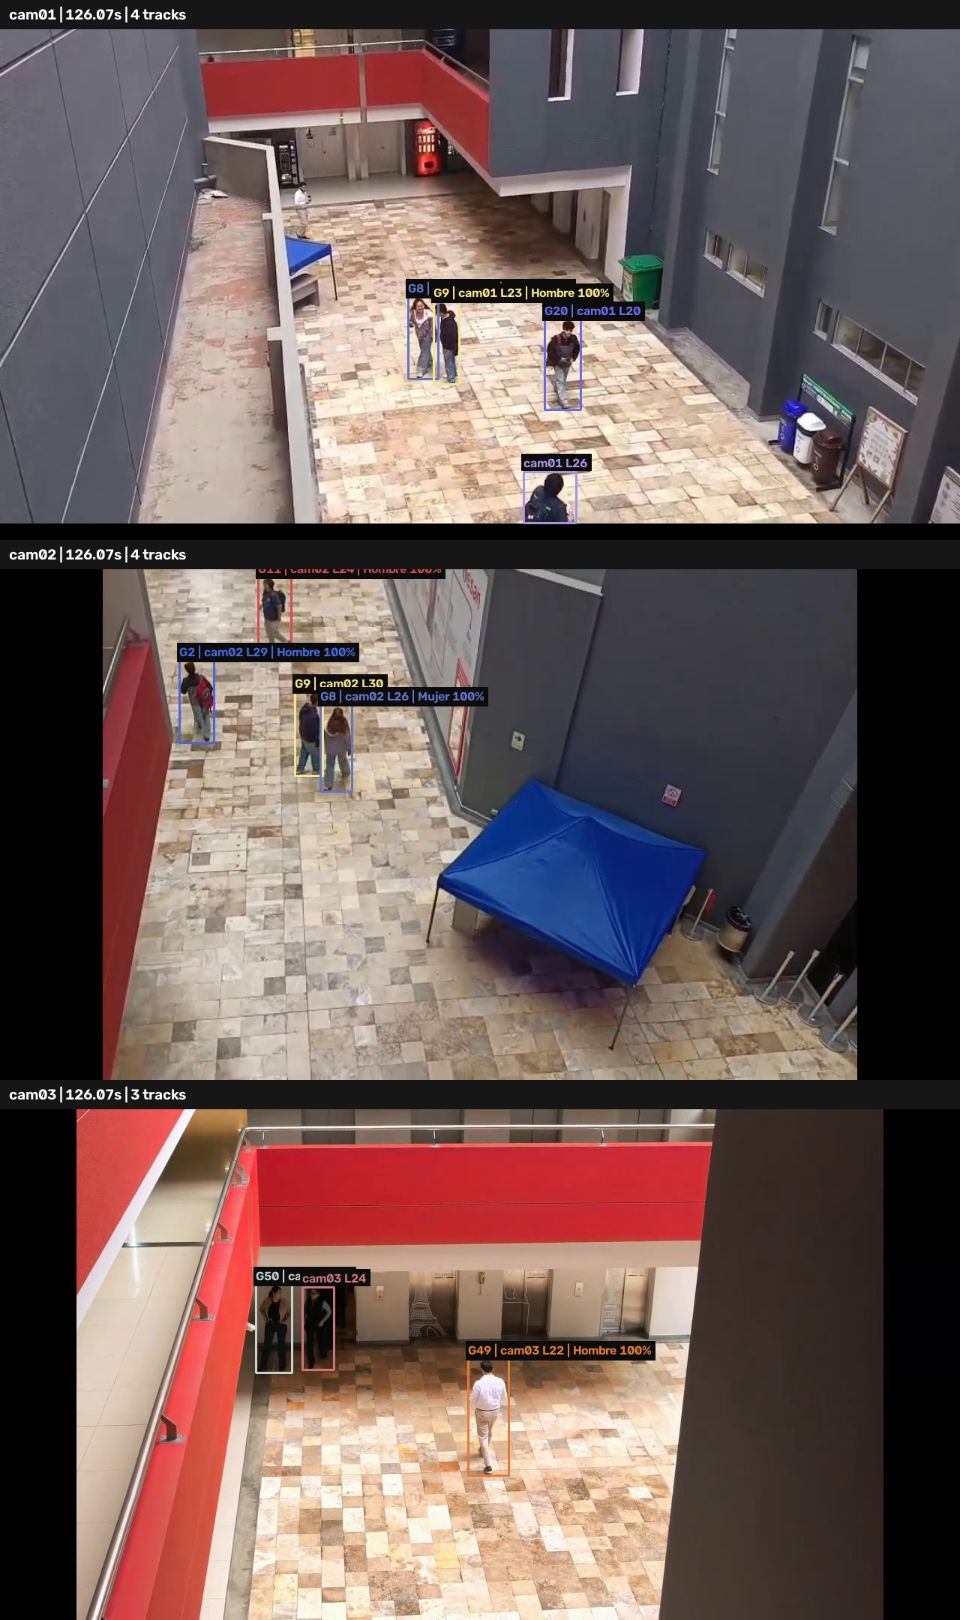

Sesión 20260926_165508_aa850d · completo · 5676 frames · 126.1 s de video
Capacidad: 10.47 FPS por cámara (31.40 FPS totales) en cuda:0


In [26]:
vista = VistaEnVivo(VISTA_ANCHO, camaras=len(VIDEOS)) if VISTA_EN_VIVO else None
resultado = procesar_videos(
    motor, asociador, VIDEOS,
    max_frames=MAX_FRAMES,
    tiempo_real=TIEMPO_REAL,
    preview=vista,
    preview_fps=VISTA_FPS,
    preview_width=VISTA_ANCHO,
    start_frames=INICIOS,
    cpu_threads=CPU_THREADS,
    inicio_grabacion=INICIO_GRABACION,
)
if vista is not None:
    vista.terminar(resultado)

r = resultado.resumen
print(f"Sesión {r['session_id']} · {r['status']} · {r['frames_total']} frames · {r['video_seconds']:.1f} s de video")
print(f"Capacidad: {r['fps_per_camera']:.2f} FPS por cámara ({r['fps_total']:.2f} FPS totales) en {r['device']}")

## 8. Auditoría

### 8.1 — Seguimiento local por cámara (LAP01)

Mide la fragmentación de IDs (IDs de 1–2 frames y duración mediana), las reapariciones (el mismo `local_id` vuelve tras frames ausente), los solapes entre cajas (IoU ≥ 0.12, es decir, cruces) y los diagnósticos internos del tracker. **No es ground truth:** IDF1 y los cambios de ID requieren anotaciones de referencia.

In [27]:
observaciones = resultado.observaciones()

auditoria = []
for cid in VIDEOS:
    grupo = observaciones[observaciones.camera_id == cid]
    fila = {"camera_id": cid, **resultado.resumen["cameras"][cid]}
    if not grupo.empty:
        duracion = grupo.groupby("local_id").frame.nunique()
        huecos = np.concatenate([np.diff(np.sort(g.frame.unique())) - 1 for _, g in grupo.groupby("local_id")])
        huecos = huecos[huecos > 0]
        solapes = 0
        for _, cuadro in grupo.groupby("frame"):
            cajas = cuadro[["x1", "y1", "x2", "y2"]].to_numpy()
            solapes += sum(_iou(cajas[i], cajas[j]) >= 0.12 for i in range(len(cajas)) for j in range(i + 1, len(cajas)))
        fila.update(ids_locales=int(grupo.local_id.nunique()), ids_cortos_1_2_frames=int((duracion <= 2).sum()),
                    duracion_mediana_frames=float(duracion.median()), reapariciones=int(len(huecos)),
                    frames_ocultos_max=int(huecos.max()) if len(huecos) else 0, solapes_iou_012=int(solapes))
    auditoria.append(fila)
display(pd.DataFrame(auditoria).set_index("camera_id").T)
if motor.genero.enabled:
    print("Estimación de género por identidad global (CLIP corporal; Sin determinar = evidencia insuficiente):")
    display(resultado.tabla_generos())

camera_id,cam01,cam02,cam03
low_quality_rejected,67.000,106.00,34.000
duplicates_suppressed,4.000,2.00,0.000
tracks_confirmed,26.000,30.00,24.000
reid_matches,69.000,21.00,23.000
short_occlusion_recoveries,63.000,17.00,15.000
low_confidence_updates,39.000,4.00,12.000
detections,6555.000,4809.00,3472.000
appearance_computed,1523.000,1201.00,808.000
appearance_share,0.232,0.25,0.233
active_tracks,6.000,5.00,4.000


Estimación de género por identidad global (CLIP corporal; Sin determinar = evidencia insuficiente):


,global_id,global_uuid,genero,confianza_genero,votos_genero
0,1,5ed83078-9ffa-55b4-94a7-574478594ac7,Hombre,0.917363,45
1,2,43c59dc6-3d45-5a45-8b59-6af7d0d62413,Hombre,0.739062,59
2,3,c9241524-97e8-5e2f-bf94-3318a29ba992,Sin determinar,NaN,0
3,4,de4b1fc3-083c-59fc-be96-4249158ca9e2,Sin determinar,NaN,13
4,5,47f762f3-7f14-5132-a046-89744972be97,Sin determinar,NaN,21
5,6,701683fe-8b90-5652-98c0-8b984ffb72a6,Hombre,0.987921,77
6,7,beda915d-8061-5a1e-b50f-add4cd73616b,Mujer,0.808583,72
7,8,41e8c95e-8a2a-561f-a52f-eb6edfcb03a2,Mujer,0.980178,48
8,9,af01913b-2949-5508-bea4-85ca97053555,Hombre,0.979791,83
9,10,12c991f0-bb38-56ad-a038-45efa1c6132f,Sin determinar,NaN,0


### 8.2 — Galería compartida e identidades multicámara (antes del mapa)

`galeria` muestra lo que las tres cámaras saben de cada persona contada: vistas por cámara y por orientación (frente, espalda, costado, quieto), segundos visible y última cámara donde se vio. `identidades` agrupa los tracklets de cada `global_id`, `tracklets` muestra su intervalo y sus muestras Re-ID, y `enlaces` registra cada fusión (`associate`) y separación (`separate`) con su puntaje. Los puntajes son similitudes, no probabilidades de acierto.

Son las decisiones del Re-ID. La sección 9 las revisa con el mapa y reconstruye estas tablas.

In [28]:
display(pd.Series(resultado.resumen["multicamera"], name="multicámara"))
print("Galería global compartida (lo que todas las cámaras saben de cada persona contada):")
display(pd.DataFrame(resultado.galeria))

identidades = pd.DataFrame(resultado.identidades)
if not identidades.empty:
    identidades["n_camaras"] = identidades.camaras.map(len)
    identidades = identidades.sort_values(["n_camaras", "global_id"], ascending=[False, True])
display(identidades.head(30))
tracklets = pd.DataFrame(resultado.tracklets)
if not tracklets.empty:
    tracklets = tracklets.sort_values(["global_id", "inicio_s"])
display(tracklets.head(30))
display(pd.DataFrame(resultado.enlaces).tail(30))

mode                          visual_temporal
geometria_validada                      False
identidades_globales                       21
pasadas_breves_no_contadas                 20
tracklets                                 102
identidades_multicamara                     9
muestras_reid                            1308
verificaciones                            258
fusiones                                   61
separaciones                                0
cambios_de_persona                         13
ambiguos                                    0
Name: multicámara, dtype: object

Galería global compartida (lo que todas las cámaras saben de cada persona contada):


,global_id,vistas,vistas_por_camara,frente,espalda,costado,quieto,segundos_visible,ultima_camara,ultima_vez_s,genero,confianza_genero,votos_genero
0,1,89,"{'cam03': 25, 'cam01': 35, 'cam02': 29}",19,30,32,8,33.4,cam01,45.07,Hombre,0.917363,45
1,2,185,"{'cam02': 81, 'cam01': 79, 'cam03': 25}",38,54,66,27,98.7,cam02,126.07,Hombre,0.739062,59
2,3,10,{'cam01': 10},0,0,9,1,3.6,cam01,3.73,Sin determinar,NaN,0
3,4,38,"{'cam02': 20, 'cam03': 18}",3,19,13,3,17.9,cam02,99.13,Sin determinar,NaN,13
4,5,58,"{'cam03': 10, 'cam02': 23, 'cam01': 25}",13,19,22,4,19.3,cam01,52.07,Sin determinar,NaN,21
5,6,138,"{'cam03': 33, 'cam01': 51, 'cam02': 54}",41,37,49,11,69.1,cam02,126.07,Hombre,0.987921,77
6,7,191,"{'cam02': 52, 'cam01': 73, 'cam03': 66}",38,48,81,24,97.4,cam01,126.07,Mujer,0.808583,72
7,8,114,"{'cam01': 52, 'cam02': 34, 'cam03': 28}",21,24,56,13,51.6,cam02,117.07,Mujer,0.980178,48
8,9,171,"{'cam02': 89, 'cam01': 58, 'cam03': 24}",39,38,68,26,86.3,cam02,126.07,Hombre,0.979791,83
9,10,7,{'cam01': 7},1,4,1,1,5.9,cam01,28.93,Sin determinar,NaN,0


,global_id,global_uuid,camaras,tracklets,inicio_s,fin_s,genero,confianza_genero,votos_genero,n_camaras
0,1,5ed83078-9ffa-55b4-94a7-574478594ac7,"[cam01, cam02, cam03]","[cam01/L1/T1, cam01/L9/T1, cam02/L1/T1, cam02/...",0.133333,45.066667,Hombre,0.917363,45,3
1,2,43c59dc6-3d45-5a45-8b59-6af7d0d62413,"[cam01, cam02, cam03]","[cam01/L11/T1, cam01/L2/T1, cam01/L20/T1, cam0...",0.133333,126.066667,Hombre,0.739062,59,3
4,5,47f762f3-7f14-5132-a046-89744972be97,"[cam01, cam02, cam03]","[cam01/L13/T1, cam01/L4/T1, cam02/L4/T1, cam03...",1.666667,52.066667,Sin determinar,NaN,21,3
5,6,701683fe-8b90-5652-98c0-8b984ffb72a6,"[cam01, cam02, cam03]","[cam01/L14/T1, cam01/L2/T2, cam01/L23/T1, cam0...",6.733333,126.066667,Hombre,0.987921,77,3
6,7,beda915d-8061-5a1e-b50f-add4cd73616b,"[cam01, cam02, cam03]","[cam01/L12/T1, cam01/L15/T1, cam01/L22/T1, cam...",6.866667,126.066667,Mujer,0.808583,72,3
7,8,41e8c95e-8a2a-561f-a52f-eb6edfcb03a2,"[cam01, cam02, cam03]","[cam01/L21/T1, cam01/L8/T1, cam01/L8/T3, cam02...",9.266667,117.066667,Mujer,0.980178,48,3
8,9,af01913b-2949-5508-bea4-85ca97053555,"[cam01, cam02, cam03]","[cam01/L10/T1, cam01/L18/T1, cam01/L18/T2, cam...",10.066667,126.066667,Hombre,0.979791,83,3
3,4,de4b1fc3-083c-59fc-be96-4249158ca9e2,"[cam02, cam03]","[cam02/L22/T1, cam03/L1/T1, cam03/L16/T1]",0.133333,99.133333,Sin determinar,NaN,13,2
12,13,4622defd-2744-5de6-b229-9a26be8bc4f5,"[cam01, cam02]","[cam01/L16/T1, cam01/L24/T1, cam02/L20/T1]",68.466667,121.600000,Mujer,0.758139,16,2
2,3,c9241524-97e8-5e2f-bf94-3318a29ba992,[cam01],[cam01/L3/T1],0.133333,3.733333,Sin determinar,NaN,0,1


,tracklet_id,tracklet,camera_id,local_id,global_id,contado,inicio_s,fin_s,observations,samples,frente,espalda,costado,entry,exit,association_score
0,3991f3a1-e4fb-5e49-98a8-c3641e8bbc0a,cam01/L1/T1,cam01,1,1.0,True,0.133333,12.400000,185,19,1,13,2,None,None,0.687988
3,5552e306-e8f2-5f61-a6e9-43b106e6ed3f,cam02/L1/T1,cam02,1,1.0,True,0.133333,5.333333,78,12,6,1,2,None,None,0.687988
7,5081395a-eb05-5197-b4f3-1ace873bb95a,cam03/L2/T1,cam03,2,1.0,True,1.000000,15.266667,215,16,2,1,12,None,None,0.687988
32,2461c87f-8508-53d0-9aa5-e015c899f5e3,cam03/L8/T1,cam03,8,1.0,True,26.266667,31.866667,85,9,0,1,8,None,None,0.687988
33,f8efac9d-e998-5628-964a-7910903c9da3,cam02/L12/T1,cam02,12,1.0,True,32.400000,44.333333,180,17,0,14,3,None,None,0.687988
35,1c408a2b-0e65-5242-973a-52e2ae38fd44,cam01/L9/T1,cam01,9,1.0,True,32.933333,45.066667,183,16,10,0,5,None,None,0.687988
1,62ce4818-02f1-59aa-a129-68d844005786,cam01/L2/T1,cam01,2,2.0,True,0.133333,8.466667,126,20,4,1,2,None,None,0.741715
4,0cc4d1ad-efc3-539c-b5db-9b2ebc0353c9,cam02/L2/T1,cam02,2,2.0,True,0.133333,29.933333,442,30,9,7,11,None,None,0.741715
24,9c3f5e0a-9efa-5b51-b671-2e2fd480fa9e,cam01/L6/T1,cam01,6,2.0,True,20.533333,34.533333,209,16,1,7,7,None,None,0.741715
41,b8e967d9-139f-5f68-b6f7-ec5d9e26991e,cam03/L7/T3,cam03,7,2.0,True,41.000000,56.266667,230,25,2,8,12,None,None,0.741715


,timestamp_s,event,global_id,absorbed_global_id,score,average,tracklet_a,tracklet_b
44,77.400000,associate,38,64,0.704055,0.704055,cam01/L17/T1,NaN
45,80.133333,associate,49,65,0.734269,0.734269,cam03/L13/T1,NaN
46,80.533333,associate,19,49,0.638506,0.573829,"cam03/L11/T1, cam03/L13/T1",NaN
47,82.000000,associate,15,67,0.694257,0.564155,cam03/L15/T1,NaN
48,85.000000,associate,19,69,0.655796,0.552137,cam01/L18/T1,NaN
49,84.733333,split,72,15,NaN,NaN,cam01/L15/T1,cam01/L15/T2
50,87.666667,associate,6,70,0.702021,0.702021,cam03/L16/T1,NaN
51,89.133333,split,73,19,NaN,NaN,cam01/L18/T1,cam01/L18/T2
52,91.933333,associate,6,74,0.670091,0.582975,cam02/L22/T1,NaN
53,93.866667,associate,2,77,0.651021,0.572307,cam01/L20/T1,NaN


## 9. Mapa 2D del piso

Las tres cámaras ven **el mismo piso** desde ángulos distintos. Sus posiciones se llevan a un plano común en metros, sin medidas manuales, en cinco pasos: uno por subsección.

| Paso | Pieza | Qué hace |
|---|---|---|
| 9.1 Estabilización | `EstabilizadorCamaras` | Compensa el movimiento de cada cámara frame a frame. |
| 9.2 Plano del piso | `ModeloPiso` | Altura, horizonte y focal de cada cámara a partir de las personas. |
| 9.3 Un solo mapa | `CalibradorMapa` | Desfase temporal y posición de cada cámara en un mapa común. |
| 9.4 Proyección | `proyectar_en_mapa` | x, y, velocidad y dirección de cada detección. |
| 9.5 Reagrupar | `ReagrupadorMapa` | Une a quien está en el mismo lugar a la vez y separa errores del Re-ID. |
| 9.6 Dibujo | `DibujoMapa` | Trayectorias y video del mapa sobre fondo liso. |

Medido con estos videos, con la calibración automática: altura de las cámaras 8.3 / 9.3 / 9.5 m; entre cámaras, residuo mediano de 0.28–0.48 m (98–100 % < 1 m); desfases de +1.0 s (cam02) y +3.0 s (cam03) respecto de cam01; el 93 % de las detecciones queda ubicado en el mapa; velocidad mediana al caminar 0.87 m/s. **Son medidas estimadas:** con medidas reales del lugar, la escala y las distancias serían exactas.

La calibración se guarda en `Modelo/mapa_piso.json` y las siguientes ejecuciones la reutilizan salvo que `RECALIBRAR_MAPA = True`. La estabilización se recalcula en cada ejecución, porque depende del movimiento de cada video. Tiempo adicional con el video completo: estabilización ~25 s, calibración ~11 s (solo la primera vez) y reagrupación < 1 s.

### 9.1 — Estabilización

Las cámaras se mueven: medí hasta 340 px de desplazamiento en cam02. Cada frame se registra contra el primero de su cámara con ORB + RANSAC, ignorando a las personas y las bandas negras. Se registra un frame de cada 2 y los intermedios se interpolan (error añadido de 1–3 px). Error mediano frente a un registro independiente: 1–3 px.

In [29]:
class EstabilizadorCamaras:
    """Homografía de cada frame procesado hacia el primero de su cámara (ORB + RANSAC, sin personas ni bandas).

    Se registra un frame de cada `paso` y los intermedios se interpolan: con paso=2 el error añadido fue de
    1–3 px (mediana), del orden del propio registro, y el tiempo baja a la mitad. paso=1 registra todos.
    """

    def __init__(self, escala=0.5, rasgos=1200, min_inliers=80, paso=2):
        self.escala, self.rasgos, self.min_inliers, self.paso = escala, rasgos, min_inliers, paso
        self._S = np.diag([escala, escala, 1.0])
        self._S_inv = np.linalg.inv(self._S)

    def __call__(self, resultado):
        """{cámara: array (frames, 3, 3)} con la homografía de cada frame hacia la referencia de su cámara."""
        cajas = defaultdict(list)
        for fila in resultado.filas:
            cajas[(fila["camera_id"], fila["frame"])].append((fila["x1"], fila["y1"], fila["x2"], fila["y2"]))
        with ThreadPoolExecutor(max_workers=len(resultado.metadata)) as pool:
            return dict(pool.map(lambda cid: (cid, self._camara(resultado, cid, cajas)), resultado.metadata))

    def _camara(self, resultado, cid, cajas):
        meta, inicio = resultado.metadata[cid], resultado.inicios[cid]
        orb = cv2.ORB_create(self.rasgos, fastThreshold=12)
        matcher = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
        cap = cv2.VideoCapture(meta["video"])
        for _ in range(inicio):
            cap.grab()
        total = resultado.resumen["frames_by_camera"][cid]
        registrados, referencia, anterior, H_anterior = {}, None, None, np.eye(3)
        for indice in range(total):
            if indice % self.paso and indice != total - 1:
                if not cap.grab():
                    break
                continue
            ok, frame = cap.read()
            if not ok:
                break
            actual = self._rasgos(orb, frame, meta["area"], cajas.get((cid, inicio + indice + 1), ()))
            if referencia is None:
                referencia, H = actual, np.eye(3)
            else:
                H, n = self._registrar(matcher, *actual, *referencia)       # directo contra la referencia: sin deriva
                if H is None or n < self.min_inliers:
                    H_paso, _ = self._registrar(matcher, *actual, *anterior)  # respaldo encadenado con el último registrado
                    H = H_anterior @ H_paso if H_paso is not None else H_anterior
            registrados[indice] = H_anterior = H / H[2, 2]
            anterior = actual
        cap.release()
        return self._interpolar(registrados)

    def _rasgos(self, orb, frame, area, cajas):
        """Puntos ORB del fondo: sin bandas negras, sin el borde y sin las cajas de las personas."""
        escala = self.escala
        gris = cv2.resize(cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY), None, fx=escala, fy=escala)
        mascara = np.zeros_like(gris)
        x0, y0, x1, y1 = (int(v * escala) for v in area)
        mascara[y0 + 6:y1 - 6, x0 + 6:x1 - 6] = 255
        for bx1, by1, bx2, by2 in cajas:
            cv2.rectangle(mascara, (int(bx1 * escala) - 4, int(by1 * escala) - 4),
                          (int(bx2 * escala) + 4, int(by2 * escala) + 4), 0, -1)
        return orb.detectAndCompute(gris, mascara)

    def _registrar(self, matcher, ka, da, kb, db):
        """Homografía a -> b en píxeles del video y su número de inliers; (None, 0) si no se puede registrar."""
        if da is None or db is None or min(len(ka), len(kb)) < 20:
            return None, 0
        pares = matcher.match(da, db)
        if len(pares) < 20:
            return None, 0
        H, inliers = cv2.findHomography(np.float32([ka[p.queryIdx].pt for p in pares]),
                                        np.float32([kb[p.trainIdx].pt for p in pares]), cv2.RANSAC, 2.0)
        return (None, 0) if H is None else (self._S_inv @ H @ self._S, int(inliers.sum()))

    @staticmethod
    def _interpolar(registrados):
        """Completa los frames no registrados interpolando entre los registrados vecinos."""
        claves = sorted(registrados)
        homografias = []
        for indice in range(claves[-1] + 1):
            j = np.searchsorted(claves, indice)
            if claves[j] == indice:
                homografias.append(registrados[indice])
            else:
                a, b = claves[j - 1], claves[j]
                w = (indice - a) / (b - a)
                homografias.append((1 - w) * registrados[a] + w * registrados[b])
        return np.stack(homografias)

### 9.2 — Plano del piso de cada cámara

Una persona de pie mide ~1.70 m. En una cámara pinhole, la escala lateral de un punto del suelo es lineal en la imagen, $f/Z = (n_x x + n_y y + n_z f - n_x c_x - n_y c_y)/H$. Al ajustar la altura en píxeles de las personas contra la posición de sus pies se obtienen el horizonte y la altura $H$ de la cámara. La focal $f$ se elige para que la gente camine a la misma velocidad hacia los lados que hacia adelante.

`ModeloPiso` guarda esa cámara y da la homografía exacta imagen → piso: con $r=K^{-1}[u,v,1]^T$, el punto del piso es $(x,y)=H\,(e_1\cdot r,\ e_2\cdot r)/(n\cdot r)$.

In [30]:
ALTURA_PERSONA_M = 1.70


@dataclass
class ModeloPiso:
    """Piso visto por una cámara pinhole: focal f, punto principal pp, normal n, altura y ejes e1 (lateral), e2 (adelante)."""
    f: float
    pp: tuple
    n: np.ndarray
    altura: float
    e1: np.ndarray
    e2: np.ndarray
    coef_escala: np.ndarray   # alto/1.70 = a·x + b·y + c

    @classmethod
    def desde_escala(cls, coef, f, pp):
        """El ajuste de escala fija el horizonte y la altura; la focal completa la cámara (e1 × e2 = arriba)."""
        a, b, c = coef
        v = np.array([a, b, (c + a * pp[0] + b * pp[1]) / f])
        altura = 1.0 / np.linalg.norm(v)
        n = v * altura
        e1 = np.array([1.0, 0.0, 0.0]) - n[0] * n
        e1 /= np.linalg.norm(e1)
        return cls(float(f), tuple(map(float, pp)), n, float(altura), e1, np.cross(e1, n), np.asarray(coef))

    def a_piso(self, puntos):
        """Píxeles de la imagen de referencia -> metros en el piso de esta cámara (NaN sobre el horizonte)."""
        puntos = np.atleast_2d(np.asarray(puntos, dtype=np.float64))
        rayos = np.column_stack([(puntos[:, 0] - self.pp[0]) / self.f,
                                 (puntos[:, 1] - self.pp[1]) / self.f, np.ones(len(puntos))])
        den = rayos @ self.n
        Z = np.where(den > 1e-6, self.altura / np.maximum(den, 1e-6), np.nan)
        P3 = rayos * Z[:, None] - self.altura * self.n
        return np.column_stack([P3 @ self.e1, P3 @ self.e2])

    def homografia(self):
        """Homografía exacta imagen de referencia -> piso: H = diag(h, h, 1)·[e1; e2; n]·K⁻¹."""
        K = np.array([[self.f, 0.0, self.pp[0]], [0.0, self.f, self.pp[1]], [0.0, 0.0, 1.0]])
        H = np.diag([self.altura, self.altura, 1.0]) @ np.vstack([self.e1, self.e2, self.n]) @ np.linalg.inv(K)
        return H / H[2, 2]


def observaciones_en_referencia(resultado, estabilizacion):
    """Pie y altura de cada detección en la imagen de referencia de su cámara, con marca de fiabilidad."""
    por_frame = defaultdict(list)
    for fila in resultado.filas:
        por_frame[(fila["camera_id"], fila["frame"])].append(fila)
    obs = defaultdict(list)
    for (cid, numero), filas in por_frame.items():
        H = estabilizacion[cid][numero - resultado.inicios[cid] - 1]
        x0, y0, x1, y1 = resultado.metadata[cid]["area"]
        puntos = []
        for fila in filas:
            xc = (fila["x1"] + fila["x2"]) / 2
            puntos += [[xc, fila["y2"]], [xc, fila["y1"]]]
        ref = cv2.perspectiveTransform(np.float32(puntos).reshape(-1, 1, 2), H).reshape(-1, 2, 2)
        cajas = np.array([[f["x1"], f["y1"], f["x2"], f["y2"]] for f in filas])
        for i, fila in enumerate(filas):
            otras = np.delete(cajas, i, axis=0)
            solape = 0.0
            if len(otras):
                ix = np.clip(np.minimum(fila["x2"], otras[:, 2]) - np.maximum(fila["x1"], otras[:, 0]), 0, None)
                iy = np.clip(np.minimum(fila["y2"], otras[:, 3]) - np.maximum(fila["y1"], otras[:, 1]), 0, None)
                solape = float((ix * iy).max() / max(1.0, (fila["x2"] - fila["x1"]) * (fila["y2"] - fila["y1"])))
            borde = fila["x1"] < x0 + 8 or fila["y1"] < y0 + 8 or fila["x2"] > x1 - 8 or fila["y2"] > y1 - 8
            obs[cid].append({"t": fila["timestamp_s"], "global_id": fila["global_id"], "tracklet": fila["tracklet_id"],
                             "pie": ref[i, 0], "alto": float(np.linalg.norm(ref[i, 0] - ref[i, 1])),
                             "pies_cortados": fila["y2"] >= y1 - 3,
                             "fiable": not borde and solape < 0.05 and fila["confidence"] >= 0.6 and fila["y2"] - fila["y1"] >= 45})
    return obs


def ajustar_escala_personas(obs_camara):
    """alto/1.70 = a·x + b·y + c sobre los pies (mínimos cuadrados robustos de Huber)."""
    fiables = [o for o in obs_camara if o["fiable"]]
    X = np.array([[o["pie"][0], o["pie"][1], 1.0] for o in fiables])
    s = np.array([o["alto"] / ALTURA_PERSONA_M for o in fiables])
    pesos = np.ones(len(s))
    for _ in range(15):
        coef = np.linalg.lstsq(X * pesos[:, None], s * pesos, rcond=None)[0]
        residuo = s - X @ coef
        escala = 1.4826 * np.median(np.abs(residuo)) + 1e-6
        pesos = np.sqrt(np.clip(1.345 * escala / (np.abs(residuo) + 1e-9), None, 1.0))
    return coef


def focal_por_isotropia(modelo_de, obs_camara, candidatas=np.exp(np.linspace(np.log(400), np.log(5000), 60))):
    """La focal que hace que la gente camine igual de rápido hacia los lados que hacia adelante."""
    por_tracklet = defaultdict(list)
    for o in obs_camara:
        por_tracklet[o["tracklet"]].append(o)
    tramos = [sorted(v, key=lambda o: o["t"]) for v in por_tracklet.values() if len(v) >= 20]
    mejor = None
    for f in candidatas:
        modelo = modelo_de(f)
        lateral, adelante = [], []
        for filas in tramos:
            t = np.array([o["t"] for o in filas])
            g = modelo.a_piso(np.array([o["pie"] for o in filas]))
            for i in range(0, len(filas) - 15, 5):
                j = i + 15
                dt = t[j] - t[i]
                if not 0 < dt <= 1.5:
                    continue
                v = (np.median(g[j - 2:j + 1], 0) - np.median(g[i:i + 3], 0)) / dt
                rapidez = float(np.hypot(*v))
                if np.isfinite(rapidez) and 0.3 <= rapidez <= 4:
                    if abs(v[0]) > 2 * abs(v[1]):
                        lateral.append(rapidez)
                    elif abs(v[1]) > 2 * abs(v[0]):
                        adelante.append(rapidez)
        if len(lateral) >= 30 and len(adelante) >= 30:
            desbalance = abs(np.log(np.median(lateral)) - np.log(np.median(adelante)))
            if mejor is None or desbalance < mejor[0]:
                mejor = (desbalance, float(f))
    if mejor is None:
        raise ValueError("No hay suficientes personas caminando para estimar la focal.")
    return mejor[1]

### 9.3 — Un solo mapa

Una persona vista a la vez por dos cámaras está en el mismo punto del piso. Con esos pares (mismo `global_id`) se estiman, con RANSAC y un ajuste conjunto, el **desfase temporal** y la rotación, traslación y escala de cada cámara respecto de la primera. Después se fija la escala global y se gira el mapa para que el recorrido principal quede horizontal.

Los desfases sincronizan las posiciones del mapa y los `timestamp` de `trajectory_points`. La asociación entre cámaras no los necesita: con ellos dio el mismo resultado (precisión 0.99, recall 0.85–0.86).

In [31]:
class CalibradorMapa:
    """Mapa común en metros a partir de las propias personas, sin medidas del lugar."""

    def __init__(self, px_por_metro=40):
        self.px_por_metro = px_por_metro

    def calibrar(self, resultado, estabilizacion, config_camaras):
        obs = observaciones_en_referencia(resultado, estabilizacion)
        camaras = sorted(obs)
        modelos, informe = self._modelos(resultado, obs, camaras, config_camaras)
        pistas = self._pistas_por_camara(obs, modelos)
        relativos, iniciales = self._desfases(pistas, camaras)
        params, informe_pares = self._ajuste_conjunto(pistas, camaras, relativos, iniciales)
        informe.update(informe_pares)
        H_metros, poses = self._orientar(params, pistas, camaras, modelos)
        x0, y0, x1, y1 = self._extension(obs, H_metros, camaras)
        k = self.px_por_metro
        # Desfase absoluto: tiempo común = tiempo del video + desfase (independiente de camaras.json).
        desfases = {cid: float(resultado.offsets[cid] + relativos[cid]) for cid in camaras}
        return {"px_por_metro": k, "origen_m": [float(x0), float(y1)],
                "tam_px": [int((x1 - x0) * k), int((y1 - y0) * k)],
                "desfases_s": desfases, "homografias": {c: H.tolist() for c, H in H_metros.items()},
                "camaras": {c: {**poses[c], "altura_m": modelos[c].altura, "focal_px": modelos[c].f,
                                "coef_escala": modelos[c].coef_escala.tolist()} for c in camaras},
                "informe": informe}

    # ------------------------------------------------------------------ pasos
    @staticmethod
    def _modelos(resultado, obs, camaras, config_camaras):
        """Paso 1: ModeloPiso de cada cámara (escala de las personas + focal por isotropía)."""
        modelos, informe = {}, {}
        for cid in camaras:
            area = resultado.metadata[cid]["area"]
            pp = config_camaras["cameras"][cid].get("principal_point") or ((area[0] + area[2]) / 2, (area[1] + area[3]) / 2)
            coef = ajustar_escala_personas(obs[cid])
            f = focal_por_isotropia(lambda f: ModeloPiso.desde_escala(coef, f, pp), obs[cid])
            modelos[cid] = ModeloPiso.desde_escala(coef, f, pp)
            informe[cid] = {"focal_px": round(f), "altura_camara_m": round(modelos[cid].altura, 2)}
        return modelos, informe

    def _desfases(self, pistas, camaras):
        """Paso 2: desfase y semejanza iniciales de cada cámara respecto de la base (búsqueda gruesa y fina con RANSAC)."""
        base = camaras[0]
        relativos, iniciales = {base: 0.0}, {}   # sobre los timestamps actuales (ya incluyen timestamp_offset)
        for cid in camaras[1:]:
            candidatos = []
            for rango in (np.arange(-10, 10.01, 0.5), None):
                if rango is None:
                    if not candidatos:
                        break
                    centro = max(candidatos, key=lambda c: c[0])[1]
                    rango = np.arange(centro - 0.5, centro + 0.51, 0.1)
                for delta in rango:
                    P, Q = self._pares_simultaneos(pistas, base, cid, delta)
                    ajuste = self._ransac_semejanza(P, Q) if len(P) >= 10 else None
                    if ajuste is not None:
                        candidatos.append((ajuste[0], float(delta), ajuste[1]))
            if not candidatos:
                raise ValueError(f"{cid}: no hay personas vistas a la vez con {base} para ubicarla en el mapa.")
            _, relativos[cid], (s, R, t) = max(candidatos, key=lambda c: c[0])
            iniciales[cid] = [np.log(s), np.arctan2(R[1, 0], R[0, 0]), t[0], t[1]]
        return relativos, iniciales

    def _ajuste_conjunto(self, pistas, camaras, relativos, iniciales):
        """Paso 3: semejanzas de todas las cámaras a la vez con todos los pares (mínimos cuadrados robustos)."""
        from scipy.optimize import least_squares

        base, otras = camaras[0], camaras[1:]
        pares = [(ca, cb, *self._pares_simultaneos(pistas, ca, cb, relativos[cb] - relativos[ca]))
                 for i, ca in enumerate(camaras) for cb in camaras[i + 1:]]

        def parametros(x):
            p = {base: np.zeros(4)}
            p.update({cid: x[4 * i:4 * i + 4] for i, cid in enumerate(otras)})
            return p

        def residuos(x):
            p = parametros(x)
            return np.concatenate([(self._aplicar(p[cb], Pb) - self._aplicar(p[ca], Qa)).ravel()
                                   for ca, cb, Pb, Qa in pares if len(Pb)])

        solucion = least_squares(residuos, np.concatenate([iniciales[c] for c in otras]), loss="soft_l1", f_scale=0.5)
        params, informe = parametros(solucion.x), {}
        for ca, cb, Pb, Qa in pares:
            if len(Pb):
                d = np.linalg.norm(self._aplicar(params[cb], Pb) - self._aplicar(params[ca], Qa), axis=1)
                informe[f"{cb}->{ca}"] = {"pares": len(d), "residuo_mediano_m": round(float(np.median(d)), 2),
                                          "menos_de_1m": round(float(np.mean(d < 1)), 3)}
        return params, informe

    def _orientar(self, params, pistas, camaras, modelos):
        """Paso 4: escala global (media geométrica = 1), giro del recorrido principal y homografía imagen -> mapa."""
        g = float(np.exp(-np.mean([params[c][0] for c in camaras])))
        todos = np.vstack([self._aplicar(params[c], np.vstack([v[2] for v in pistas[c].values()])) for c in camaras if pistas[c]])
        centro = todos.mean(0)
        eje = np.linalg.eigh(np.cov((todos - centro).T))[1][:, -1]
        giro = -np.arctan2(eje[1], eje[0])
        Rg = np.array([[np.cos(giro), -np.sin(giro)], [np.sin(giro), np.cos(giro)]])
        H_metros, poses = {}, {}
        for cid in camaras:
            s, th, tx, ty = np.exp(params[cid][0]), *params[cid][1:]
            R = np.array([[np.cos(th), -np.sin(th)], [np.sin(th), np.cos(th)]])
            A = np.eye(3)
            A[:2, :2] = g * Rg @ (s * R)
            A[:2, 2] = g * Rg @ (np.array([tx, ty]) - centro)
            H_metros[cid] = A @ modelos[cid].homografia()
            poses[cid] = {"posicion_m": A[:2, 2].tolist(), "direccion": (A[:2, :2] @ [0.0, 1.0]).tolist()}
        return H_metros, poses

    @staticmethod
    def _extension(obs, H_metros, camaras):
        """Paso 5: región conexa principal de celdas de 0.5 m con ≥ 8 pies, con margen. (x0, y0, x1, y1) en metros."""
        pies = {cid: cv2.perspectiveTransform(np.float32([o["pie"] for o in obs[cid]]).reshape(-1, 1, 2),
                                              H_metros[cid]).reshape(-1, 2) for cid in camaras}
        pies = {cid: p[np.isfinite(p).all(1)] for cid, p in pies.items()}
        celdas, cuenta = np.unique(np.floor(np.vstack(list(pies.values())) / 0.5).astype(int), axis=0, return_counts=True)
        densas = celdas[cuenta >= 8]
        minimo = densas.min(0)
        rejilla = np.zeros(tuple(densas.max(0) - minimo + 1)[::-1], np.uint8)
        rejilla[densas[:, 1] - minimo[1], densas[:, 0] - minimo[0]] = 1
        _, componentes, stats, _ = cv2.connectedComponentsWithStats(cv2.dilate(rejilla, np.ones((5, 5), np.uint8)))
        grande = 1 + int(np.argmax(stats[1:, cv2.CC_STAT_AREA]))
        principal = {(int(x), int(y)) for x, y in densas if componentes[y - minimo[1], x - minimo[0]] == grande}
        extremos = np.array(sorted(principal)) * 0.5
        x0, y0 = extremos.min(0) - 2.5
        x1, y1 = extremos.max(0) + 3.0
        return x0, y0, x1, y1

    # ------------------------------------------------------------------ geometría
    @staticmethod
    def _pistas_por_camara(obs, modelos):
        """Recorrido suavizado de cada tracklet contado, en metros del piso de su cámara."""
        pistas = defaultdict(dict)
        for cid, filas in obs.items():
            por_tracklet = defaultdict(list)
            for o in filas:
                if o["global_id"] is not None and not o["pies_cortados"]:
                    por_tracklet[o["tracklet"]].append(o)
            for tracklet, fs in por_tracklet.items():
                fs.sort(key=lambda o: o["t"])
                t = np.array([o["t"] for o in fs])
                g = modelos[cid].a_piso(np.array([o["pie"] for o in fs]))
                ok = np.isfinite(g).all(1)
                if ok.sum() >= 10:
                    t, g = t[ok], g[ok]
                    pistas[cid][tracklet] = (fs[0]["global_id"], t, np.array([np.median(g[max(0, i - 5):i + 6], 0) for i in range(len(g))]))
        return pistas

    @staticmethod
    def _pares_simultaneos(pistas, ca, cb, desfase_b, paso=0.25):
        """Misma persona (global_id) vista a la vez: (posición en cb, posición en ca) con t_ca = t_cb + desfase_b."""
        A, B = [], []
        for gid_a, ta, ga in pistas[ca].values():
            for gid_b, tb, gb in pistas[cb].values():
                if gid_a != gid_b:
                    continue
                for t in np.arange(max(ta[0], tb[0] + desfase_b), min(ta[-1], tb[-1] + desfase_b), paso):
                    ia, ib = np.searchsorted(ta, t), np.searchsorted(tb, t - desfase_b)
                    if 0 < ia < len(ta) and 0 < ib < len(tb) and ta[ia] - ta[ia - 1] < 0.3 and tb[ib] - tb[ib - 1] < 0.3:
                        A.append((np.interp(t, ta, ga[:, 0]), np.interp(t, ta, ga[:, 1])))
                        B.append((np.interp(t - desfase_b, tb, gb[:, 0]), np.interp(t - desfase_b, tb, gb[:, 1])))
        return np.array(B).reshape(-1, 2), np.array(A).reshape(-1, 2)

    @staticmethod
    def _semejanza(P, Q):
        """Umeyama: Q ≈ s·R·P + t."""
        mp, mq = P.mean(0), Q.mean(0)
        X, Y = P - mp, Q - mq
        U, S, Vt = np.linalg.svd(Y.T @ X / len(P))
        d = np.sign(np.linalg.det(U @ Vt))
        R = U @ np.diag([1, d]) @ Vt
        s = (S * [1, d]).sum() / (X ** 2).sum(1).mean()
        return s, R, mq - s * R @ mp

    @classmethod
    def _ransac_semejanza(cls, P, Q, umbral=1.0, iteraciones=500, semilla=0):
        rng = np.random.default_rng(semilla)  # un generador nuevo por llamada: recalibrar da siempre lo mismo
        mejor = None
        for _ in range(iteraciones):
            i = rng.choice(len(P), 2, replace=False)
            if np.linalg.norm(P[i[0]] - P[i[1]]) < 1.0:
                continue
            s, R, t = cls._semejanza(P[i], Q[i])
            if not 0.5 < s < 2.0:
                continue
            inliers = np.linalg.norm(s * P @ R.T + t - Q, axis=1) < umbral
            if mejor is None or inliers.sum() > mejor.sum():
                mejor = inliers
        if mejor is None or mejor.sum() < 10:
            return None
        for _ in range(3):
            s, R, t = cls._semejanza(P[mejor], Q[mejor])
            mejor = np.linalg.norm(s * P @ R.T + t - Q, axis=1) < umbral
        return int(mejor.sum()), (s, R, t)

    @staticmethod
    def _aplicar(p, X):
        s, th = np.exp(p[0]), p[1]
        R = np.array([[np.cos(th), -np.sin(th)], [np.sin(th), np.cos(th)]])
        return s * X @ R.T + p[2:4]


def metros_a_px(mapa):
    x0, y1 = mapa["origen_m"]
    k = mapa["px_por_metro"]
    return np.array([[k, 0, -x0 * k], [0, -k, y1 * k], [0, 0, 1]])


def guardar_mapa(mapa, carpeta=MODELO):
    (carpeta / "mapa_piso.json").write_text(json.dumps(mapa, ensure_ascii=False, indent=2) + "\n")


def cargar_mapa(carpeta=MODELO):
    ruta = carpeta / "mapa_piso.json"
    return json.loads(ruta.read_text()) if ruta.is_file() else None

### 9.4 — Proyección de cada detección

Cada fila se lleva al mapa con la homografía de su cámara y la estabilización de su frame. Las posiciones se suavizan por tracklet (mediana de 11 frames) y la velocidad y la dirección salen de una ventana de 1 s. Los pies cortados por el borde inferior no se proyectan. `posiciones_por_persona` combina las cámaras en una sola posición por persona e instante (pesa más la cámara que la ve más grande).

In [32]:
def proyectar_en_mapa(resultado, estabilizacion, mapa, suavizado=5):
    """Llena X, Y (metros), speed, direction_deg y timestamp sincronizado de cada fila con el mapa calibrado.

    Tiempo común = tiempo del video + desfase medido de la cámara. Los pies cortados por el borde no se proyectan.
    """
    homografias = {cid: np.array(H) for cid, H in mapa["homografias"].items()}
    por_tracklet = defaultdict(list)
    for fila in resultado.filas:
        cid = fila["camera_id"]
        meta = resultado.metadata[cid]
        fila["timestamp_s"] = (fila["frame"] - 1) / meta["fps"] + mapa["desfases_s"][cid]
        fila.update(X=None, Y=None, speed=None, direction_deg=None, projection_valid=False)
        if fila["y2"] >= meta["area"][3] - 3:
            continue
        H = homografias[cid] @ estabilizacion[cid][fila["frame"] - resultado.inicios[cid] - 1]
        x, y = cv2.perspectiveTransform(np.float32([[[(fila["x1"] + fila["x2"]) / 2, fila["y2"]]]]), H)[0, 0]
        if np.isfinite([x, y]).all():
            por_tracklet[fila["tracklet_id"]].append((fila, float(x), float(y)))
    for filas in por_tracklet.values():
        filas.sort(key=lambda item: item[0]["timestamp_s"])
        t = np.array([f["timestamp_s"] for f, _, _ in filas])
        xy = np.array([[x, y] for _, x, y in filas])
        xy = np.array([np.median(xy[max(0, i - suavizado):i + suavizado + 1], 0) for i in range(len(xy))])
        for i, (fila, _, _) in enumerate(filas):
            fila.update(X=float(xy[i, 0]), Y=float(xy[i, 1]), projection_valid=True)
            a, b = np.searchsorted(t, t[i] - 0.5), min(len(t) - 1, np.searchsorted(t, t[i] + 0.5) - 1)
            if b > a and t[b] - t[a] >= 0.4:
                v = (xy[b] - xy[a]) / (t[b] - t[a])
                fila["speed"] = float(np.hypot(*v))
                if fila["speed"] > 0.05:
                    fila["direction_deg"] = float(np.degrees(np.arctan2(v[1], v[0])) % 360.0)
    resultado.offsets = dict(mapa["desfases_s"])


def posiciones_por_persona(resultado, fps=15.0, suavizado_s=0.6):
    """Una posición por persona e instante: promedio entre cámaras (pesa más la que la ve más grande) y suavizado."""
    acumulado = defaultdict(lambda: defaultdict(lambda: np.zeros(3)))
    for fila in resultado.filas:
        if fila["global_id"] is not None and fila["projection_valid"]:
            peso = fila["y2"] - fila["y1"]
            acumulado[fila["global_id"]][int(round(fila["timestamp_s"] * fps))] += [fila["X"] * peso, fila["Y"] * peso, peso]
    ventana = int(suavizado_s * fps / 2)
    posiciones = {}
    for gid, por_tick in acumulado.items():
        crudas = {k: (v[0] / v[2], v[1] / v[2]) for k, v in por_tick.items()}
        posiciones[gid] = {k: tuple(np.mean([crudas[j] for j in range(k - ventana, k + ventana + 1) if j in crudas], axis=0))
                           for k in crudas}
    return posiciones

### 9.5 — Reagrupar identidades con el mapa

Ya en metros y sincronizadas, dos cámaras que ven a la misma persona la ubican casi en el mismo punto: 0.35 m de mediana entre tracklets con el mismo `global_id`, frente a 6.3 m entre personas distintas. `ReagrupadorMapa` (`UNIR_CON_MAPA`) pone esa evidencia física antes que el Re-ID:

1. **Choque:** dos tracklets a la vez en una misma cámara, o a la vez a más de 2 m en el mapa, nunca son la misma persona.
2. **Juntos:** dos tracklets de cámaras distintas que comparten ≥ 2 s con distancia mediana ≤ 0.7 m y ≥ 90 % del tiempo a menos de 1 m se unen, salvo choque.
3. **Re-ID después:** cada `global_id` vuelve a unir sus tracklets, salvo choque o si los grupos ya formados no se parecen (enlace promedio de sus prototipos Re-ID < 0.50). Un tracklet que el Re-ID había puesto en la persona equivocada queda aparte, en lugar de bloquear la unión correcta.
4. **Conteo:** se cuenta a quien reúne `min_samples` vistas y `min_identity_duration_s` visible, igual que en el Re-ID. IDs 1..N por orden de aparición.

En este video:
- **Personas partidas.** El Re-ID dejaba a una persona en 2–4 IDs. Por ejemplo, alguien con mochila roja: de espaldas en `cam01` y de frente en `cam03` el Re-ID no lo reconoce; con el mapa queda una sola persona con 15 tracklets en las 3 cámaras.
- **Personas mezcladas.** El Re-ID también juntaba a personas parecidas que nunca coinciden en el tiempo: un hombre de gorra blanca y maletín (69–96 s) con otro de gorra beige y mochila (110–127 s), y un hombre de polerón azul con una mujer de pelo largo. Ya agrupados con el mapa, sus prototipos dan 0.44 y 0.42, mientras que las uniones correctas dieron 0.55–0.71: se separan. Con 0.55 ya se partía a una persona correcta; el umbral de 0.50 sale de este video.
- **Resultado:** 21 personas del Re-ID → **16**, con 10 multicámara. Las uniones y separaciones se revisaron a ojo con un recorte por tracklet; queda un error menor (un tracklet de 3 s de `cam03` asignado a otra persona).

Después de reagrupar se reconstruyen `galeria`, `identidades` y `tracklets`, y se añaden los eventos `map_merge` y `map_separate` a `enlaces`.

In [33]:
def _segundos_visibles(intervalos):
    """Duración de la unión de intervalos (inicio, fin)."""
    total, (inicio, fin) = 0.0, min(intervalos)
    for a, b in sorted(intervalos):
        if a > fin:
            total, inicio, fin = total + fin - inicio, a, b
        else:
            fin = max(fin, b)
    return total + fin - inicio


def _tablas_por_identidad(tracklets, global_uuid):
    """identidades y galería reconstruidas desde la tabla de tracklets (tras renumerar los global_id)."""
    grupos = defaultdict(list)
    for t in tracklets:
        if t["global_id"] is not None:
            grupos[t["global_id"]].append(t)
    identidades, galeria = [], []
    for gid, ts in sorted(grupos.items()):
        por_camara = defaultdict(int)
        for t in ts:
            por_camara[t["camera_id"]] += t["samples"]
        frente, espalda, costado = (sum(t[k] for t in ts) for k in ("frente", "espalda", "costado"))
        ultimo = max(ts, key=lambda t: t["fin_s"])
        identidades.append({"global_id": gid, "global_uuid": global_uuid[gid], "camaras": sorted(por_camara),
                            "tracklets": sorted(t["tracklet"] for t in ts), "inicio_s": min(t["inicio_s"] for t in ts),
                            "fin_s": ultimo["fin_s"]})
        galeria.append({"global_id": gid, "vistas": sum(por_camara.values()), "vistas_por_camara": dict(por_camara),
                        "frente": frente, "espalda": espalda, "costado": costado,
                        "quieto": sum(por_camara.values()) - frente - espalda - costado,
                        "segundos_visible": round(_segundos_visibles([(t["inicio_s"], t["fin_s"]) for t in ts]), 1),
                        "ultima_camara": ultimo["camera_id"], "ultima_vez_s": round(ultimo["fin_s"], 2)})
    return identidades, galeria


class _Grupos:
    """Conjuntos disjuntos de tracklets que nunca juntan dos tracklets que chocan."""

    def __init__(self, uids, choques):
        self.de = {u: u for u in uids}
        self.miembros = {u: {u} for u in uids}
        self.choques = choques

    def unir(self, a, b, aceptar=None):
        """Une los grupos de a y b; False si algún par choca o si aceptar(miembros_a, miembros_b) lo rechaza."""
        ga, gb = self.de[a], self.de[b]
        if ga == gb:
            return True
        if any((x, y) in self.choques for x in self.miembros[ga] for y in self.miembros[gb]):
            return False
        if aceptar is not None and not aceptar(self.miembros[ga], self.miembros[gb]):
            return False
        if len(self.miembros[ga]) < len(self.miembros[gb]):
            ga, gb = gb, ga
        for u in self.miembros.pop(gb):
            self.de[u] = ga
            self.miembros[ga].add(u)
        return True

`ReagrupadorMapa` sigue los cuatro pasos de arriba: `_pares` (juntos y choques), unión por el mapa, `_aplicar_reid`, `_contar` y `_publicar`.

In [34]:
class ReagrupadorMapa:
    """Reagrupa los tracklets con el mapa: primero la evidencia física y después el Re-ID, solo si no la contradice."""

    def __init__(self, min_juntos_s=2.0, max_mediana_m=0.7, min_cerca=0.9, separados_m=2.0, min_parecido=0.50,
                 min_muestras=5, min_visible_s=2.0):
        self.min_juntos_s, self.max_mediana_m, self.min_cerca = min_juntos_s, max_mediana_m, min_cerca
        self.separados_m, self.min_parecido = separados_m, min_parecido
        self.min_muestras, self.min_visible_s = min_muestras, min_visible_s

    def __call__(self, resultado):
        """Actualiza `resultado` (global_id, tablas, enlaces y resumen) y devuelve la tabla de cambios."""
        fps = max(meta["fps"] for meta in resultado.metadata.values())
        datos = self._recorridos(resultado.filas, fps)
        juntos, choques = self._pares(datos, fps)
        grupos = _Grupos(sorted(datos), choques)
        for _, _, a, b in sorted(juntos):   # más tiempo juntos primero
            grupos.unir(a, b)
        separados = self._aplicar_reid(datos, grupos, resultado.prototipos)
        contados = self._contar(datos, grupos, resultado.tracklets, fps)
        return self._publicar(resultado, datos, grupos, contados, separados)

    @staticmethod
    def _recorridos(filas, fps):
        """Por tracklet: cámara, global_id, filas, ticks en que se vio [t0, t1] y posiciones sincronizadas."""
        datos = {}
        for fila in filas:
            tick = int(round(fila["timestamp_s"] * fps))
            d = datos.setdefault(fila["tracklet_id"], {"camara": fila["camera_id"], "gid": fila["global_id"],
                                                       "t0": tick, "t1": tick, "filas": 0, "xy": {}})
            d["t0"], d["t1"], d["filas"] = min(d["t0"], tick), max(d["t1"], tick), d["filas"] + 1
            if fila["projection_valid"]:
                d["xy"][tick] = (fila["X"], fila["Y"])
        for d in datos.values():
            d["ticks"] = np.array(sorted(d["xy"]), dtype=np.int64)
            d["xy"] = np.array([d["xy"][t] for t in d["ticks"]], dtype=np.float64).reshape(-1, 2)
        return datos

    def _pares(self, datos, fps):
        """Pares 'juntos' (−ticks compartidos, distancia mediana, a, b) y el conjunto de pares que chocan."""
        uids = sorted(datos)
        juntos, choques = [], set()
        for i, a in enumerate(uids):
            for b in uids[i + 1:]:
                da, db = datos[a], datos[b]
                if da["t1"] < db["t0"] or db["t1"] < da["t0"]:
                    continue
                if da["camara"] == db["camara"]:
                    choques.update({(a, b), (b, a)})
                    continue
                _, ia, ib = np.intersect1d(da["ticks"], db["ticks"], assume_unique=True, return_indices=True)
                if len(ia) < fps:
                    continue
                distancia = np.linalg.norm(da["xy"][ia] - db["xy"][ib], axis=1)
                mediana = float(np.median(distancia))
                if mediana > self.separados_m:
                    choques.update({(a, b), (b, a)})
                elif (len(ia) >= self.min_juntos_s * fps and mediana <= self.max_mediana_m
                      and np.mean(distancia < 1.0) >= self.min_cerca):
                    juntos.append((-len(ia), mediana, a, b))
        return juntos, choques

    def _aplicar_reid(self, datos, grupos, prototipos):
        """Vuelve a unir los tracklets de cada global_id salvo choque o poco parecido; devuelve los que quedan aparte."""
        def parecidos(miembros_a, miembros_b):
            A = [prototipos[u] for u in miembros_a if u in prototipos]
            B = [prototipos[u] for u in miembros_b if u in prototipos]
            return not A or not B or float((np.stack(A) @ np.stack(B).T).mean()) >= self.min_parecido

        por_gid = defaultdict(list)
        for uid, d in datos.items():
            if d["gid"] is not None:
                por_gid[d["gid"]].append(uid)
        separados = []
        for gid, del_gid in sorted(por_gid.items()):
            anclas = []   # un ancla por cada persona distinta que había dentro de este global_id
            for uid in sorted(del_gid, key=lambda u: (-datos[u]["filas"], u)):
                if not any(grupos.unir(ancla, uid, parecidos) for ancla in anclas):
                    anclas.append(uid)
            separados += [(gid, uid) for uid in anclas[1:]]
        return separados

    def _contar(self, datos, grupos, tracklets, fps):
        """Grupos que cuentan como persona, ordenados por aparición."""
        muestras = {t["tracklet"]: t["samples"] for t in tracklets}
        contados = [ms for ms in grupos.miembros.values()
                    if sum(muestras.get(u, 0) for u in ms) >= self.min_muestras
                    and _segundos_visibles([(datos[u]["t0"] / fps, datos[u]["t1"] / fps) for u in ms]) >= self.min_visible_s]
        return sorted(contados, key=lambda ms: (min(datos[u]["t0"] for u in ms), min(ms)))

    def _publicar(self, resultado, datos, grupos, contados, separados):
        publico = {u: i + 1 for i, ms in enumerate(contados) for u in ms}
        cambios = []
        for ms in contados:
            antes = sorted({datos[u]["gid"] for u in ms if datos[u]["gid"] is not None})
            pasadas = sum(datos[u]["gid"] is None for u in ms)
            if len(antes) != 1 or pasadas:
                cambios.append({"global_id": publico[next(iter(ms))], "cambio": "unión por el mapa",
                                "antes": " + ".join([f"G{g}" for g in antes] + [f"{pasadas} pasada(s) breve(s)"] * bool(pasadas)),
                                "camaras": ", ".join(sorted({datos[u]["camara"] for u in ms})), "tracklets": len(ms)})
        for gid, uid in separados:
            cambios.append({"global_id": publico.get(uid), "cambio": f"separado de G{gid}", "antes": f"G{gid}",
                            "camaras": datos[uid]["camara"], "tracklets": uid})

        for fila in resultado.filas:
            fila["global_id"] = publico.get(fila["tracklet_id"])
        for t in resultado.tracklets:
            t["global_id"] = publico.get(t["tracklet"])
            t["contado"] = t["global_id"] is not None
        sesion = uuid.UUID(resultado.resumen["session_uuid"])
        resultado.global_uuid = {p: str(uuid.uuid5(sesion, f"G{p}")) for p in range(1, len(contados) + 1)}
        resultado.identidades, resultado.galeria = _tablas_por_identidad(resultado.tracklets, resultado.global_uuid)
        resultado.enlaces += [{"timestamp_s": None, "event": "map_merge" if c["cambio"].startswith("unión") else "map_separate",
                               "global_id": c["global_id"], "absorbed_global_id": c["antes"], "score": None, "average": None,
                               "tracklet_a": c["tracklets"] if isinstance(c["tracklets"], str) else None, "tracklet_b": None}
                              for c in cambios]
        resultado.resumen["multicamera"].update(
            identidades_globales=len(contados), pasadas_breves_no_contadas=len(grupos.miembros) - len(contados),
            identidades_multicamara=sum(len(i["camaras"]) > 1 for i in resultado.identidades),
            uniones_mapa=sum(c["cambio"].startswith("unión") for c in cambios), separados_mapa=len(separados))
        return cambios

### 9.6 — Dibujo del mapa

El mapa se dibuja sobre un **fondo liso** (`TEMA_MAPA = "oscuro"` o `"claro"`), no sobre la foto del piso: la silueta del área donde se ubicó a alguien, una cuadrícula de 1 m (marcada cada 5 m), la escala y la posición estimada de cada cámara. Cada persona tiene un color (tonos repartidos con la razón áurea, así IDs seguidos no se confunden) que se repite en las cajas de las cámaras.

- `mapa_trayectorias.png`: el recorrido completo de cada persona (punto = entrada, círculo = salida).
- `mapa_2d.mp4`: el mapa con la estela de los últimos 3 s junto a las tres cámaras sincronizadas.

In [35]:
class DibujoMapa:
    """Mapa 2D sobre fondo liso: trayectorias (PNG) y video con las camaras sincronizadas."""

    TEMAS = {  # BGR
        "oscuro": {"fondo": (28, 24, 22), "zona": (48, 42, 38), "borde": (105, 96, 90), "linea": (40, 35, 32),
                   "linea_5m": (74, 67, 62), "texto": (236, 236, 236), "sombra": (0, 0, 0), "brillo": 250},
        "claro": {"fondo": (252, 252, 252), "zona": (235, 232, 229), "borde": (170, 164, 160), "linea": (236, 236, 236),
                  "linea_5m": (206, 206, 206), "texto": (35, 35, 35), "sombra": (255, 255, 255), "brillo": 180},
    }

    def __init__(self, resultado, mapa, tema="oscuro"):
        self.resultado, self.mapa, self.tema = resultado, mapa, self.TEMAS[tema]
        self.fps = max(meta["fps"] for meta in resultado.metadata.values())
        self.P, self.k = metros_a_px(mapa), mapa["px_por_metro"]
        self.posiciones = posiciones_por_persona(resultado, self.fps)
        self.base = self._base()

    def exportar(self, carpeta):
        """Escribe mapa_trayectorias.png y mapa_2d.mp4 en carpeta."""
        carpeta = Path(carpeta)
        carpeta.mkdir(parents=True, exist_ok=True)
        ruta_imagen = carpeta / "mapa_trayectorias.png"
        cv2.imwrite(str(ruta_imagen), self.trayectorias())
        return ruta_imagen, self.video(carpeta / "mapa_2d.mp4")

    # ------------------------------------------------------------------ piso L
    def _piso_L(self):
        """Vertices del piso en forma de L (metros), rotado para ajustarse a los datos."""
        puntos = np.array([xy for pos in self.posiciones.values() for xy in pos.values()], np.float64).reshape(-1, 2)
        if len(puntos) == 0:
            return np.array([[0, 0]], np.float32)
        x_min, y_min = puntos.min(axis=0)
        x_max, y_max = puntos.max(axis=0)
        margen = 0.8
        ancho_pasillo = 9.0
        h_cy = (y_min + y_max) / 2 - 0.3
        h_ymin = h_cy - ancho_pasillo / 2
        h_ymax = h_cy + ancho_pasillo / 2
        h_xmin = x_min - margen
        h_xmax = x_max + margen
        v_xmax = x_max + margen
        v_xmin = v_xmax - ancho_pasillo
        v_ymin = h_ymax
        v_ymax = y_max + margen + 2.0
        l_base = np.array([
            [h_xmin, h_ymin], [h_xmax, h_ymin], [v_xmax, v_ymax],
            [v_xmin, v_ymax], [v_xmin, v_ymin], [h_xmin, h_ymax],
        ], np.float32)
        ang = np.radians(-10.0)
        cx, cy = (x_min + x_max) / 2, (y_min + y_max) / 2
        cos_a, sin_a = np.cos(ang), np.sin(ang)
        rotado = np.zeros_like(l_base)
        for i, (x, y) in enumerate(l_base):
            dx, dy = x - cx, y - cy
            rotado[i] = [cx + dx * cos_a - dy * sin_a, cy + dx * sin_a + dy * cos_a]
        return rotado

    # ------------------------------------------------------------------ imagenes
    def trayectorias(self):
        """Recorrido completo de cada persona: punto de entrada, linea y circulo de salida."""
        imagen = self.base.copy()
        for gid, pos in sorted(self.posiciones.items()):
            ticks, color = sorted(pos), self.color(gid)
            for a, b in zip(ticks[:-1], ticks[1:]):
                if b - a <= 8:
                    cv2.line(imagen, self.a_px(pos[a]), self.a_px(pos[b]), color, 2, cv2.LINE_AA)
            cv2.circle(imagen, self.a_px(pos[ticks[0]]), 4, color, -1, cv2.LINE_AA)
            cv2.circle(imagen, self.a_px(pos[ticks[-1]]), 6, color, 2, cv2.LINE_AA)
        for gid, pos in sorted(self.posiciones.items()):
            x, y = self.a_px(pos[sorted(pos)[len(pos) // 2]])
            self.texto(imagen, f"G{gid}", (x + 6, y - 6), 0.5, self.color(gid))
        self.texto(imagen, f"{len(self.posiciones)} personas | {self.resultado.resumen['video_seconds']:.0f} s", (12, 24), 0.6)
        return imagen

    def video(self, ruta, estela_s=3.0, alto_video=720, lado=426):
        """Mapa con trayectorias persistentes y, a la derecha, las camaras sincronizadas."""
        ruta = Path(ruta)
        temporal = ruta.with_name(f".{ruta.stem}.tmp{ruta.suffix}")
        resultado, fps = self.resultado, self.fps
        ancho, alto = self.mapa["tam_px"]
        ancho_mapa = int(round(ancho * alto_video / alto)) // 2 * 2
        tamano_panel = (lado, alto_video // len(resultado.metadata))
        por_frame = defaultdict(list)
        for fila in resultado.filas:
            if fila["global_id"] is not None:
                por_frame[(fila["camera_id"], fila["frame"])].append(fila)
        caps = {cid: cv2.VideoCapture(meta["video"]) for cid, meta in resultado.metadata.items()}
        for cid, cap in caps.items():
            for _ in range(resultado.inicios[cid]):
                cap.grab()
        siguiente = {cid: resultado.inicios[cid] + 1 for cid in caps}
        paneles = {cid: np.zeros((tamano_panel[1], lado, 3), np.uint8) for cid in caps}
        fin = max((max(pos) for pos in self.posiciones.values()), default=0)
        writer = cv2.VideoWriter(str(temporal), cv2.VideoWriter_fourcc(*"mp4v"), fps, (ancho_mapa + lado, alto_video))
        # Lienzo acumulativo: las trayectorias persisten
        lienzo_acum = self.base.copy()
        try:
            for tick in range(fin + 1):
                lienzo = self._instante_persistente(tick, lienzo_acum)
                for cid in caps:
                    meta = resultado.metadata[cid]
                    objetivo = min(int(round((tick / fps - self.mapa["desfases_s"][cid]) * meta["fps"])) + 1,
                                   resultado.inicios[cid] + resultado.resumen["frames_by_camera"][cid])
                    while siguiente[cid] <= objetivo:
                        ok, frame = caps[cid].read()
                        if ok:
                            paneles[cid] = self._panel_camara(frame, cid, por_frame.get((cid, siguiente[cid]), []), tamano_panel)
                        siguiente[cid] += 1
                derecha = np.vstack([paneles[cid] for cid in sorted(caps)])
                if derecha.shape[0] != alto_video:
                    derecha = cv2.resize(derecha, (lado, alto_video))
                frame_out = lienzo.copy()
                self.texto(frame_out, f"t = {tick / self.fps:6.2f} s", (10, 24), 0.6)
                writer.write(np.hstack([cv2.resize(frame_out, (ancho_mapa, alto_video)), derecha]))
        except BaseException:
            writer.release()
            temporal.unlink(missing_ok=True)
            raise
        finally:
            writer.release()
            for cap in caps.values():
                cap.release()
        temporal.replace(ruta)
        return ruta

    def _instante_persistente(self, tick, lienzo_acum):
        """Dibuja trayectorias acumulativas: nunca desaparecen."""
        for gid, pos in self.posiciones.items():
            if tick not in pos:
                continue
            color = self.color(gid)
            prev = tick - 1
            while prev >= 0 and prev not in pos:
                prev -= 1
            if prev >= 0 and prev in pos and tick - prev <= 8:
                cv2.line(lienzo_acum, self.a_px(pos[prev]), self.a_px(pos[tick]), color, 2, cv2.LINE_AA)
        lienzo = lienzo_acum.copy()
        for gid, pos in self.posiciones.items():
            ticks_vistos = [k for k in sorted(pos) if k <= tick]
            if not ticks_vistos or tick - ticks_vistos[-1] > 5:
                continue
            color = self.color(gid)
            pt = self.a_px(pos[ticks_vistos[-1]])
            cv2.circle(lienzo, pt, 9, color, -1, cv2.LINE_AA)
            cv2.circle(lienzo, pt, 9, self.tema["sombra"], 1, cv2.LINE_AA)
            self.texto(lienzo, f"G{gid}", (pt[0] + 11, pt[1] - 8), 0.5, color)
        return lienzo

    def _instante(self, tick, estela_s):
        """Fallback: mapa con estela limitada."""
        lienzo = self.base.copy()
        for gid, pos in self.posiciones.items():
            recientes = [k for k in range(tick - int(estela_s * self.fps), tick + 1) if k in pos]
            if not recientes or tick - recientes[-1] > 5:
                continue
            color, puntos = self.color(gid), [self.a_px(pos[k]) for k in recientes]
            cv2.polylines(lienzo, [np.int32(puntos)], False, color, 2, cv2.LINE_AA)
            cv2.circle(lienzo, puntos[-1], 9, color, -1, cv2.LINE_AA)
            cv2.circle(lienzo, puntos[-1], 9, self.tema["sombra"], 1, cv2.LINE_AA)
            self.texto(lienzo, f"G{gid}", (puntos[-1][0] + 11, puntos[-1][1] - 8), 0.5, color)
        self.texto(lienzo, f"t = {tick / self.fps:6.2f} s", (10, 24), 0.6)
        return lienzo

    def _panel_camara(self, frame, cid, filas, tamano):
        """Camara reducida con cajas y global_id."""
        panel = cv2.resize(frame, tamano, interpolation=cv2.INTER_AREA)
        sx, sy = tamano[0] / frame.shape[1], tamano[1] / frame.shape[0]
        for fila in filas:
            color = self.color(fila["global_id"])
            p1, p2 = (int(fila["x1"] * sx), int(fila["y1"] * sy)), (int(fila["x2"] * sx), int(fila["y2"] * sy))
            cv2.rectangle(panel, p1, p2, color, 2)
            self.texto(panel, f"G{fila['global_id']}", (p1[0], max(12, p1[1] - 4)), 0.4, color)
        self.texto(panel, cid, (8, 20), 0.6)
        return panel

    def _base(self):
        """Fondo con piso en forma de L, cuadricula, escala y camaras."""
        ancho, alto = self.mapa["tam_px"]
        P, k, tema = self.P, self.k, self.tema
        base = np.full((alto, ancho, 3), tema["fondo"], np.uint8)
        # Dibujar piso L
        l_metros = self._piso_L()
        l_px = []
        for x, y in l_metros:
            px = (P @ [x, y, 1])[:2]
            l_px.append([int(round(px[0])), int(round(px[1]))])
        l_px = np.array(l_px, np.int32)
        cv2.fillPoly(base, [l_px], tema["zona"])
        # Cuadricula
        x0, y1 = self.mapa["origen_m"]
        for xm in np.arange(np.ceil(x0), x0 + ancho / k):
            px = int(round((P @ [xm, 0, 1])[0]))
            cv2.line(base, (px, 0), (px, alto), tema["linea_5m"] if int(xm) % 5 == 0 else tema["linea"], 1)
        for ym in np.arange(np.floor(y1), y1 - alto / k, -1.0):
            py = int(round((P @ [0, ym, 1])[1]))
            cv2.line(base, (0, py), (ancho, py), tema["linea_5m"] if int(ym) % 5 == 0 else tema["linea"], 1)
        # Borde del piso L
        cv2.polylines(base, [l_px], True, tema["borde"], 2, cv2.LINE_AA)
        # Escala
        cv2.rectangle(base, (12, alto - 34), (12 + 5 * k, alto - 28), tema["texto"], -1)
        self.texto(base, "5 m", (20 + 5 * k, alto - 25))
        # Camaras
        for cid, cam in self.mapa["camaras"].items():
            p0 = np.clip((P @ [*cam["posicion_m"], 1])[:2], 14, [ancho - 110, alto - 14])
            p1 = p0 + 3.0 * k * np.array(cam["direccion"]) * [1, -1]
            cv2.arrowedLine(base, tuple(int(v) for v in p0), tuple(int(v) for v in p1), tema["texto"], 2, cv2.LINE_AA, tipLength=0.25)
            cv2.circle(base, tuple(int(v) for v in p0), 7, tema["texto"], -1, cv2.LINE_AA)
            self.texto(base, f"{cid} ({cam['altura_m']:.0f} m)", (int(p0[0]) + 12, int(p0[1]) + 5), 0.55)
        return base

    # ------------------------------------------------------------------ apoyo
    def a_px(self, xy):
        return tuple(int(round(v)) for v in (self.P @ [xy[0], xy[1], 1])[:2])

    def color(self, gid):
        """Tonos repartidos con la razon aurea."""
        tono = int((int(gid) * 0.618034) % 1.0 * 180)
        return tuple(int(v) for v in cv2.cvtColor(np.uint8([[[tono, 210, self.tema["brillo"]]]]), cv2.COLOR_HSV2BGR)[0, 0])

    def texto(self, imagen, texto, punto, escala=0.5, color=None):
        """Texto con contorno."""
        x, y = punto
        for dx, dy in ((-1, -1), (1, -1), (-1, 1), (1, 1), (-2, 0), (2, 0), (0, -2), (0, 2)):
            cv2.putText(imagen, texto, (x + dx, y + dy), cv2.FONT_HERSHEY_SIMPLEX, escala, self.tema["sombra"], 1, cv2.LINE_AA)
        cv2.putText(imagen, texto, punto, cv2.FONT_HERSHEY_SIMPLEX, escala, color or self.tema["texto"], 1, cv2.LINE_AA)

### 9.7 — Ejecutar el mapa

Estabiliza, carga (o calibra) el mapa y ubica cada detección en metros.

In [36]:
if not MAPA_2D:
    print("Mapa 2D desactivado (MAPA_2D = False).")
else:
    estabilizacion = EstabilizadorCamaras()(resultado)
    print("Estabilización:", {cid: f"{len(H)} frames" for cid, H in estabilizacion.items()})

    mapa = None if RECALIBRAR_MAPA else cargar_mapa()
    if mapa is None:
        mapa = CalibradorMapa().calibrar(resultado, estabilizacion, CONFIG_CAMARAS)
        guardar_mapa(mapa)
        print("Mapa calibrado y guardado en Modelo/mapa_piso.json")
    else:
        print("Mapa cargado de Modelo/mapa_piso.json (RECALIBRAR_MAPA = True para volver a calibrar)")

    proyectar_en_mapa(resultado, estabilizacion, mapa)
    display(pd.DataFrame(mapa["informe"]).T)
    print(f"Piso: {mapa['tam_px'][0] / mapa['px_por_metro']:.1f} m × {mapa['tam_px'][1] / mapa['px_por_metro']:.1f} m · "
          f"desfases {mapa['desfases_s']}")

Estabilización: {'cam01': '1892 frames', 'cam02': '1892 frames', 'cam03': '1892 frames'}
Mapa cargado de Modelo/mapa_piso.json (RECALIBRAR_MAPA = True para volver a calibrar)


,focal_px,altura_camara_m,pares,residuo_mediano_m,menos_de_1m
cam01,760.0,8.25,NaN,NaN,NaN
cam02,698.0,9.25,NaN,NaN,NaN
cam03,1643.0,9.51,NaN,NaN,NaN
cam02->cam01,NaN,NaN,666.0,0.28,1.000
cam03->cam01,NaN,NaN,381.0,0.33,0.982
cam03->cam02,NaN,NaN,84.0,0.48,0.988


Piso: 26.5 m × 16.5 m · desfases {'cam01': 0.0, 'cam02': 0.9999999999999999, 'cam03': 3.0}


Reagrupa las identidades con el mapa y muestra qué cambió respecto del Re-ID (`antes` usa los IDs de la sección 8.2).

In [37]:
if MAPA_2D and UNIR_CON_MAPA:
    cambios = ReagrupadorMapa(min_muestras=asociador.min_samples, min_visible_s=asociador.min_duration_s)(resultado)
    resultado.actualizar_generos(motor.genero.consolidar_globales(resultado.filas))
    multi = resultado.resumen["multicamera"]
    print(f"Con el mapa: {multi['uniones_mapa']} personas unidas y {multi['separados_mapa']} tracklets separados del Re-ID · "
          f"personas contadas {multi['identidades_globales']} · multicámara {multi['identidades_multicamara']}")
    display(pd.DataFrame(cambios))
    display(pd.DataFrame(resultado.galeria))

Con el mapa: 6 personas unidas y 3 tracklets separados del Re-ID · personas contadas 16 · multicámara 10


,global_id,cambio,antes,camaras,tracklets
0,2,unión por el mapa,G2 + G11 + G12 + G18,"cam01, cam02, cam03",15
1,5,unión por el mapa,G4 + G12,"cam01, cam02, cam03",4
2,6,unión por el mapa,G6 + G12,"cam01, cam02, cam03",10
3,8,unión por el mapa,G8 + 1 pasada(s) breve(s),"cam01, cam02, cam03",11
4,11,unión por el mapa,G13 + G14,"cam01, cam02, cam03",3
5,13,unión por el mapa,G13 + G16 + G19,"cam01, cam02, cam03",3
6,2,separado de G12,G12,cam01,cam01/L20/T2
7,6,separado de G12,G12,cam01,cam01/L2/T3
8,13,separado de G13,G13,cam01,cam01/L24/T1


,global_id,vistas,vistas_por_camara,frente,espalda,costado,quieto,segundos_visible,ultima_camara,ultima_vez_s,genero,confianza_genero,votos_genero
0,1,89,"{'cam01': 35, 'cam02': 29, 'cam03': 25}",19,30,32,8,33.4,cam01,45.07,Hombre,0.917363,45
1,2,249,"{'cam01': 94, 'cam02': 81, 'cam03': 74}",44,56,116,33,106.5,cam01,126.07,Hombre,0.740769,75
2,3,10,{'cam01': 10},0,0,9,1,3.6,cam01,3.73,Sin determinar,NaN,0
3,4,58,"{'cam02': 23, 'cam01': 25, 'cam03': 10}",13,19,22,4,19.3,cam01,52.07,Sin determinar,NaN,21
4,5,72,"{'cam03': 18, 'cam01': 34, 'cam02': 20}",12,20,28,12,30.4,cam01,102.87,Sin determinar,NaN,19
5,6,150,"{'cam02': 54, 'cam01': 63, 'cam03': 33}",41,38,59,12,70.7,cam01,126.07,Hombre,0.987921,77
6,7,191,"{'cam02': 52, 'cam01': 73, 'cam03': 66}",38,48,81,24,97.4,cam01,126.07,Mujer,0.808583,72
7,8,119,"{'cam02': 34, 'cam01': 52, 'cam03': 33}",22,24,60,13,51.6,cam02,117.07,Mujer,0.964903,51
8,9,171,"{'cam02': 89, 'cam01': 58, 'cam03': 24}",39,38,68,26,86.3,cam02,126.07,Hombre,0.979791,83
9,10,7,{'cam01': 7},1,4,1,1,5.9,cam01,28.93,Sin determinar,NaN,0


Vista de las trayectorias en el mapa (la misma imagen que se exporta en la sección 11).

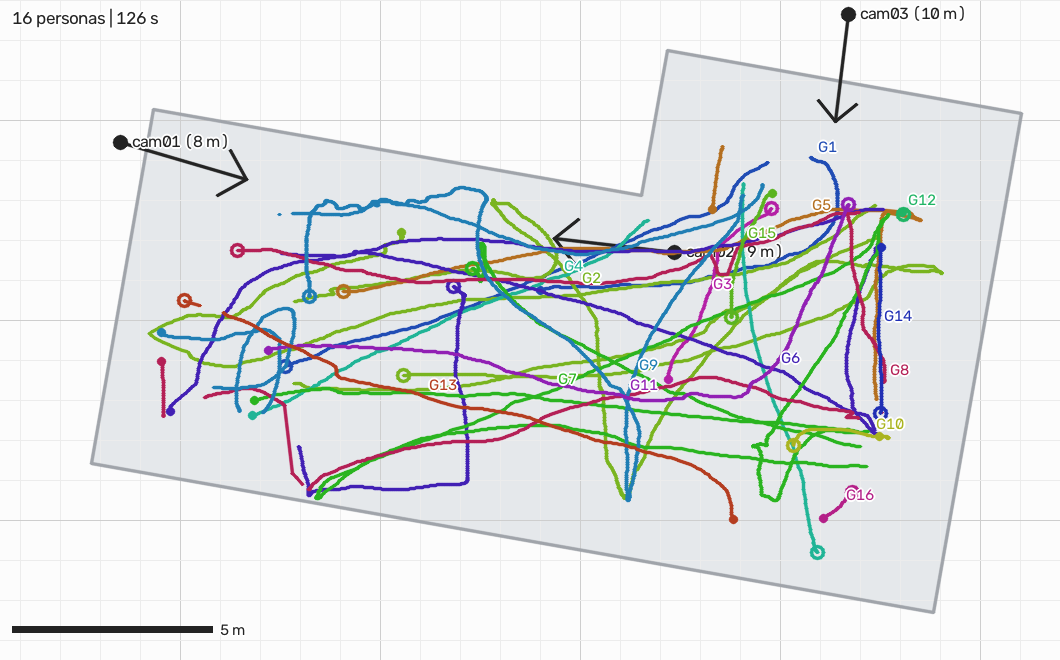

In [38]:
if MAPA_2D:
    display(Image(data=cv2.imencode(".png", DibujoMapa(resultado, mapa, TEMA_MAPA).trayectorias())[1].tobytes(), width=900))

## 10. Tabla `trajectory_points`

Cada fila indica dónde estuvo un `global_id` en un instante, después del Re-ID multicámara y de la reagrupación con el mapa. Por ahora **no hay zonas**, así que `zone_id` queda `NULL`. Tampoco se generan `zones` ni `spatial_events`.

Las **pasadas breves** que no se unieron a ninguna persona no se cuentan y no se exportan.

| Campo | Origen en este notebook |
|---|---|
| `point_id` | `BIGSERIAL`: lo asigna PostgreSQL (no va en el CSV). |
| `global_id` | UUID v5 de (sesión, GID final tras la reagrupación con el mapa): identidad anónima de sesión. |
| `timestamp` | `INICIO_GRABACION` + tiempo del video + desfase medido de la cámara (sincronizado). |
| `camera_id`, `local_id` | Trazabilidad hacia la cámara y el tracker local. |
| `tracklet_id` | UUID v5 de (sesión, `cam/L/T`). |
| `x`, `y`, `geom` | Pies de la persona en el mapa 2D del piso (metros, sección 9); `NULL` si los pies están cortados por el borde o sin mapa. |
| `speed_mps`, `direction_deg` | Movimiento del tracklet en el mapa (ventana de 1 s); dirección en [0, 360) respecto del eje x del mapa. |
| `confidence` | Confianza de YOLO26m para esa detección. |

Como las cámaras se solapan, un mismo `global_id` puede tener varias filas en el mismo instante (una por cámara). La consolidación de duplicados pertenece a la Parte III.

```sql
CREATE TABLE trajectory_points (
    point_id      BIGSERIAL PRIMARY KEY,
    global_id     UUID             NOT NULL,
    "timestamp"   TIMESTAMPTZ      NOT NULL,
    camera_id     VARCHAR(30)      NOT NULL,
    local_id      BIGINT           NOT NULL,
    tracklet_id   UUID             NOT NULL,
    x             DOUBLE PRECISION,
    y             DOUBLE PRECISION,
    geom          geometry(Point),
    zone_id       VARCHAR(50),          -- FK a zones(zone_id) cuando exista la tabla zones
    speed_mps     REAL,
    direction_deg REAL,
    confidence    REAL             NOT NULL
);

\copy trajectory_points (global_id, "timestamp", camera_id, local_id, tracklet_id, x, y, geom, zone_id, speed_mps, direction_deg, confidence) FROM 'Ouput/trajectory_points.csv' WITH (FORMAT csv, HEADER true)
```

In [39]:
trajectory_points = resultado.trajectory_points()

assert list(trajectory_points.columns) == COLUMNAS_TRAJECTORY_POINTS
assert trajectory_points.zone_id.isna().all()
assert trajectory_points[["global_id", "timestamp", "camera_id", "local_id", "tracklet_id", "confidence"]].notna().all().all()
if not trajectory_points.empty:
    assert trajectory_points.camera_id.str.len().max() <= 30
    assert all(uuid.UUID(v) for v in trajectory_points.global_id.unique())

con_plano = int(trajectory_points.x.notna().sum())
print(f"Filas: {len(trajectory_points)} · global_id: {trajectory_points.global_id.nunique()} · "
      f"tracklets: {trajectory_points.tracklet_id.nunique()} · con x/y: {con_plano}")
if not con_plano:
    print("Sin mapa: x, y, geom, speed_mps y direction_deg quedan NULL. Activa MAPA_2D (sección 9).")
display(trajectory_points.dtypes.to_frame("dtype").T)
display(trajectory_points.head(20))

Filas: 13689 · global_id: 16 · tracklets: 83 · con x/y: 12806


,point_id,global_id,timestamp,camera_id,local_id,tracklet_id,x,y,geom,zone_id,speed_mps,direction_deg,confidence
dtype,Int64,string,"datetime64[ns, Hora est. Pacífico, Sudamérica]",string,int64,string,float64,float64,string,string,float32,float32,float32


,point_id,global_id,timestamp,camera_id,local_id,tracklet_id,x,y,geom,zone_id,speed_mps,direction_deg,confidence
0,<NA>,5ed83078-9ffa-55b4-94a7-574478594ac7,2026-09-26 16:55:08.536082333-05:00,cam01,1,3991f3a1-e4fb-5e49-98a8-c3641e8bbc0a,-1.126817,0.744998,POINT(-1.1268 0.7450),<NA>,0.574968,9.229289,0.851262
1,<NA>,43c59dc6-3d45-5a45-8b59-6af7d0d62413,2026-09-26 16:55:08.536082333-05:00,cam01,2,62ce4818-02f1-59aa-a129-68d844005786,-4.486972,2.191361,POINT(-4.4870 2.1914),<NA>,0.018171,NaN,0.837043
2,<NA>,c9241524-97e8-5e2f-bf94-3318a29ba992,2026-09-26 16:55:08.536082333-05:00,cam01,3,fd2f8059-64c0-55a1-a65d-2c9f585506c2,2.184144,-1.526253,POINT(2.1841 -1.5263),<NA>,0.892816,80.947899,0.738605
3,<NA>,5ed83078-9ffa-55b4-94a7-574478594ac7,2026-09-26 16:55:08.602749-05:00,cam01,1,3991f3a1-e4fb-5e49-98a8-c3641e8bbc0a,-1.068275,0.749920,POINT(-1.0683 0.7499),<NA>,0.533028,12.639532,0.849463
4,<NA>,43c59dc6-3d45-5a45-8b59-6af7d0d62413,2026-09-26 16:55:08.602749-05:00,cam01,2,62ce4818-02f1-59aa-a129-68d844005786,-4.487862,2.190776,POINT(-4.4879 2.1908),<NA>,0.018988,NaN,0.816349
5,<NA>,c9241524-97e8-5e2f-bf94-3318a29ba992,2026-09-26 16:55:08.602749-05:00,cam01,3,fd2f8059-64c0-55a1-a65d-2c9f585506c2,2.189477,-1.506866,POINT(2.1895 -1.5069),<NA>,1.220130,82.881485,0.752542
6,<NA>,5ed83078-9ffa-55b4-94a7-574478594ac7,2026-09-26 16:55:08.669415667-05:00,cam01,1,3991f3a1-e4fb-5e49-98a8-c3641e8bbc0a,-0.988981,0.759847,POINT(-0.9890 0.7598),<NA>,0.500033,12.824214,0.842788
7,<NA>,43c59dc6-3d45-5a45-8b59-6af7d0d62413,2026-09-26 16:55:08.669415667-05:00,cam01,2,62ce4818-02f1-59aa-a129-68d844005786,-4.486972,2.190447,POINT(-4.4870 2.1904),<NA>,0.015324,NaN,0.834047
8,<NA>,c9241524-97e8-5e2f-bf94-3318a29ba992,2026-09-26 16:55:08.669415667-05:00,cam01,3,fd2f8059-64c0-55a1-a65d-2c9f585506c2,2.193945,-1.477605,POINT(2.1939 -1.4776),<NA>,1.238813,82.372650,0.805052
9,<NA>,5ed83078-9ffa-55b4-94a7-574478594ac7,2026-09-26 16:55:08.736082333-05:00,cam01,1,3991f3a1-e4fb-5e49-98a8-c3641e8bbc0a,-0.909687,0.769775,POINT(-0.9097 0.7698),<NA>,0.612924,10.009041,0.841293


## 11. Exportar

Solo se exporta lo que se va a usar:

- **`Ouput/`**: `cam01_procesado.mp4`, `cam02_procesado.mp4` y `cam03_procesado.mp4` (con los `global_id` finales), `mapa_2d.mp4` (mapa del piso con cada persona en cada instante, junto a las cámaras sincronizadas), `mapa_trayectorias.png`, `trajectory_points.csv` e `identidades_genero.csv` (una estimación consolidada por identidad). Cada ejecución reemplaza los archivos anteriores. No se guardan recortes, embeddings ni frames sueltos.
- **`Modelo/`**: `config_lap01.json` (la configuración usada) y `exportacion.json` (manifiesto SHA-256 de pesos, configuración y notebook, más las versiones de paquetes). `mapa_piso.json` guarda la calibración del mapa (sección 9).

Los tres videos por cámara se escriben a la vez (~40 s en total con el mapa). La exportación del modelo (segunda celda) no depende de haber procesado videos.

In [40]:
if EXPORTAR_VIDEOS:
    for cid, ruta in resultado.exportar_videos(OUTPUT, motor.config["detector"]["display_conf"]).items():
        print("Video procesado:", ruta.relative_to(BASE))
if EXPORTAR_MAPA and MAPA_2D:
    imagen, video = DibujoMapa(resultado, mapa, TEMA_MAPA).exportar(OUTPUT)
    print("Mapa 2D:", imagen.relative_to(BASE), "·", video.relative_to(BASE))
if EXPORTAR_TRAYECTORIAS:
    print("Tabla:", resultado.guardar_trajectory_points(OUTPUT / "trajectory_points.csv").relative_to(BASE))
if EXPORTAR_GENEROS and motor.genero.enabled:
    print("Géneros:", resultado.guardar_generos(OUTPUT / "identidades_genero.csv").relative_to(BASE))

Video procesado: Ouput\cam01_procesado.mp4
Video procesado: Ouput\cam02_procesado.mp4
Video procesado: Ouput\cam03_procesado.mp4
Mapa 2D: Ouput\mapa_trayectorias.png · Ouput\mapa_2d.mp4
Tabla: Ouput\trajectory_points.csv
Géneros: Ouput\identidades_genero.csv


In [41]:
def _sha256(ruta):
    with Path(ruta).open("rb") as stream:
        return hashlib.file_digest(stream, "sha256").hexdigest()


def exportar_modelo(config, config_camaras):
    """Guarda la configuración usada y un manifiesto verificable en Modelo/. No copia ni modifica los pesos."""
    cargar_camaras(config_camaras)  # validar el registro de cámaras antes de escribir
    pesos = set(config["weights"].values())
    encoder = config.get("multicamera_encoder", {})
    if encoder.get("type") == "onnx":
        pesos.add(encoder["weights"])
    genero = config.get("gender", {})
    archivos_genero = []
    if genero.get("enabled", False):
        nombre = genero.get("weights", "")
        if not isinstance(nombre, str) or Path(nombre).name != nombre:
            raise ValueError("gender.weights debe ser una carpeta local dentro de Modelo/.")
        carpeta_genero = MODELO / nombre
        if not (carpeta_genero / "config.json").is_file() or not (carpeta_genero / "model.safetensors").is_file():
            raise FileNotFoundError(f"Falta el modelo CLIP local en {carpeta_genero}")
        archivos_genero = sorted(ruta for ruta in carpeta_genero.rglob("*") if ruta.is_file())
    faltantes = [nombre for nombre in sorted(pesos) if Path(nombre).name != nombre or not (MODELO / nombre).is_file()]
    if faltantes:
        raise FileNotFoundError(f"Faltan pesos locales en Modelo/: {faltantes}")

    ruta_config = MODELO / "config_lap01.json"
    ruta_config.write_text(json.dumps(config, ensure_ascii=False, indent=2) + "\n")
    archivos = {f"Modelo/{nombre}": _sha256(MODELO / nombre)
                for nombre in [*sorted(pesos), "config_lap01.json", "camaras.json", "mapa_piso.json"]
                if (MODELO / nombre).is_file()}
    archivos.update({f"Modelo/{ruta.relative_to(MODELO)}": _sha256(ruta) for ruta in archivos_genero})
    versiones = {}
    for paquete in ("torch", "torchvision", "transformers", "ultralytics", "numpy", "scipy", "opencv-python", "onnxruntime", "pandas"):
        try:
            versiones[paquete] = importlib.metadata.version(paquete)
        except importlib.metadata.PackageNotFoundError:
            versiones[paquete] = None
    manifiesto = {"version": config.get("version", "2.0"),
                  "fecha": datetime.now().astimezone().isoformat(timespec="seconds"),
                  "notebook": NOTEBOOK.name, "notebook_sha256": _sha256(NOTEBOOK) if NOTEBOOK.is_file() else None,
                  "modo_multicamara": config_camaras.get("mode"), "files_sha256": archivos, "packages": versiones}
    ruta_manifiesto = MODELO / "exportacion.json"
    ruta_manifiesto.write_text(json.dumps(manifiesto, ensure_ascii=False, indent=2) + "\n")
    return ruta_config, ruta_manifiesto


for ruta in exportar_modelo(CONFIG, CONFIG_CAMARAS):
    print("Modelo exportado:", ruta.relative_to(BASE))

Modelo exportado: Modelo\config_lap01.json
Modelo exportado: Modelo\exportacion.json


## 12. Calibración manual con medidas reales (cámaras fijas)

Esta sección es para **cámaras fijas** con puntos medidos en el lugar. Estos videos tienen cámaras que se mueven, así que para ellos se usa el mapa automático de la sección 9. Si más adelante tienes medidas reales, puedes usarlas aquí.

En cada cámara marca **al menos cuatro puntos del suelo** sobre el video de 1280×720 y sus coordenadas en un plano común en metros. Reserva **al menos dos puntos distintos** para validar. No uses esquinas de paredes ni objetos a otra altura. Si cambia el recorte o la resolución, vuelve a calibrar.

Completa `CALIBRACIONES` para las tres cámaras. La función rechaza puntos degenerados, controles repetidos y errores mayores que el límite. Revisa también en `camaras.json` los polígonos de cobertura, los solapes reales y las transiciones con sus tiempos. Al guardar, el modo pasa a `calibrado`. Luego vuelve a ejecutar desde la sección 2.

In [42]:
CALIBRACIONES = {}  # No se inventan correspondencias del recinto.
# Formato por cámara (píxeles del video ↔ metros del plano):
# CALIBRACIONES["cam01"] = {
#     "imagen": [[u, v], ...],          "plano": [[X, Y], ...],           # ≥ 4 puntos de ajuste
#     "control_imagen": [[u, v], ...],  "control_plano": [[X, Y], ...],   # ≥ 2 puntos de validación
# }
if CALIBRACIONES:
    if set(CALIBRACIONES) != set(VIDEOS):
        raise ValueError("Completa todas las cámaras antes de activar el modo calibrado.")
    calibrada = deepcopy(CONFIG_CAMARAS)
    for cid, puntos in CALIBRACIONES.items():
        limite = float(calibrada["cameras"][cid].get("max_error_m", 0.75))
        calibrada["cameras"][cid].update(calibrar_homografia(**puntos, max_error_m=limite))
    calibrada["mode"] = "calibrado"
    cargar_camaras(calibrada, VIDEOS)  # validar antes de guardar
    (MODELO / "camaras.json").write_text(json.dumps(calibrada, indent=2, ensure_ascii=False) + "\n")
    CONFIG_CAMARAS = calibrada
    display(pd.DataFrame({cid: cam["validation"] for cid, cam in calibrada["cameras"].items()}).T)
    print("Calibración validada y guardada en Modelo/camaras.json. Vuelve a ejecutar desde la sección 2.")